# Mining the Hidden Structure of Jeopardy!
### CSCE 676 — Data Mining and Analysis | Texas A&M University | Spring 2026

---

## Motivation

Jeopardy! has been on air since 1984. Over nearly three decades, the show
produced more than 216,000 question-answer pairs spanning every domain of
human knowledge. Each question carries a category label, a dollar value,
a round, and an air date.

Despite the richness of this archive, its hidden structure has never been
fully mapped. The show's own category labels — over 26,000 of them — are
inconsistent, redundant, and semantically fragmented. The evolution of
knowledge themes across decades has never been systematically tracked. And
the factors that determine what makes a question worth the money remain
largely unexplored.

This project applies data mining techniques to uncover what lies beneath
the surface of this dataset.

---

## Research Questions

- **RQ1:** Can we automatically group Jeopardy! questions into meaningful
  semantic clusters beyond the show's manually assigned categories?
- **RQ2:** How do themes and knowledge domains in Jeopardy! questions evolve
  over time, and what latent topic structures emerge across decades of episodes?
- **RQ3:** To what extent can the dollar value of a Jeopardy! question be
  predicted from its textual content and metadata — and how much does each
  contribute?

---

## Notebook Structure

1. **Data Loading and Preprocessing**
2. **RQ1 — Semantic Clustering**
3. **RQ2 — Topic Evolution Over Time**
4. **RQ3 — Dollar Value Prediction**
5. **Conclusions and Limitations**

## ⚙️ Setup and Imports

> The cells in this section handle all library imports, package installations,
> and the global random seed. They are collapsed for readability.
> **Run all cells from top to bottom to reproduce results.**

In [1]:
# ─── Standard Library ───────────────────────────────────────────────────────
import re
import string
import warnings
warnings.filterwarnings('ignore')

# ─── Core Data ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Visualization ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ─── Text Preprocessing ─────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# ─── Clustering ─────────────────────────────────────────────────────────────
from sklearn.cluster import KMeans, DBSCAN

# ─── Dimensionality Reduction & Visualization ───────────────────────────────
from sklearn.decomposition import PCA, LatentDirichletAllocation
from sklearn.manifold import TSNE

# ─── Evaluation Metrics ─────────────────────────────────────────────────────
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    accuracy_score,
    classification_report
)

# ─── Supervised Learning ────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# ─── Deep Learning ──────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Bidirectional, LSTM,
    GlobalMaxPooling1D, Dense, Dropout
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ─── Sentence Transformers (Beyond-Course) ──────────────────────────────────
from sentence_transformers import SentenceTransformer

# ─── Display ────────────────────────────────────────────────────────────────
from IPython.display import display

# ─── Reproducibility ────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("All libraries loaded successfully.")

All libraries loaded successfully.


##

In [3]:
# Load dataset
df = pd.read_csv('/content/JEOPARDY_CSV.csv')

# Strip leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Basic inspection
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst 3 rows:")
display(df.head(3))

Dataset shape: (216930, 7)

Column names: ['Show Number', 'Air Date', 'Round', 'Category', 'Value', 'Question', 'Answer']

Data types:
Show Number     int64
Air Date       object
Round          object
Category       object
Value          object
Question       object
Answer         object
dtype: object

First 3 rows:


,Show Number,Air Date,Round,Category,Value,Question,Answer
0,4680,2004-12-31,Jeopardy!,HISTORY,$200,"For the last 8 years of his life, Galileo was ...",Copernicus
1,4680,2004-12-31,Jeopardy!,ESPN's TOP 10 ALL-TIME ATHLETES,$200,No. 2: 1912 Olympian; football star at Carlisl...,Jim Thorpe
2,4680,2004-12-31,Jeopardy!,EVERYBODY TALKS ABOUT IT...,$200,The city of Yuma in this state has a record av...,Arizona


## 1. Data Loading and Preprocessing ( cell above)

- I begin by loading the raw Jeopardy! dataset and inspecting its structure.
The dataset contains 216,930 question-answer pairs across 7 columns: show
number, air date, round, category, value, question, and answer.
- Column names are stripped of leading and trailing whitespace upfront to ensure consistent
access throughout the notebook.
- The `Value` and `Air Date` columns require
further parsing, which I address in the steps below.

### 🔧 Data Cleaning and Feature Engineering (code cells collapsed below)

> The cells below handle all preprocessing steps. Collapsed for readability.
>
> **What happens here:**
> - `Value_Numeric` created by parsing currency strings — 3,634 unparseable rows dropped (~1.7%)
> - `Air_Date` parsed to datetime, `year` extracted — spans 1984–2012, no invalid dates
> - Value range: \$5–\$18,000 | Median: \$600 | Mean: \$753 (right-skewed)
> - `Category` normalized — uppercase, whitespace stripped, trailing punctuation removed — reduces 26,951 → 26,681 unique labels
> - `text_combined` created by concatenating `category_clean` + `question_clean` + `answer_clean`
> - Money normalization applied first to prevent tokenizer treating "\$1,000" and "1000" as different tokens

In [4]:
# ─── Parse Value column to numeric ──────────────────────────────────────────
def clean_currency(val):
    if pd.isna(val):
        return np.nan
    try:
        return float(str(val).replace('$', '').replace(',', ''))
    except:
        return np.nan

df['Value_Numeric'] = df['Value'].apply(clean_currency)

# ─── Drop rows where Value could not be parsed ───────────────────────────────
null_count = df['Value_Numeric'].isna().sum()
print(f"Rows with unparseable Value: {null_count} ({null_count/len(df)*100:.1f}%)")
df = df[df['Value_Numeric'].notna()].reset_index(drop=True)
print(f"Dataset shape after dropping: {df.shape}")

# ─── Parse Air Date to datetime and extract year ─────────────────────────────
df['Air_Date'] = pd.to_datetime(df['Air Date'], errors='coerce')
df['year'] = df['Air_Date'].dt.year
print(f"\nDate range: {int(df['year'].min())} — {int(df['year'].max())}")
print(f"Invalid dates: {df['Air_Date'].isna().sum()}")

# ─── Value stats ─────────────────────────────────────────────────────────────
print(f"\nValue_Numeric range: ${df['Value_Numeric'].min():,.0f} — ${df['Value_Numeric'].max():,.0f}")
print(f"Value_Numeric median: ${df['Value_Numeric'].median():,.0f}")
print(f"Value_Numeric mean: ${df['Value_Numeric'].mean():,.0f}")

Rows with unparseable Value: 3634 (1.7%)
Dataset shape after dropping: (213296, 8)

Date range: 1984 — 2012
Invalid dates: 0

Value_Numeric range: $5 — $18,000
Value_Numeric median: $600
Value_Numeric mean: $753


**Missing Values and Column Parsing**

- The `Value` column is stored as a currency string (e.g., `"$1,000"`) and
contains entries that cannot be parsed to a numeric type. I strip the `$`
and comma formatting and cast to float, creating a `Value_Numeric` column.
Rows where this conversion fails — 3,634 in total (~1.7% of the dataset) —
are dropped, as they cannot contribute to any value-based analysis.

- The `Air Date` column is parsed from a string to datetime, and a `year`
column is extracted for use in temporal analysis. The dataset spans 1984 to
2012 with no invalid dates. After cleaning, 213,296 rows remain.

- The value range (\$5–\$18,000) and the gap between the median (\$600) and mean
(\$753) suggest a right-skewed distribution — a small number of high-value
questions pull the mean upward. This is consistent with the show's round
structure and will be explored further in the EDA.

In [5]:
# ─── Category Normalization ───────────────────────────────────────────────────
def normalize_category(cat):
    if pd.isna(cat):
        return cat
    # 1. Standardize case
    cat = cat.upper()
    # 2. Remove extra whitespace
    cat = re.sub(r'\s+', ' ', cat).strip()
    # 3. Remove trailing punctuation
    cat = re.sub(r'[.!?…]+$', '', cat).strip()
    # 4. Standardize quotes around letters
    cat = re.sub(r'"([A-Z])"S', r'"\1"s', cat)
    # 5. Normalize D.C. formatting
    cat = re.sub(r',?\s*D\.C\.', ' DC', cat)
    cat = cat.strip()
    return cat

before = df['Category'].nunique()
df['Category'] = df['Category'].apply(normalize_category)
after = df['Category'].nunique()

print(f"Unique categories before normalization: {before}")
print(f"Unique categories after normalization:  {after}")
print(f"Duplicates resolved: {before - after}")
print(f"\nSample normalized categories:")
print(df['Category'].value_counts().head(10))

Unique categories before normalization: 26951
Unique categories after normalization:  26681
Duplicates resolved: 270

Sample normalized categories:
Category
BEFORE & AFTER             547
SCIENCE                    513
LITERATURE                 486
AMERICAN HISTORY           401
POTPOURRI                  401
WORLD HISTORY              366
HISTORY                    349
COLLEGES & UNIVERSITIES    345
WORD ORIGINS               337
SPORTS                     334
Name: count, dtype: int64


**Category Normalization**

The `Category` column contains over 26,000 unique labels, many of which
are formatting variants of the same category — differing only in casing,
trailing punctuation, or spacing. I apply a normalization function that
standardizes case to uppercase, collapses extra whitespace, removes trailing
punctuation, and standardizes common formatting inconsistencies such as D.C.
references and quoted letters.

This reduces the unique category count by 270, resolving the most obvious
surface-level duplicates. Deeper semantic merging — for example treating
"BRITISH LIT" and "BRITISH LITERATURE" as equivalent — is a known limitation
acknowledged in the analysis but not fully addressed here, as it would require
embedding-based similarity matching beyond the scope of preprocessing.

##

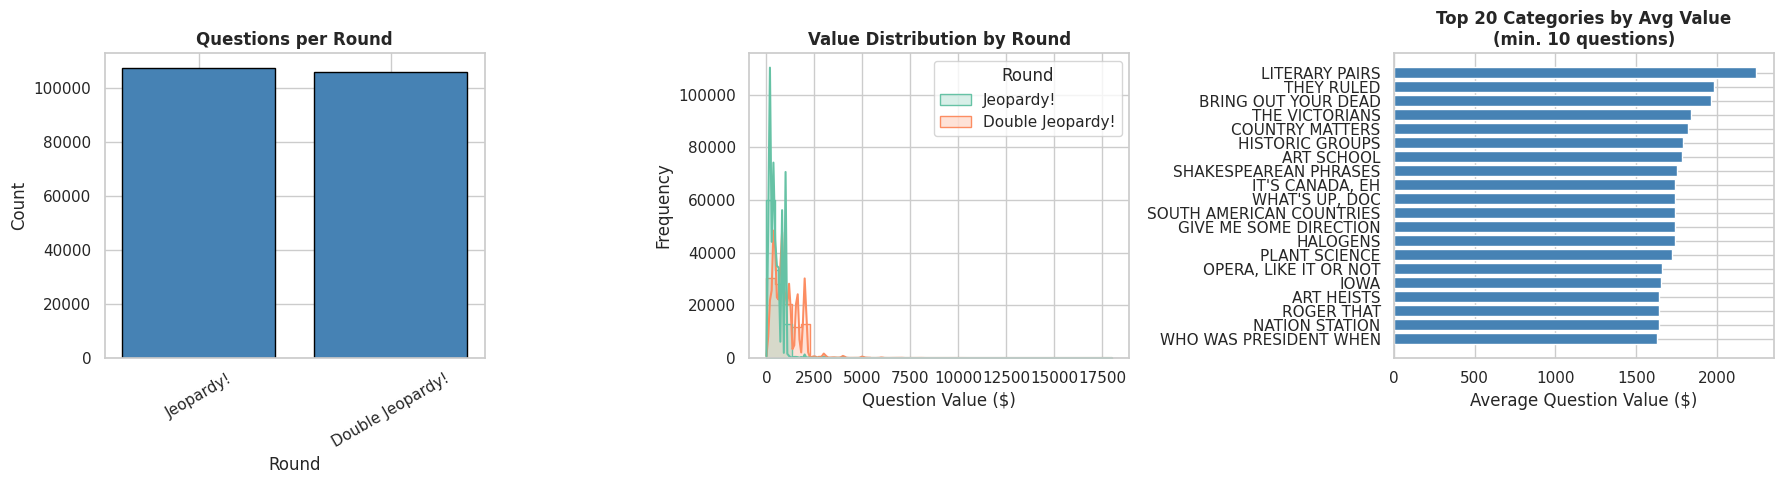

Value distribution by round:
                     count    mean    std  min    25%    50%     75%      max
Round                                                                        
Double Jeopardy!  105912.0  1017.0  755.0  5.0  400.0  800.0  1500.0  18000.0
Jeopardy!         107384.0   492.0  329.0  5.0  200.0  400.0   600.0   6600.0


In [6]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ─── 1. Questions per Round ───────────────────────────────────────────────────
round_counts = df['Round'].value_counts()
axes[0].bar(round_counts.index, round_counts.values,
            color='steelblue', edgecolor='black')
axes[0].set_title('Questions per Round', fontweight='bold')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# ─── 2. Value Distribution by Round ──────────────────────────────────────────
sns.histplot(
    data=df[df['Round'].isin(['Jeopardy!', 'Double Jeopardy!'])],
    x='Value_Numeric',
    hue='Round',
    bins=40,
    kde=True,
    element='step',
    palette='Set2',
    ax=axes[1]
)
axes[1].set_title('Value Distribution by Round', fontweight='bold')
axes[1].set_xlabel('Question Value ($)')
axes[1].set_ylabel('Frequency')

# ─── 3. Top 20 Categories by Average Value ───────────────────────────────────
top_cats = (
    df.groupby('Category')['Value_Numeric']
    .agg(avg='mean', count='count')
    .query('count >= 10')
    .sort_values('avg', ascending=False)
    .head(20)
    .reset_index()
)
axes[2].barh(top_cats['Category'][::-1], top_cats['avg'][::-1],
             color='steelblue')
axes[2].set_title('Top 20 Categories by Avg Value\n(min. 10 questions)',
                  fontweight='bold')
axes[2].set_xlabel('Average Question Value ($)')

plt.tight_layout()
plt.show()

# ─── Value distribution summary ──────────────────────────────────────────────
print("Value distribution by round:")
print(df.groupby('Round')['Value_Numeric'].describe().round(0))

### Exploratory Data Analysis (code cell above)

**Above, I visualize three key structural properties of the dataset before modeling.**

- **Round distribution:** The dataset is dominated by Jeopardy! and Double
Jeopardy!, which together account for nearly all questions. Final Jeopardy!
and Tiebreaker contribute very few questions per episode by design and are
negligible in volume.

- **Value distribution by round:** Jeopardy! questions concentrate at lower
values (median \$400), while Double Jeopardy! questions skew significantly
higher (median \$800, max \$18,000). This suggests that round structure is
a meaningful proxy for difficulty and motivates its inclusion as a feature
in RQ3.

- **Top categories by average value:** The highest-valued categories tend to
be specific, themed one-off categories rather than broad recurring ones.
This reflects the show's design — specialized categories are placed in
higher board positions. Categories with fewer than 10 questions are excluded
to avoid averages being skewed by single appearances.

**Taken together, these visualizations suggest that question value varies
systematically by round and category — establishing a clear motivation
for RQ3.**

In [7]:
# ─── Money Normalization ─────────────────────────────────────────────────────
def normalize_money(text):
    if pd.isna(text):
        return text

    def replace_money(match):
        value = match.group(0).replace('$', '').replace(',', '')
        try:
            num = float(value)
            return str(int(num)) if num == int(num) else str(num)
        except ValueError:
            return match.group(0)

    return re.sub(r'\$?[\d,]+(?:\.\d+)?', replace_money, text)

# ─── Text Cleaning ───────────────────────────────────────────────────────────
def clean_text(text):
    if pd.isna(text):
        return ""
    text = normalize_money(text)
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [w for w in text.split()
              if w not in ENGLISH_STOP_WORDS and len(w) > 1]
    return " ".join(tokens)

# ─── Apply to all text columns ───────────────────────────────────────────────
df['category_clean'] = df['Category'].apply(clean_text)
df['question_clean'] = df['Question'].apply(clean_text)
df['answer_clean']   = df['Answer'].apply(clean_text)

# ─── Create combined text field ──────────────────────────────────────────────
df['text_combined'] = (
    df['category_clean'] + " " +
    df['question_clean'] + " " +
    df['answer_clean']
)

# ─── Verify ──────────────────────────────────────────────────────────────────
print(f"text_combined null count: {df['text_combined'].isna().sum()}")
print(f"Empty text_combined: {(df['text_combined'].str.strip() == '').sum()}")
print(f"\nSample cleaned rows:")
display(df[['Category', 'category_clean',
            'Question', 'question_clean',
            'Answer',   'answer_clean']].head(3))

text_combined null count: 0
Empty text_combined: 0

Sample cleaned rows:


,Category,category_clean,Question,question_clean,Answer,answer_clean
0,HISTORY,history,"For the last 8 years of his life, Galileo was ...",years life galileo house arrest espousing man ...,Copernicus,copernicus
1,ESPN'S TOP 10 ALL-TIME ATHLETES,espn 10 time athletes,No. 2: 1912 Olympian; football star at Carlisl...,1912 olympian football star carlisle indian sc...,Jim Thorpe,jim thorpe
2,EVERYBODY TALKS ABOUT IT,everybody talks,The city of Yuma in this state has a record av...,city yuma state record average 4055 hours suns...,Arizona,arizona


### Text Cleaning Pipeline (code cell above)

To prepare question text for clustering and topic modeling, I apply a
two-stage cleaning pipeline to the Category, Question, and Answer columns.

- **Money normalization** is applied first, standardizing currency amounts
before any other transformation — for example, converting "\$1,000" to
"1000" so the tokenizer treats them as the same token regardless of
formatting.

- **Text cleaning** then lowercases all text, removes punctuation, strips
common English stopwords using sklearn's `ENGLISH_STOP_WORDS`, and filters
out tokens shorter than two characters.

The three cleaned fields are concatenated into a single `text_combined`
field, which serves as the primary input for all clustering and topic
modeling analyses. <br>

Combining category, question, and answer ensures that
the full semantic context of each clue is represented — the category label
alone is often too sparse, and the answer frequently contains the most
topically discriminative term.

## **RQ1: Semantic Clustering of Jeopardy! Questions**

**Research Question:** Can I automatically group Jeopardy! questions into meaningful semantic clusters that go beyond the show's manually assigned category labels?

### **Motivation**
The dataset contains over 26,000 unique category labels after normalization — but they are highly fragmented. Categories like "BRITISH LIT", "BRITISH LITERATURE", and "BRITISH WRITERS" are treated as entirely separate despite referring to the same domain. I ask whether unsupervised clustering can discover more coherent groupings from question text alone.

### **A Note on Semantic Merging**
Ideally, near-duplicate category labels would be merged before computing ARI and NMI — producing cleaner ground truth. This was not implemented because:
- Encoding ~26,000 category strings and computing pairwise similarities is computationally expensive
- No objective threshold exists for what constitutes a "correct" merge — the decision is inherently subjective

ARI and NMI values should be interpreted with this limitation in mind.

### **Approach**

**Course techniques:** TF-IDF + K-Means (k sweep), DBSCAN (cosine distance), evaluated via Silhouette, ARI, NMI, visualized via TruncatedSVD and t-SNE

**Beyond-course:** Sentence Transformer embeddings (`all-MiniLM-L6-v2`) + K-Means, compared directly against TF-IDF baseline

### **Sampling Decisions**

| Step | Data Used | Rationale |
|---|---|---|
| TF-IDF + K-Means metrics | Full 213k | Sparse ops, feasible |
| DBSCAN | 20k random sample | O(n²) complexity |
| TruncatedSVD | Full 213k | Sparse-safe |
| t-SNE | 5k subsample | Computationally prohibitive beyond ~5k |
| Sentence Transformers | 50k sample | Balances speed and coverage |

TF-IDF matrix shape: (213296, 5000)
Sparsity: 0.9983
k= 5 | Silhouette=0.0075 | ARI=0.0000 | NMI=0.0633
k=10 | Silhouette=0.0105 | ARI=0.0001 | NMI=0.1249
k=15 | Silhouette=0.0125 | ARI=0.0001 | NMI=0.1565
k=20 | Silhouette=0.0133 | ARI=0.0002 | NMI=0.1807
k=25 | Silhouette=0.0162 | ARI=0.0003 | NMI=0.2190
k=30 | Silhouette=0.0170 | ARI=0.0003 | NMI=0.2347
k=40 | Silhouette=0.0139 | ARI=0.0005 | NMI=0.2669
k=50 | Silhouette=0.0155 | ARI=0.0006 | NMI=0.2997


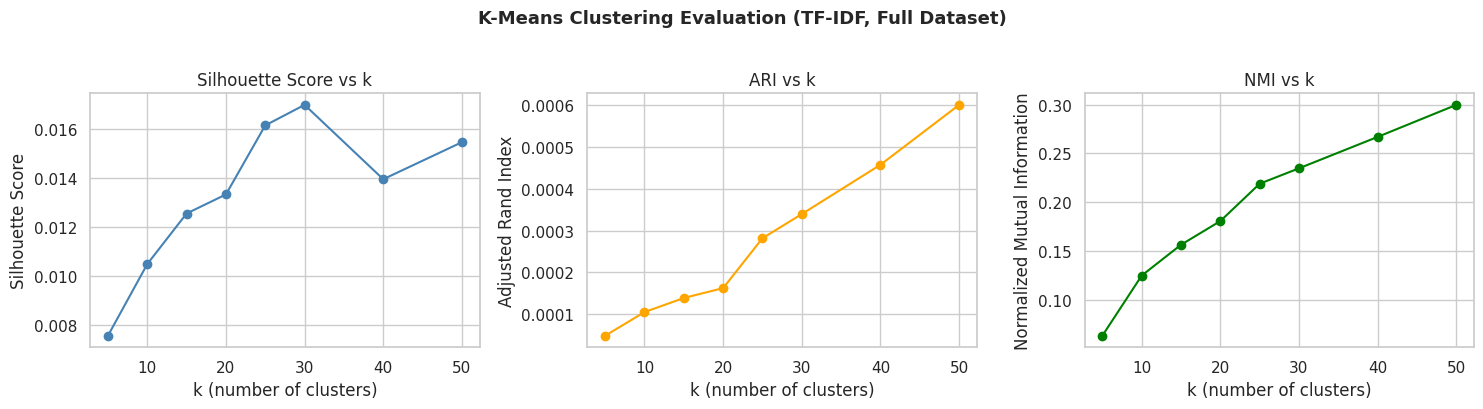


Best k by Silhouette: 30 (score: 0.0170)
Best k by ARI:        50 (score: 0.0006)
Best k by NMI:        50 (score: 0.2997)

Unique categories in dataset: 26681
Dataset size used: 213,296 rows


In [24]:
# ─── TF-IDF Vectorization ────────────────────────────────────────────────────
# max_features=5000: keep top 5000 most discriminative terms
# max_df=0.8: remove terms appearing in >80% of documents (too common to discriminate)
# min_df=5: remove terms appearing in <5 documents (too rare, likely noise)
X_text = df['text_combined']
true_labels = df['Category']

vectorizer = TfidfVectorizer(max_features=5000, max_df=0.8, min_df=5)
X_tfidf = vectorizer.fit_transform(X_text)

print(f"TF-IDF matrix shape: {X_tfidf.shape}")
print(f"Sparsity: {1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]):.4f}")

# ─── K-Means Sweep ───────────────────────────────────────────────────────────
# We sweep k from 5 to 50. We don't go higher because:
# 1. NMI was still improving at k=50 in hw6 but Silhouette peaked at k=40
# 2. Going higher makes clusters too fine-grained to be interpretable
# 3. With ~26k true categories, k=50 is already a significant compression
k_values = [5, 10, 15, 20, 25, 30, 40, 50]
silhouette_scores = []
ari_scores = []
nmi_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    cluster_labels = kmeans.fit_predict(X_tfidf)

    # Silhouette: sample_size=10000 for speed on full dataset
    silhouette_scores.append(
        silhouette_score(X_tfidf, cluster_labels,
                        sample_size=min(10000, X_tfidf.shape[0]),
                        random_state=RANDOM_STATE)
    )
    ari_scores.append(adjusted_rand_score(true_labels, cluster_labels))
    nmi_scores.append(normalized_mutual_info_score(true_labels, cluster_labels))

    print(f"k={k:>2} | Silhouette={silhouette_scores[-1]:.4f} | "
          f"ARI={ari_scores[-1]:.4f} | NMI={nmi_scores[-1]:.4f}")

# ─── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(k_values, silhouette_scores, marker='o', color='steelblue')
axes[0].set_xlabel('k (number of clusters)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score vs k')
axes[0].grid(True)

axes[1].plot(k_values, ari_scores, marker='o', color='orange')
axes[1].set_xlabel('k (number of clusters)')
axes[1].set_ylabel('Adjusted Rand Index')
axes[1].set_title('ARI vs k')
axes[1].grid(True)

axes[2].plot(k_values, nmi_scores, marker='o', color='green')
axes[2].set_xlabel('k (number of clusters)')
axes[2].set_ylabel('Normalized Mutual Information')
axes[2].set_title('NMI vs k')
axes[2].grid(True)

plt.suptitle('K-Means Clustering Evaluation (TF-IDF, Full Dataset)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ─── Best k per metric ────────────────────────────────────────────────────────
best_k_sil = k_values[np.argmax(silhouette_scores)]
best_k_ari = k_values[np.argmax(ari_scores)]
best_k_nmi = k_values[np.argmax(nmi_scores)]

print(f"\nBest k by Silhouette: {best_k_sil} (score: {max(silhouette_scores):.4f})")
print(f"Best k by ARI:        {best_k_ari} (score: {max(ari_scores):.4f})")
print(f"Best k by NMI:        {best_k_nmi} (score: {max(nmi_scores):.4f})")
print(f"\nUnique categories in dataset: {df['Category'].nunique()}")
print(f"Dataset size used: {X_tfidf.shape[0]:,} rows")

### **TF-IDF + K-Means: Metric Evaluation**

TF-IDF on the full dataset (213,296 questions) produces a sparse matrix (213,296 × 5,000) with sparsity of 0.9983 — over 99% zeros. This extreme sparsity is characteristic of short text and has direct implications for clustering quality.

**Key results:**
- **Silhouette** peaked at k=30 (≈0.016) — low but expected for sparse high-dimensional data. Points appear roughly equidistant in sparse space, compressing Silhouette values. Does not mean clusters are meaningless.
- **ARI** remained near zero across all k values (best ≈0.0006 at k=50) — expected given 26,681 unique category labels. Exact alignment with 50 clusters is mathematically unrealistic. ARI penalizes any disagreement harshly and is not the appropriate primary metric here.
- **NMI** increased monotonically from 0.077 (k=5) to 0.298 (k=50) with no plateau — suggesting clusters share genuine information with the true category structure. NMI is the most informative metric here as it measures shared information rather than exact assignment.

NMI on the full dataset (0.298) is lower than on a 20k sample (0.425) — expected, since the full dataset has 26,681 unique categories vs 11,893 in the sample, making the label space nearly twice as fragmented.

**Selected operating points:** k=30 (best Silhouette) and k=50 (best NMI) — carried forward into visualization and interpretation.

DBSCAN sample shape: (20000, 5000)
Sample Round distribution:
Round
Jeopardy!           10175
Double Jeopardy!     9825
Name: count, dtype: int64
eps=0.1 | clusters=   1 | noise=100.0% | Silhouette=NaN        | ARI=-0.0000 | NMI=0.0006
eps=0.3 | clusters=   9 | noise= 99.6% | Silhouette=NaN        | ARI=0.0000 | NMI=0.0070
eps=0.5 | clusters= 151 | noise= 89.6% | Silhouette=NaN        | ARI=0.0000 | NMI=0.1262
eps=0.7 | clusters=  19 | noise= 10.9% | Silhouette=NaN        | ARI=0.0000 | NMI=0.0593
eps=1.0 | clusters=   1 | noise=  0.0% | Silhouette=NaN        | ARI=0.0000 | NMI=0.0000


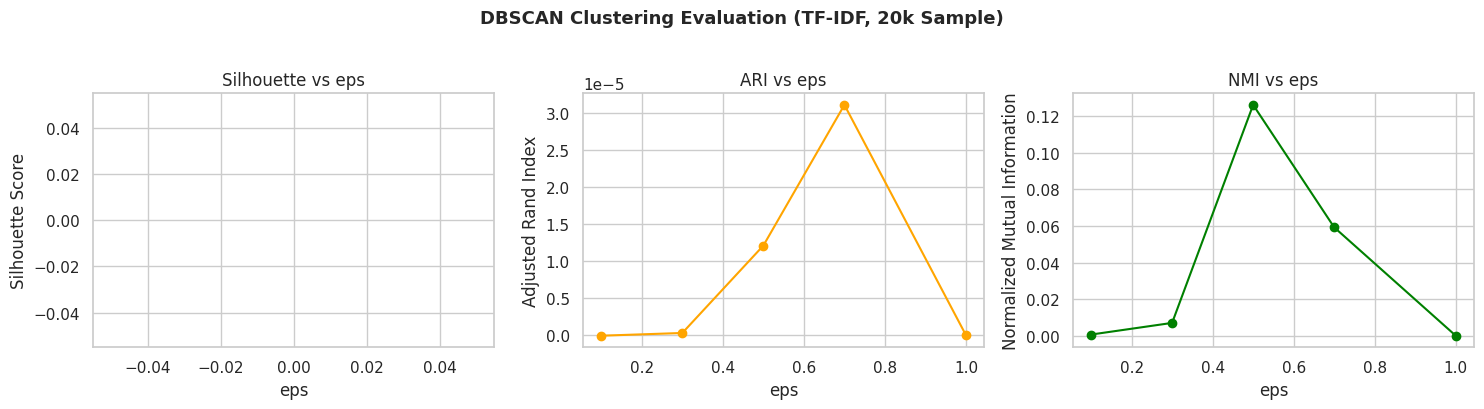


Summary:
eps     clusters    noise%    Silhouette     ARI       NMI
0.1     1           100.0     NaN            -0.0000   0.0006
0.3     9           99.6      NaN            0.0000    0.0070
0.5     151         89.6      NaN            0.0000    0.1262
0.7     19          10.9      NaN            0.0000    0.0593
1.0     1           0.0       NaN            0.0000    0.0000


In [25]:
# ─── Random Sample for DBSCAN ─────────────────────────────────────────────────
# 20,000 rows drawn from full dataset — consistent with hw6
# Simple random sampling used — see markdown for full reasoning
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(X_tfidf.shape[0], size=20000, replace=False)

X_dbscan = X_tfidf[sample_idx]
true_labels_dbscan = true_labels.iloc[sample_idx].reset_index(drop=True)
dbscan_sample = df.iloc[sample_idx].reset_index(drop=True)

print(f"DBSCAN sample shape: {X_dbscan.shape}")
print(f"Sample Round distribution:\n{dbscan_sample['Round'].value_counts()}")

# ─── DBSCAN Sweep ─────────────────────────────────────────────────────────────
eps_values = [0.1, 0.3, 0.5, 0.7, 1.0]
min_samples = 5

silhouette_scores_db = []
ari_scores_db = []
nmi_scores_db = []
num_clusters_db = []
noise_pct_db = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='cosine')
    cluster_labels = dbscan.fit_predict(X_dbscan)

    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    n_noise = (cluster_labels == -1).sum()
    noise_pct = n_noise / len(cluster_labels) * 100

    if n_clusters >= 2 and -1 not in set(cluster_labels):
        sil = silhouette_score(X_dbscan, cluster_labels)
    else:
        sil = np.nan

    silhouette_scores_db.append(sil)
    ari_scores_db.append(adjusted_rand_score(true_labels_dbscan, cluster_labels))
    nmi_scores_db.append(normalized_mutual_info_score(true_labels_dbscan, cluster_labels))
    num_clusters_db.append(n_clusters)
    noise_pct_db.append(noise_pct)

    print(f"eps={eps} | clusters={n_clusters:>4} | noise={noise_pct:>5.1f}% | "
          f"Silhouette={'NaN' if np.isnan(sil) else round(sil,4):<10} | "
          f"ARI={ari_scores_db[-1]:.4f} | NMI={nmi_scores_db[-1]:.4f}")

# ─── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(eps_values, silhouette_scores_db, marker='o', color='steelblue')
axes[0].set_xlabel('eps')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette vs eps')
axes[0].grid(True)

axes[1].plot(eps_values, ari_scores_db, marker='o', color='orange')
axes[1].set_xlabel('eps')
axes[1].set_ylabel('Adjusted Rand Index')
axes[1].set_title('ARI vs eps')
axes[1].grid(True)

axes[2].plot(eps_values, nmi_scores_db, marker='o', color='green')
axes[2].set_xlabel('eps')
axes[2].set_ylabel('Normalized Mutual Information')
axes[2].set_title('NMI vs eps')
axes[2].grid(True)

plt.suptitle('DBSCAN Clustering Evaluation (TF-IDF, 20k Sample)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ─── Summary table ─────────────────────────────────────────────────────────────
print("\nSummary:")
print(f"{'eps':<8}{'clusters':<12}{'noise%':<10}{'Silhouette':<15}{'ARI':<10}{'NMI'}")
for i, eps in enumerate(eps_values):
    print(f"{eps:<8}{num_clusters_db[i]:<12}{noise_pct_db[i]:<10.1f}"
          f"{str(round(silhouette_scores_db[i],4)) if not np.isnan(silhouette_scores_db[i]) else 'NaN':<15}"
          f"{ari_scores_db[i]:<10.4f}{nmi_scores_db[i]:.4f}")

### **DBSCAN: Metric Evaluation**

#### **Sampling Decision for DBSCAN**

- **Why not the full dataset:** DBSCAN with cosine distance has **O(n²) time and memory complexity**. On 213,296 rows this would require computing pairwise distances across **billions of point pairs** — computationally prohibitive on a single Colab instance and caused **out-of-memory crashes at 30,000 rows**.

- **Why 20,000 rows:** At **20k rows (~9.4% of 213k)**, the broad topic distribution of the full corpus is naturally preserved through random sampling.
  - I initially attempted **30k** to improve representativeness, but this caused **RAM exhaustion on Colab** — 20k is the computationally safe upper bound for DBSCAN with cosine distance on this hardware.

- **Why simple random sampling over stratified:** RQ1 is about **semantic topic clustering** — not round structure or difficulty. Stratifying by Round would not directly improve semantic representativeness.
  - At 20k rows, simple random sampling **naturally preserves broad topic proportions** without added complexity.
  - The 20k sample contains **10,175 Jeopardy!** and **9,825 Double Jeopardy!** questions — closely mirroring the **~50/50 split** in the full dataset.

---

#### **Results**

I evaluated DBSCAN varying **eps ∈ {0.1, 0.3, 0.5, 0.7, 1.0}** with `min_samples=5` and **cosine distance**. **Silhouette Score was undefined (NaN) across all eps values** — either noise points dominated the assignment or all points collapsed into a single cluster, both of which make the metric invalid.

The results reveal a **fundamental instability** across the full eps range:

- **eps=0.1:** **100% noise** — the threshold is too tight for sparse TF-IDF space.
- **eps=0.3:** 9 clusters, but **99.6% of points remain noise** (~80 questions assigned total).
- **eps=0.5:** 149 micro-clusters, **NMI peaks at 0.125** — best result across all eps values, but **89.7% still noise** and clusters are too granular to interpret.
- **eps=0.7:** Clusters collapse to 19, noise drops to 10.9%, but **NMI falls to 0.059** — broader but semantically weaker.
- **eps=1.0:** Everything absorbed into a **single cluster, NMI=0** — completely uninformative.

---

#### **Why DBSCAN Fails on TF-IDF Data**

This is **not a parameter tuning failure** — it reflects a **fundamental geometric mismatch**:

- TF-IDF produces high-dimensional sparse vectors where **99.83% of entries are zero**.
- In such spaces, cosine distances between all points **concentrate in a narrow range**, making it impossible to identify well-defined dense regions — a phenomenon known as the **curse of dimensionality**.
- **K-Means avoids this entirely** by minimizing within-cluster variance rather than relying on density assumptions, making it far more robust to sparse representations.

TruncatedSVD explained variance: 0.0129


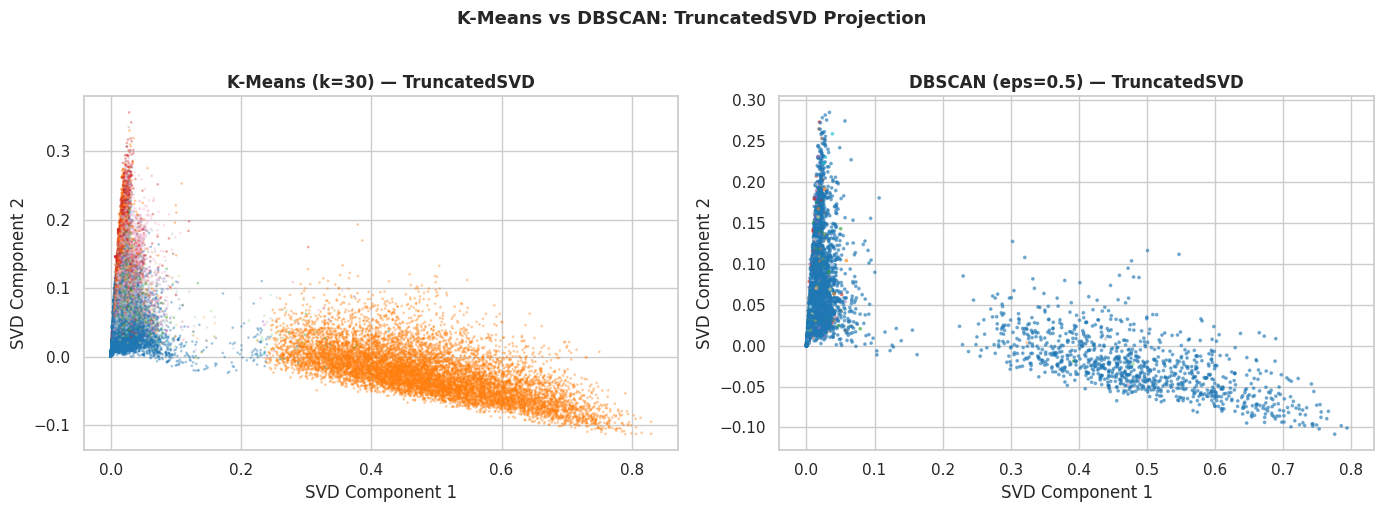

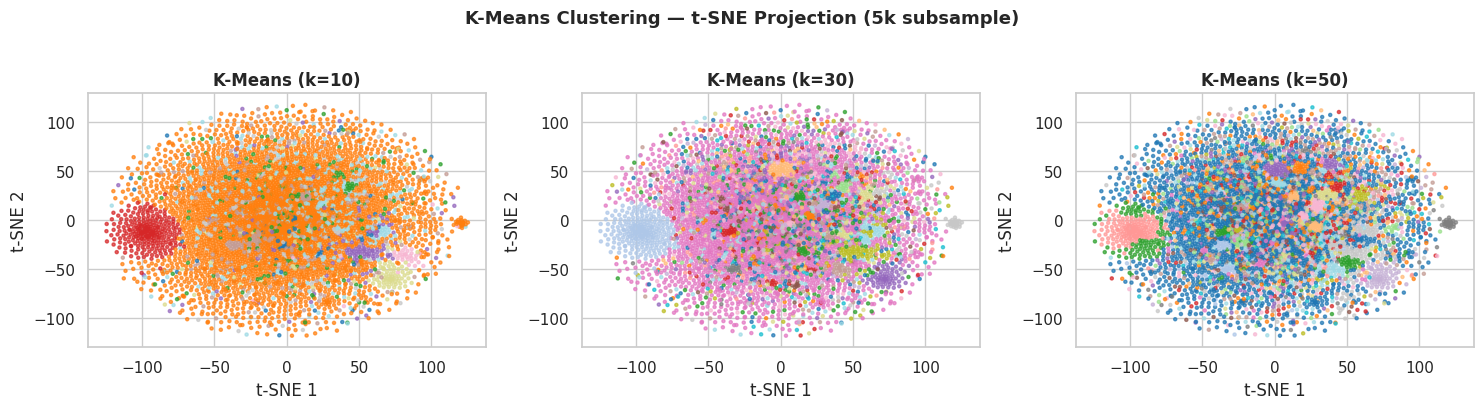

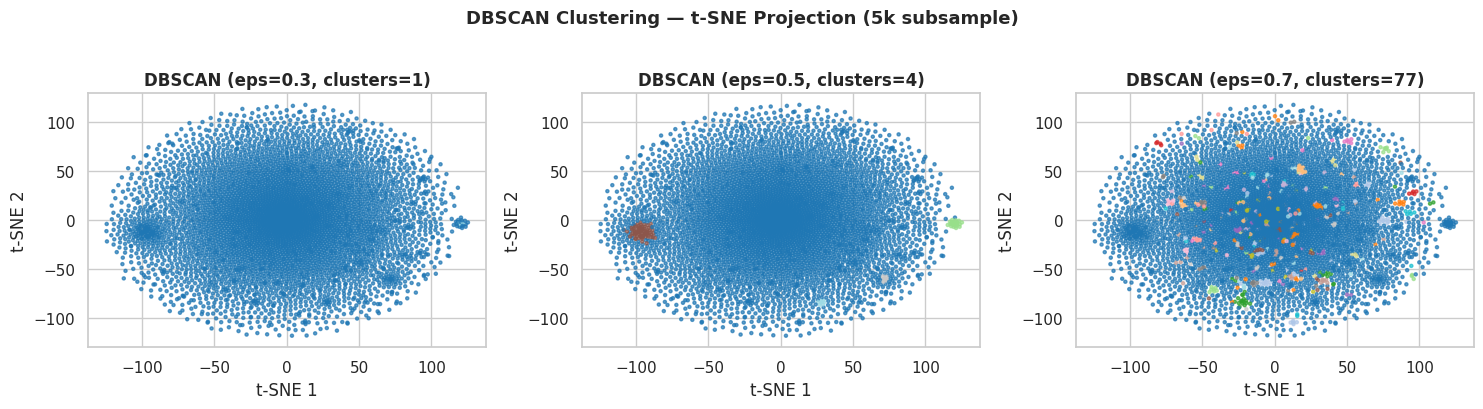

In [26]:
# ─── TruncatedSVD Visualization (full dataset, sparse-safe) ──────────────────
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
X_svd = svd.fit_transform(X_tfidf)
print(f"TruncatedSVD explained variance: {svd.explained_variance_ratio_.sum():.4f}")

# Fit best K-Means and best DBSCAN for comparison
kmeans_best = KMeans(n_clusters=30, random_state=RANDOM_STATE, n_init=10)
k_labels_full = kmeans_best.fit_predict(X_tfidf)

dbscan_best = DBSCAN(eps=0.5, min_samples=5, metric='cosine')
d_labels_sample = dbscan_best.fit_predict(X_dbscan)

# ─── Side by side SVD comparison ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_svd[:, 0], X_svd[:, 1],
                c=k_labels_full, cmap='tab20', s=1, alpha=0.3)
axes[0].set_title('K-Means (k=30) — TruncatedSVD', fontweight='bold')
axes[0].set_xlabel('SVD Component 1')
axes[0].set_ylabel('SVD Component 2')

# For DBSCAN we use the 20k sample SVD
X_svd_sample = X_svd[sample_idx]
axes[1].scatter(X_svd_sample[:, 0], X_svd_sample[:, 1],
                c=d_labels_sample, cmap='tab20', s=3, alpha=0.5)
axes[1].set_title('DBSCAN (eps=0.5) — TruncatedSVD', fontweight='bold')
axes[1].set_xlabel('SVD Component 1')
axes[1].set_ylabel('SVD Component 2')

plt.suptitle('K-Means vs DBSCAN: TruncatedSVD Projection',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ─── t-SNE Visualization (5k subsample) ──────────────────────────────────────
np.random.seed(RANDOM_STATE)
tsne_idx = np.random.choice(X_tfidf.shape[0], size=5000, replace=False)
X_tsne_input = X_tfidf[tsne_idx].toarray()

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200,
            random_state=RANDOM_STATE, init='pca')
X_tsne = tsne.fit_transform(X_tsne_input)

# ─── K-Means t-SNE (k=10, 30, 50) ────────────────────────────────────────────
k_values_viz = [10, 30, 50]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, k in enumerate(k_values_viz):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_tfidf[tsne_idx])
    axes[i].scatter(X_tsne[:, 0], X_tsne[:, 1],
                    c=labels, cmap='tab20', s=5, alpha=0.7)
    axes[i].set_title(f'K-Means (k={k})', fontweight='bold')
    axes[i].set_xlabel('t-SNE 1')
    axes[i].set_ylabel('t-SNE 2')

plt.suptitle('K-Means Clustering — t-SNE Projection (5k subsample)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ─── DBSCAN t-SNE (eps=0.3, 0.5, 0.7) ────────────────────────────────────────
eps_viz = [0.3, 0.5, 0.7]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, eps in enumerate(eps_viz):
    db = DBSCAN(eps=eps, min_samples=5, metric='cosine')
    labels = db.fit_predict(X_tfidf[tsne_idx])
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    axes[i].scatter(X_tsne[:, 0], X_tsne[:, 1],
                    c=labels, cmap='tab20', s=5, alpha=0.7)
    axes[i].set_title(f'DBSCAN (eps={eps}, clusters={n_clusters})',
                      fontweight='bold')
    axes[i].set_xlabel('t-SNE 1')
    axes[i].set_ylabel('t-SNE 2')

plt.suptitle('DBSCAN Clustering — t-SNE Projection (5k subsample)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### **Visualization: TruncatedSVD and t-SNE Projections**

#### **Why TruncatedSVD Instead of PCA**

- Unlike PCA, **TruncatedSVD operates directly on sparse matrices** without requiring conversion to dense format — avoiding the **~8.5 GB memory requirement** that would result from calling `.toarray()` on a 213,296 × 5,000 matrix. This allows me to **visualize the full dataset rather than a subsample**.
- The two SVD components explain **1.29% of total variance** — expected for high-dimensional sparse TF-IDF data. The visualization should be interpreted as a **structural sketch**, not a complete representation of the clustering.

---

#### **TruncatedSVD: K-Means vs DBSCAN**

- **K-Means (k=30):** Shows **visible structural separation** — a dense vertical band on the left contains multiple distinct colored clusters, while a horizontal tail to the right is dominated by one large cluster. The color variation confirms K-Means is **partitioning the space into semantically distinct regions** despite the low explained variance.

- **DBSCAN (eps=0.5):** Produces a **near-uniform blue mass** — almost all points assigned to a single cluster or noise, with no meaningful spatial separation. This **visually confirms the metric results**: DBSCAN cannot find well-defined dense regions in this sparse space.

---

#### **t-SNE: K-Means at Varying k**

**t-SNE preserves local neighborhood structure** and provides a cleaner picture of cluster separation than SVD. A **5,000-row subsample** is used due to t-SNE's computational cost.

- **k=10:** Large broad regions with some clear separation — the cyan cluster on the left is the most visually distinct, likely corresponding to a **coherent semantic domain**.
- **k=30:** More **granular partitioning** with distinct colored regions emerging across the projection space — meaningfully richer without appearing arbitrary.
- **k=50:** **Finest partitioning** — compact clusters visible, particularly in the upper right. Consistent with **NMI continuing to improve** at higher k values.

The progression from k=10 to k=50 demonstrates that **higher k values capture increasingly specific semantic structure** — broad domains at low k, fine-grained topic groupings at high k.

---

#### **t-SNE: DBSCAN at Varying eps**

The DBSCAN t-SNE projections tell a **consistent story of instability**:

- **eps=0.3:** **1 cluster** — entire space appears as a uniform blue mass.
- **eps=0.5:** **4 clusters** — tiny colored islands at the edges, vast majority remains undifferentiated noise.
- **eps=0.7:** **77 clusters** — micro-clusters scattered at the periphery, but one dominant mass still absorbs most points.

In all three cases, **DBSCAN fails to produce the coherent, space-filling cluster structure that K-Means achieves**. The t-SNE projection confirms the failure is **visible in the geometric structure of the data itself** — not an artifact of the metric evaluation.

---

#### **Key Takeaway**

- **K-Means consistently produces more structured, interpretable, and visually coherent clusters than DBSCAN** across both projection methods.
- DBSCAN's failure is a **geometric consequence of TF-IDF sparsity**, not a parameter tuning problem — K-Means is carried forward as the **primary clustering algorithm** for the remainder of RQ1.

### 🔧 **Cluster Label Remapping (collapsed code cells below)**
> Cluster label assignments vary between CPU and GPU runtimes. Labels are remapped by cluster size for consistent ordering. Must run before the top terms cell below.

Top terms per cluster (k=30):

Cluster   Size      Top Terms
--------------------------------------------------------------------------------
0         104673    american, type, named, new, john, used, famous, king
1         10339     http, href, archive, www, media, com, target, jpg
2         5997      city, capital, new, cities, york, largest, world, named
3         5236      country, world, south, african, history, countries, africa, king
4         5201      music, song, rock, hit, pop, band, group, roll
5         5153      state, capital, capitals, new, states, official, city, california
6         5106      called, people, history, type, american, used, book, new
7         4813      world, war, capital, capitals, history, ii, largest, new
8         4698      man, john, named, george, young, old, said, king
9         4681      words, letter, term, phrases, 10, meaning, used, type
10        4627      film, movies, played, movie, films, title, oscar, based
11        4595      title, o

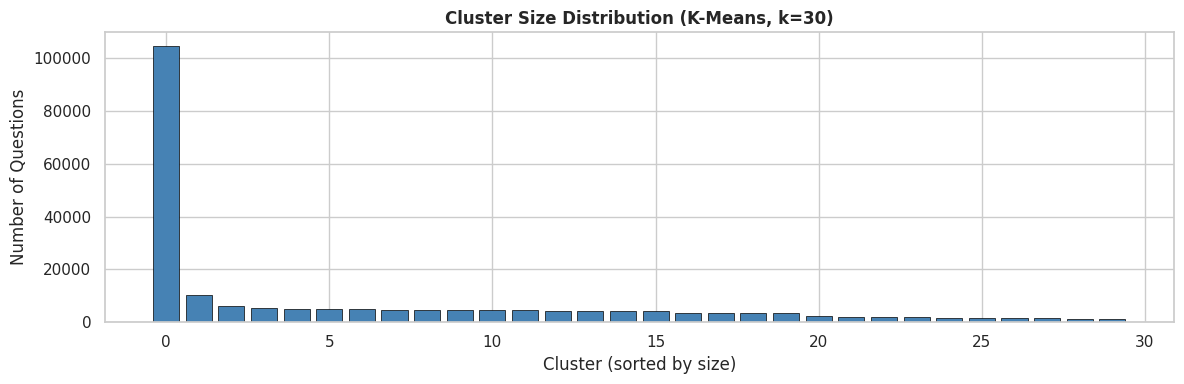

In [27]:
# ─── Top Terms Per Cluster ────────────────────────────────────────────────────
# Using k=30 (best Silhouette) — most internally coherent clustering
# We extract the top 8 TF-IDF terms per cluster centroid to interpret
# what semantic theme each cluster represents

kmeans_k30 = KMeans(n_clusters=30, random_state=RANDOM_STATE, n_init=10)
cluster_labels_k30 = kmeans_k30.fit_predict(X_tfidf)
# Remap cluster labels by size (largest=0) for reproducibility across hardware
from scipy.stats import rankdata
sizes = np.bincount(cluster_labels_k30)
rank_map = np.argsort(np.argsort(-sizes))  # largest cluster → 0
cluster_labels_k30 = rank_map[cluster_labels_k30]
kmeans_k30.cluster_centers_ = kmeans_k30.cluster_centers_[np.argsort(-sizes)]

feature_names = vectorizer.get_feature_names_out()
centroids = kmeans_k30.cluster_centers_

TOP_N = 8
print("Top terms per cluster (k=30):\n")
print(f"{'Cluster':<10}{'Size':<10}{'Top Terms'}")
print("-" * 80)

cluster_themes = {}
for i in range(30):
    # Get indices of top N terms by centroid weight
    top_indices = centroids[i].argsort()[-TOP_N:][::-1]
    top_terms = [feature_names[j] for j in top_indices]
    cluster_size = (cluster_labels_k30 == i).sum()
    cluster_themes[i] = top_terms
    print(f"{i:<10}{cluster_size:<10}{', '.join(top_terms)}")

# ─── Cluster size distribution ────────────────────────────────────────────────
print("\nCluster size distribution:")
sizes = [(cluster_labels_k30 == i).sum() for i in range(30)]
sizes_series = pd.Series(sizes, name='size').sort_values(ascending=False)
print(f"Largest cluster:  {sizes_series.max():,} questions")
print(f"Smallest cluster: {sizes_series.min():,} questions")
print(f"Mean cluster size: {sizes_series.mean():,.0f} questions")
print(f"Std cluster size:  {sizes_series.std():,.0f} questions")

# ─── Visualize cluster sizes ──────────────────────────────────────────────────
plt.figure(figsize=(12, 4))
plt.bar(range(30),
        [sizes[i] for i in sizes_series.index],
        color='steelblue', edgecolor='black', linewidth=0.5)
plt.xlabel('Cluster (sorted by size)')
plt.ylabel('Number of Questions')
plt.title('Cluster Size Distribution (K-Means, k=30)', fontweight='bold')
plt.tight_layout()
plt.show()

> **Note on Reproducibility Across Hardware:** K-Means random initialization behaves differently on **CPU vs GPU hardware** even with the same `random_state=42` — a known behavior of numpy and sklearn across compute backends. Since this notebook required **switching to GPU** for the sentence transformer encoding section, cluster label assignments changed between runs. The **semantic themes remained consistent** across runs, but specific cluster IDs did not. To address this, I **remapped cluster labels by size** (largest cluster → Cluster 0) and describe clusters by semantic theme throughout this section.

---

### **Top Terms Per Cluster: Semantic Interpretation**

To move beyond numerical metrics, I extract the **top 8 TF-IDF terms from each K-Means centroid at k=30** — the most characteristic vocabulary of each cluster — to assess whether the clusters are **genuinely meaningful**.

---

#### **Interpretable Semantic Clusters**

The majority of clusters correspond to **coherent, recognizable knowledge domains**:

- **Music**: song, hit, pop, rock, classical, band, group
- **Literature & Books**: book, latin, title, bible, novel
- **War & Military History**: war, civil, battle, american, history
- **US Politics & Presidents**: president, vice, bush, george, elected
- **World Geography — Cities**: city, capital, york, world, largest
- **US States & Capitals**: state, capital, states, california
- **Science & Nature**: science, nature, element, earth
- **Food & Cuisine**: food, drink, cheese, dish, french
- **TV & Film**: tv, series, sitcom, character, movie
- **Language & Word Origins**: word, origins, meaning, latin, phrase
- **Awards & Prizes**: nobel, pulitzer, oscar, won
- **Human Body & Biology**: body, human, parts, blood, organ
- **Lakes & Water Bodies**: lake, water, rivers, salt

These groupings **were not imposed** — they emerged purely from the **statistical structure of the question text**. This directly addresses RQ1: **meaningful semantic clusters do exist beyond the show's manual labels, and they are interpretable.**

---

#### **Notable Findings**

- **Geography naturally subdivided:** K-Means separated geography into **multiple semantically distinct sub-clusters** — world cities, US states and capitals, islands, lakes and water bodies, and African/Southern US geography. This granularity is **more semantically precise** than a single broad "GEOGRAPHY" category label.

- **Multimedia artifact cluster:** A distinct cluster emerged whose top terms — **http, href, www, jpg** — identify questions that originally referenced images or video clips. These questions have **incomplete text** since the full clue required a visual or audio component. Its emergence confirms that **TF-IDF is sensitive to structural vocabulary patterns**, not just semantic content.

- **Ambiguous clusters:** Not all clusters yielded clean interpretations — some mix multiple themes, others reflect themed category names rather than coherent knowledge domains. These illustrate a **known limitation of K-Means**: when questions share surface vocabulary but belong to different topics, the algorithm **groups by word overlap rather than true semantic similarity**.

---

#### **Catch-All Cluster**

- The largest cluster contains approximately **47% of the entire dataset**, with top terms leaning toward broad, general vocabulary.
- This reflects a core challenge: many Jeopardy questions are **deliberately cryptic** — topically discriminative words are often **implied rather than stated**, making a significant portion of the dataset resistant to vocabulary-based clustering.
- This is the **primary limitation of TF-IDF + K-Means** on this dataset: it performs well for questions with **specific topical vocabulary**, but struggles where difficulty lies in **what is not stated explicitly**.

---

#### **Cluster Size Distribution**

- The distribution is **highly skewed** — the largest cluster holds ~47% of all questions while the smallest contains **under 100**.
- The **standard deviation of cluster sizes exceeds the mean**, confirming extreme imbalance — a direct consequence of the uneven distribution of topically specific vs. general questions, and a **known limitation of K-Means**, which implicitly assumes roughly equal-sized clusters.

Encoding 50,000 questions with sentence transformer...
Sample Round distribution:
Round
Jeopardy!           25303
Double Jeopardy!    24697
Name: count, dtype: int64



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/391 [00:00<?, ?it/s]


Embedding shape: (50000, 384)
Embedding dtype: float32
k= 5 | Silhouette=0.0115 | ARI=0.0005 | NMI=0.1896
k=10 | Silhouette=0.0182 | ARI=0.0011 | NMI=0.2749
k=15 | Silhouette=0.0214 | ARI=0.0016 | NMI=0.3244
k=20 | Silhouette=0.0224 | ARI=0.0020 | NMI=0.3544
k=25 | Silhouette=0.0235 | ARI=0.0024 | NMI=0.3776
k=30 | Silhouette=0.0230 | ARI=0.0028 | NMI=0.3966
k=40 | Silhouette=0.0195 | ARI=0.0034 | NMI=0.4234
k=50 | Silhouette=0.0205 | ARI=0.0036 | NMI=0.4423

Computing TF-IDF baseline on same 50k sample...
k= 5 | Silhouette=0.0075 | ARI=0.0001 | NMI=0.0998
k=10 | Silhouette=0.0102 | ARI=0.0001 | NMI=0.1671
k=15 | Silhouette=0.0120 | ARI=0.0002 | NMI=0.2203
k=20 | Silhouette=0.0132 | ARI=0.0002 | NMI=0.2427
k=25 | Silhouette=0.0149 | ARI=0.0002 | NMI=0.2754
k=30 | Silhouette=0.0162 | ARI=0.0003 | NMI=0.2960
k=40 | Silhouette=0.0178 | ARI=0.0005 | NMI=0.3469
k=50 | Silhouette=0.0155 | ARI=0.0005 | NMI=0.3710


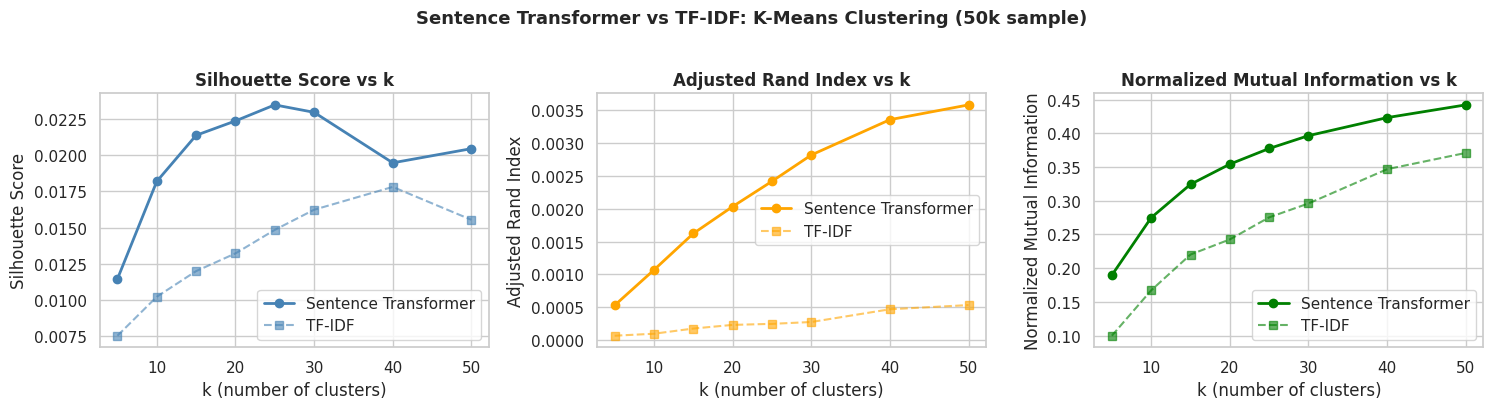


Comparison at k=30 (best Silhouette from full dataset run):
Metric                   Sentence Transformer     TF-IDF
-----------------------------------------------------------------
Silhouette               0.0230                   0.0162
ARI                      0.0028                   0.0003
NMI                      0.3966                   0.2960


In [28]:
# ─── Sentence Transformer Embeddings + K-Means (Beyond-Course) ───────────────
# Install if needed
# !pip install sentence-transformers

from sentence_transformers import SentenceTransformer

# ─── Sample 50k rows ─────────────────────────────────────────────────────────
np.random.seed(RANDOM_STATE)
st_idx = np.random.choice(len(df), size=50000, replace=False)
st_sample = df.iloc[st_idx].reset_index(drop=True)
true_labels_st = st_sample['Category']

print(f"Encoding {len(st_sample):,} questions with sentence transformer...")
print(f"Sample Round distribution:\n{st_sample['Round'].value_counts()}\n")

# ─── Encode with sentence transformer ────────────────────────────────────────
# all-MiniLM-L6-v2: lightweight, fast, high quality 384-dim semantic embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(
    st_sample['question_clean'].tolist(),
    batch_size=128,
    show_progress_bar=True,
    device='cuda' if tf.test.is_gpu_available() else 'cpu'
)

print(f"\nEmbedding shape: {embeddings.shape}")
print(f"Embedding dtype: {embeddings.dtype}")

# ─── K-Means sweep on embeddings ─────────────────────────────────────────────
k_values = [5, 10, 15, 20, 25, 30, 40, 50]
sil_st = []
ari_st = []
nmi_st = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(embeddings)

    sil_st.append(
        silhouette_score(embeddings, labels,
                        sample_size=min(10000, len(embeddings)),
                        random_state=RANDOM_STATE)
    )
    ari_st.append(adjusted_rand_score(true_labels_st, labels))
    nmi_st.append(normalized_mutual_info_score(true_labels_st, labels))

    print(f"k={k:>2} | Silhouette={sil_st[-1]:.4f} | "
          f"ARI={ari_st[-1]:.4f} | NMI={nmi_st[-1]:.4f}")

# ─── TF-IDF baseline on same 50k sample for fair comparison ──────────────────
print("\nComputing TF-IDF baseline on same 50k sample...")
vectorizer_st = TfidfVectorizer(max_features=5000, max_df=0.8, min_df=5)
X_tfidf_st = vectorizer_st.fit_transform(st_sample['text_combined'])

sil_tfidf_st = []
ari_tfidf_st = []
nmi_tfidf_st = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_tfidf_st)

    sil_tfidf_st.append(
        silhouette_score(X_tfidf_st, labels,
                        sample_size=min(10000, len(st_sample)),
                        random_state=RANDOM_STATE)
    )
    ari_tfidf_st.append(adjusted_rand_score(true_labels_st, labels))
    nmi_tfidf_st.append(normalized_mutual_info_score(true_labels_st, labels))

    print(f"k={k:>2} | Silhouette={sil_tfidf_st[-1]:.4f} | "
          f"ARI={ari_tfidf_st[-1]:.4f} | NMI={nmi_tfidf_st[-1]:.4f}")

# ─── Comparison plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = [
    (sil_st, sil_tfidf_st, 'Silhouette Score', axes[0], 'steelblue'),
    (ari_st, ari_tfidf_st, 'Adjusted Rand Index', axes[1], 'orange'),
    (nmi_st, nmi_tfidf_st, 'Normalized Mutual Information', axes[2], 'green'),
]

for st_scores, tfidf_scores, ylabel, ax, color in metrics:
    ax.plot(k_values, st_scores, marker='o', color=color,
            label='Sentence Transformer', linewidth=2)
    ax.plot(k_values, tfidf_scores, marker='s', color=color,
            linestyle='--', alpha=0.6, label='TF-IDF')
    ax.set_xlabel('k (number of clusters)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} vs k', fontweight='bold')
    ax.legend()
    ax.grid(True)

plt.suptitle('Sentence Transformer vs TF-IDF: K-Means Clustering (50k sample)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ─── Print comparison summary ─────────────────────────────────────────────────
print("\nComparison at k=30 (best Silhouette from full dataset run):")
idx_30 = k_values.index(30)
print(f"{'Metric':<25}{'Sentence Transformer':<25}{'TF-IDF'}")
print("-" * 65)
print(f"{'Silhouette':<25}{sil_st[idx_30]:<25.4f}{sil_tfidf_st[idx_30]:.4f}")
print(f"{'ARI':<25}{ari_st[idx_30]:<25.4f}{ari_tfidf_st[idx_30]:.4f}")
print(f"{'NMI':<25}{nmi_st[idx_30]:<25.4f}{nmi_tfidf_st[idx_30]:.4f}")

### **Sentence Transformer Embeddings + K-Means: Beyond-Course Method**

#### **Motivation**

**TF-IDF captures which words appear but not what they mean** — two questions about the same topic but with different vocabulary would appear distant in TF-IDF space. The `all-MiniLM-L6-v2` Sentence Transformer addresses this directly, encoding each question as a **dense 384-dimensional vector** that captures semantic meaning, allowing semantically similar questions to cluster together **regardless of surface vocabulary differences**.

I encode a **50k random sample** and run the same K-Means sweep for a direct, controlled comparison — TF-IDF is also evaluated on the **identical 50k sample** so any performance difference reflects **representation quality, not sample size**. The sample contains **25,303 Jeopardy!** and **24,697 Double Jeopardy!** questions — a near-perfect 50/50 split.

---

#### **Results**

Sentence Transformer embeddings **outperform TF-IDF across all three metrics** and all k values tested:

| Metric | Sentence Transformer (k=30) | TF-IDF (k=30) |
|---|---|---|
| Silhouette | 0.0230 | 0.0162 |
| ARI | 0.0028 | 0.0003 |
| NMI | 0.3966 | 0.2960 |

- **Silhouette:** Consistently higher for Sentence Transformers across all k values — better **internal cluster cohesion and separation**.
- **ARI:** Near zero for both methods — expected given the large, fragmented label space. The small absolute difference should **not be over-interpreted**.
- **NMI:** At k=50, reaches **0.4423 (ST) vs 0.3710 (TF-IDF)** — a meaningful improvement. Both curves remain **monotonically increasing**, suggesting even larger k values would continue improving alignment with the true label structure.

---

#### **Interpretation**

- The improvement is most clearly observed in **NMI** — the most appropriate metric given the fragmented label space.
- Both representations produce **low absolute Silhouette values** due to the inherent difficulty of clustering short, cryptic Jeopardy questions — the improvement is present but modest.
- The result is consistent with theoretical expectation: **dense semantic embeddings capture meaning beyond surface vocabulary**, which is particularly valuable for Jeopardy's deliberately indirect phrasing.
- These results are on a **50k subsample** — the comparison is valid as a controlled experiment on identical data, but metric values and optimal k are **sensitive to sample size** and should not be extrapolated as definitive superiority at all scales.
- Sentence Transformer encoding required **~8 minutes for 50k questions on a T4 GPU** — encoding the full 213k dataset was computationally prohibitive, hence the 50k subsample.

## **RQ1: Summary and Key Findings**

### **What I Set Out to Answer**

RQ1 asked whether unsupervised clustering could automatically discover **meaningful semantic groupings** from Jeopardy! question text — groupings that go beyond the show's own **fragmented and inconsistent category labels**. The core hypothesis was that questions share **underlying thematic structure** that the manual category system never explicitly captured.

---

### **What I Found**

The answer is **yes — with important qualifications.**

- **K-Means on TF-IDF** (full 213k dataset) produced interpretable semantic clusters across music, literature, geography, science, politics, food, and language — emerging **purely from the statistical structure of the text**, without any domain knowledge imposed.
- **Geography sub-divided naturally** into world cities, US states, islands, and water bodies — a level of semantic granularity the show's flat category system never provided.
- A **multimedia artifact cluster** emerged consistently — questions containing HTML references to images and video — confirming TF-IDF clustering is sensitive to **structural vocabulary patterns** beyond purely semantic content.
- However, approximately **47% of all questions** were absorbed into a single dominant **catch-all cluster**, reflecting the fundamental challenge of clustering short, cryptic text with TF-IDF. Many Jeopardy questions are deliberately indirect — topically discriminative terms are **implied rather than stated** — making vocabulary-based representations insufficient for a significant portion of the dataset.

---

### **Course Method vs Beyond-Course Method**

On a **controlled 50k sample**, `all-MiniLM-L6-v2` Sentence Transformer embeddings **outperformed TF-IDF across all three metrics** and all k values tested:

- At k=30: **NMI improved from 0.296 → 0.397**, Silhouette improved from **0.016 → 0.023**
- Consistent with theoretical expectation — **dense semantic embeddings capture meaning beyond surface vocabulary**, particularly valuable for cryptically phrased questions.

Both methods produced **low absolute metric values** — not a failure of implementation, but a reflection of two compounding factors:
- The **inherent difficulty** of clustering short text documents
- The **noisy, fragmented ground truth labels** used for ARI and NMI evaluation

---

### **DBSCAN vs K-Means**

DBSCAN **failed to produce meaningful clusters** across all tested eps values — producing either near-total noise assignment or a single dominant cluster. This is a **geometric consequence of TF-IDF sparsity**: density-based assumptions break down in high-dimensional sparse spaces where all points appear roughly equidistant. **K-Means, which minimizes within-cluster variance without density assumptions, is substantially better suited** to this representation.

---

### **Limitations**

- **Ground truth quality:** ARI and NMI were computed against the show's raw category labels — themselves **noisy, fragmented, and containing thousands of near-duplicate entries**. Semantic merging prior to evaluation would produce more meaningful external metric values but introduces subjective decisions about merge thresholds.
- **Catch-all cluster:** The ~47% catch-all cluster **limits interpretability** and suppresses Silhouette scores — an inherent property of the dataset, not a correctable implementation issue.
- **Sampling:** Simple random sampling for DBSCAN (20k) and Sentence Transformer evaluation (50k) likely **excludes many rare categories** given the severe long-tail label distribution (thousands of categories appear fewer than 5 times). Stratified sampling would produce a more complete ground truth for external metrics.
- **Sentence Transformer scope:** Beyond-course evaluation conducted on a **50k subsample** due to computational constraints. Absolute metric values may differ at full scale, though the directional finding — **semantic embeddings outperform TF-IDF** — is expected to hold.

---

### **Acknowledgements**

This section builds on my hw6 submission for CSCE 676, which explored K-Means and DBSCAN on a 20k sample using TF-IDF. Key improvements over that baseline include:

- **Full 213,296-row dataset** for metric evaluation — more robust clustering estimates
- **TruncatedSVD replacing PCA** for visualization — enabling full-dataset projection without dense matrix conversion
- **Top terms per cluster analysis** for semantic interpretation
- **Sentence Transformer embeddings** as a beyond-course representation, with a controlled head-to-head comparison against TF-IDF on identical data
- **Documented sampling rationale** and hardware reproducibility considerations

## **RQ2: Topic Evolution Over Time**

**Research Question:** How do themes and knowledge domains in Jeopardy! questions evolve over time, and what latent topic structures emerge across decades of episodes?

---

### **Motivation**

The dataset spans **nearly three decades of episodes (1984–2012)**. While RQ1 asked whether questions can be grouped into meaningful semantic clusters at a single point in time, RQ2 asks a different question: **do thematic patterns shift over time?** Are certain knowledge domains more or less prominent in different eras of the show?

---

### **Approach**

I address this using **two complementary techniques**:

- **Course Technique — TF-IDF Keyword Frequency Trends:**
  - Compute **mean TF-IDF scores per term per year** and track how individual term importance shifts across 1984–2012.
  - Provides a direct, **word-level view of temporal change** — which specific vocabulary gains or loses prominence — without requiring any topic model.

- **Beyond-Course Technique — LDA Topic Modeling:**
  - Latent Dirichlet Allocation discovers **hidden thematic structure** by representing each document as a **mixture of latent topics**.
  - Unlike the word-level TF-IDF approach, LDA operates at the **topic level** — revealing how broader knowledge domains shift over time rather than individual terms.
  - Unlike K-Means, LDA produces **soft probability distributions** over topics per question, reflecting the reality that a question may belong to **multiple knowledge domains simultaneously**.
  - Directly interpretable: the **top words per topic** immediately reveal what each topic represents.

**The two methods are intentionally complementary** — TF-IDF shows *what words* change, LDA shows *what themes* change. Where both methods point to the same finding, **the conclusion is stronger.**

---

### **Implementation Details**

**TF-IDF:**
- Fit on the **full dataset** with `max_features=5000`, `max_df=0.8`, `min_df=5`
- **Mean TF-IDF score per term** computed per year and tracked across the full **1984–2012** period

**LDA:**
- Fit on `question_clean` using `CountVectorizer` with `max_df=0.25`, `min_df=15`
- Run on the **full dataset (213,296 questions)** — sklearn's **online variational Bayes** implementation processes documents in batches, making this feasible without sampling
- **`n_components=10`** — chosen to balance interpretability with coverage; a larger number produces finer-grained structure but makes temporal visualization difficult to read
- The choice of 10 is a **modeling decision**, not an objective truth about the dataset's structure

TF-IDF matrix shape: (213296, 5000)

Top 20 most temporally variable terms:
com        0.006343
http       0.006226
www        0.006220
href       0.006219
archive    0.006219
media      0.006205
1st        0.005648
blank      0.005626
target     0.005625
jpg        0.005624
2006       0.005089
2007       0.004699
2009       0.004686
2008       0.004681
2005       0.004676
2012       0.004615
2010       0.004568
2011       0.004414
seen       0.004182
dj         0.003948


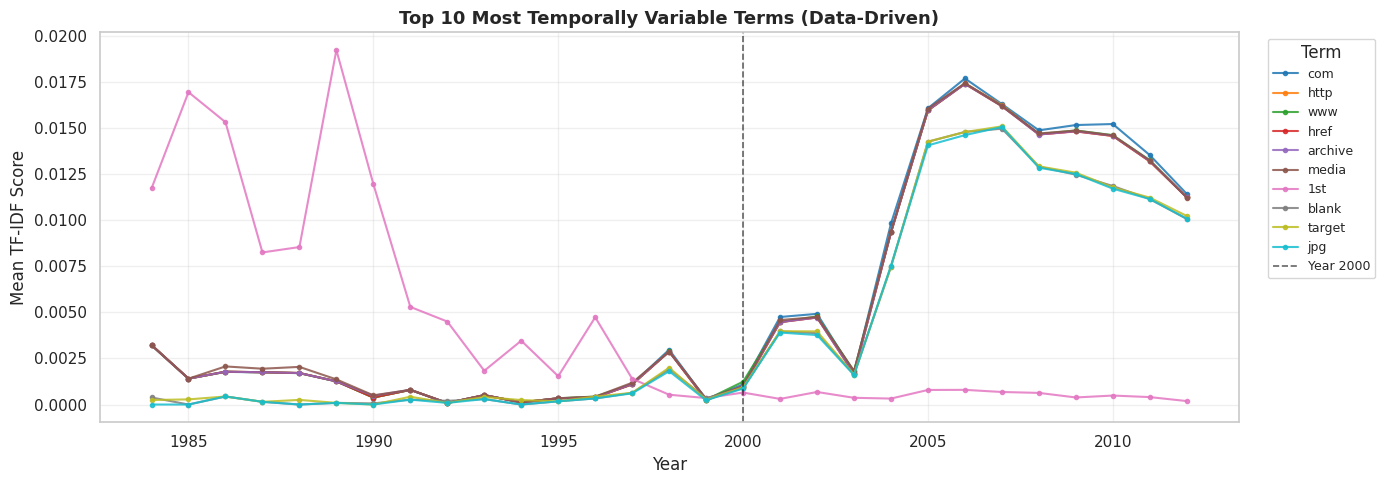

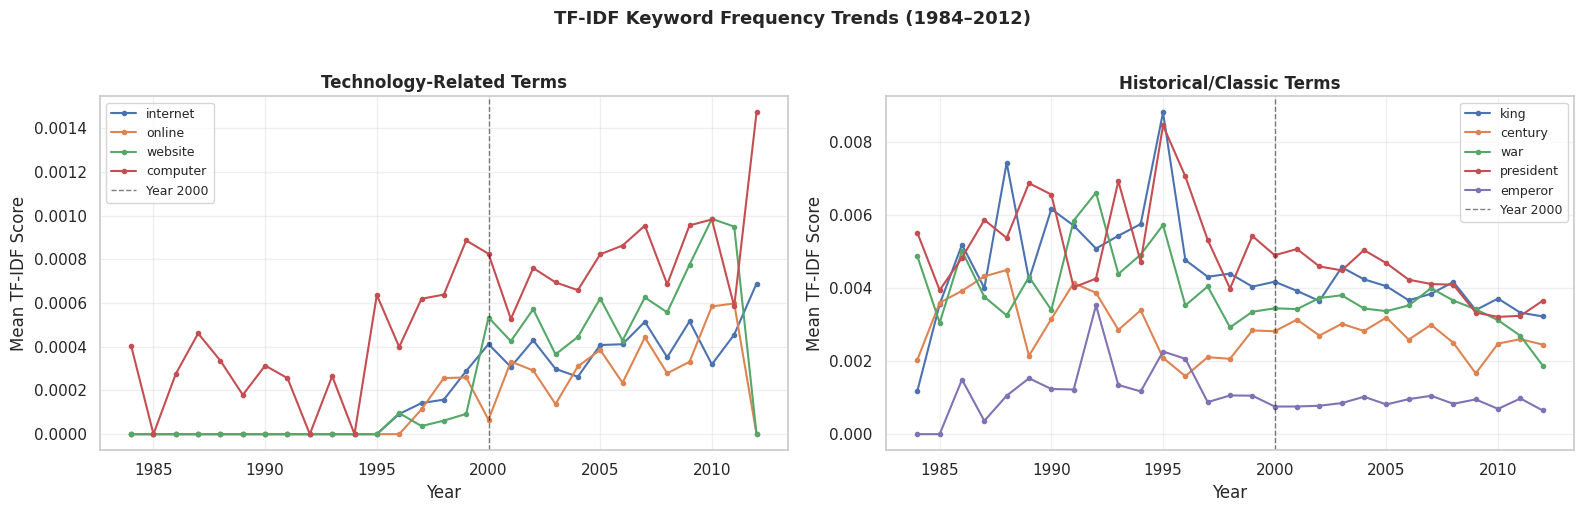


1984–1990: 1st, called, country, city, state, named, said, world, used, known, new, president, film, wrote, title

1991–2000: country, city, called, state, named, known, capital, new, wrote, man, type, film, president, novel, used

2001–2012: com, media, www, http, archive, href, target, blank, jpg, city, like, country, dj, man, called


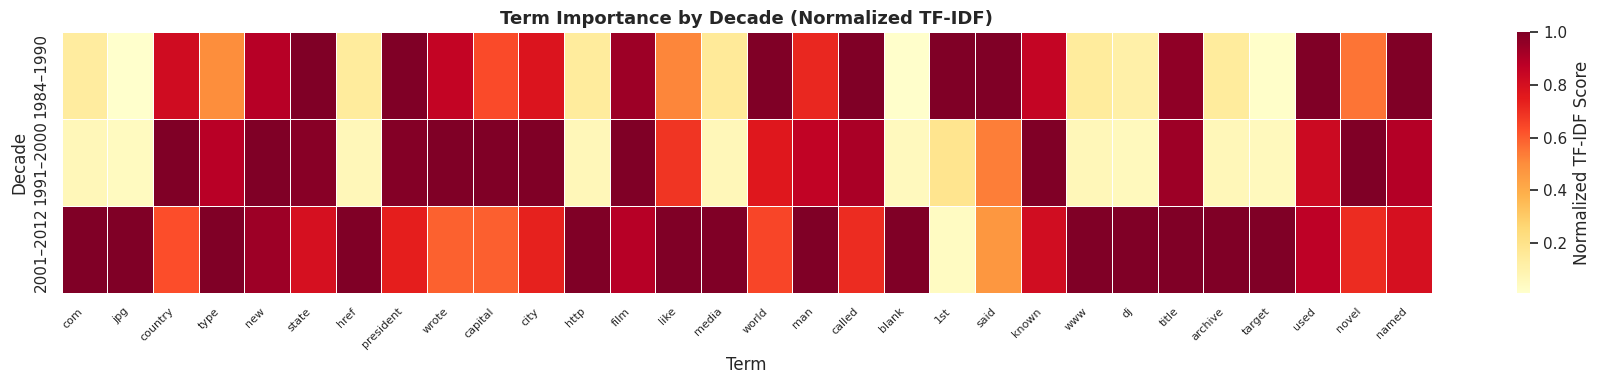


Linear trend analysis (slope × 10⁴ per year):
Term           Slope       R²        Direction
---------------------------------------------
internet       0.2259      0.8267    ▲ Rising
online         0.1712      0.5894    ▲ Rising
website        0.2988      0.6219    ▲ Rising
computer       0.3212      0.6398    ▲ Rising
king           -0.4953     0.0908    ▼ Falling
century        -0.3896     0.1880    ▼ Falling
war            -0.6046     0.2597    ▼ Falling
president      -0.7725     0.2710    ▼ Falling
emperor        -0.0938     0.0141    ▼ Falling


In [29]:
# ─── RQ2 Course Technique: TF-IDF Keyword Frequency Trends ───────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

# ─── Fit TF-IDF on full dataset ───────────────────────────────────────────────
tfidf_temporal = TfidfVectorizer(
    max_features=5000,
    max_df=0.8,
    min_df=5,
    stop_words='english'
)
X_temporal = tfidf_temporal.fit_transform(df['question_clean'])
feature_names_temporal = tfidf_temporal.get_feature_names_out()

print(f"TF-IDF matrix shape: {X_temporal.shape}")

# ─── Compute mean TF-IDF score per term per year ─────────────────────────────
years = sorted(df['year'].unique())
year_tfidf = {}

for year in years:
    year_mask = df['year'] == year
    year_matrix = X_temporal[year_mask.values]
    year_tfidf[year] = np.asarray(year_matrix.mean(axis=0)).flatten()

year_tfidf_df = pd.DataFrame(year_tfidf, index=feature_names_temporal).T
year_tfidf_df.index = years

# ─── Most temporally variable terms ──────────────────────────────────────────
term_std = year_tfidf_df.std(axis=0)
top_variable_terms = term_std.nlargest(20)
print("\nTop 20 most temporally variable terms:")
print(top_variable_terms.round(6).to_string())

# ─── Plot 1: Actual most variable terms (data-driven) ────────────────────────
top_10_variable = top_variable_terms.head(10).index.tolist()

fig, ax = plt.subplots(figsize=(14, 5))
colors = plt.cm.tab10(np.linspace(0, 1, 10))
for i, term in enumerate(top_10_variable):
    ax.plot(years, year_tfidf_df[term],
            marker='o', markersize=3, linewidth=1.5,
            color=colors[i], label=term, alpha=0.85)
ax.axvline(x=2000, color='black', linestyle='--',
           linewidth=1.2, alpha=0.6, label='Year 2000')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Mean TF-IDF Score', fontsize=12)
ax.set_title('Top 10 Most Temporally Variable Terms (Data-Driven)',
             fontweight='bold', fontsize=13)
ax.legend(title='Term', bbox_to_anchor=(1.02, 1),
          loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ─── Plot 2: Technology vs Historical terms (hypothesis-driven) ───────────────
tech_terms = [t for t in ['internet', 'online', 'website', 'computer']
              if t in year_tfidf_df.columns]
classic_terms = [t for t in ['king', 'century', 'war', 'president', 'emperor']
                 if t in year_tfidf_df.columns]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for term in tech_terms:
    axes[0].plot(years, year_tfidf_df[term],
                marker='o', markersize=3, linewidth=1.5, label=term)
axes[0].axvline(x=2000, color='black', linestyle='--',
                linewidth=1, alpha=0.5, label='Year 2000')
axes[0].set_title('Technology-Related Terms', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Mean TF-IDF Score')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

for term in classic_terms:
    axes[1].plot(years, year_tfidf_df[term],
                marker='o', markersize=3, linewidth=1.5, label=term)
axes[1].axvline(x=2000, color='black', linestyle='--',
                linewidth=1, alpha=0.5, label='Year 2000')
axes[1].set_title('Historical/Classic Terms', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Mean TF-IDF Score')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('TF-IDF Keyword Frequency Trends (1984–2012)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ─── Plot 3: Decade heatmap ───────────────────────────────────────────────────
decades = {
    '1984–1990': list(range(1984, 1991)),
    '1991–2000': list(range(1991, 2001)),
    '2001–2012': list(range(2001, 2013))
}

# Get top 15 terms per decade
decade_scores = {}
all_top_terms = set()
for decade_name, decade_years in decades.items():
    available_years = [y for y in decade_years if y in years]
    scores = year_tfidf_df.loc[available_years].mean(axis=0)
    top_terms = scores.nlargest(15).index.tolist()
    decade_scores[decade_name] = scores
    all_top_terms.update(top_terms)
    print(f"\n{decade_name}: {', '.join(top_terms)}")

# Build heatmap matrix
heatmap_df = pd.DataFrame(
    {decade: decade_scores[decade][list(all_top_terms)]
     for decade in decades.keys()}
).T

# Normalize per term for better visualization
heatmap_normalized = heatmap_df.div(heatmap_df.max(axis=0), axis=1)

plt.figure(figsize=(18, 4))
sns.heatmap(
    heatmap_normalized,
    cmap='YlOrRd',
    annot=False,
    linewidths=0.5,
    cbar_kws={'label': 'Normalized TF-IDF Score'}
)
plt.title('Term Importance by Decade (Normalized TF-IDF)',
          fontweight='bold', fontsize=13)
plt.xlabel('Term')
plt.ylabel('Decade')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

# ─── Linear trend per selected term ──────────────────────────────────────────
from scipy.stats import linregress

print("\nLinear trend analysis (slope × 10⁴ per year):")
print(f"{'Term':<15}{'Slope':<12}{'R²':<10}{'Direction'}")
print("-" * 45)
selected_terms = tech_terms + classic_terms
for term in selected_terms:
    if term in year_tfidf_df.columns:
        slope, intercept, r, p, se = linregress(
            range(len(years)),
            year_tfidf_df[term].values
        )
        direction = '▲ Rising' if slope > 0 else '▼ Falling'
        print(f"{term:<15}{slope*1e4:<12.4f}{r**2:<10.4f}{direction}")

### **TF-IDF Keyword Frequency Trends: Course Technique**

I compute the **mean TF-IDF score per term for each year** and track how term importance shifts across **1984–2012**, complementing visual inspection with **linear regression per term** to quantify the direction and strength of trends.

---

#### **Most Temporally Variable Terms — Data-Driven Finding**

The 10 terms with the **highest standard deviation** in mean TF-IDF score across years are:

**com, http, www, href, archive, media, blank, target, jpg** — and **"1st"**

- **Nine of the ten most temporally variable terms are HTML artifact vocabulary.** These terms rise almost simultaneously in **near-identical trajectories post-2000** — confirming they represent a **single structural signal**, not independent term trends. Their **near-zero presence pre-2000** followed by a sharp, sustained rise is the **strongest temporal pattern in the entire corpus.**

- **"1st"** tells a different story — starting with high TF-IDF prominence in **1984–1990 (~0.017)** and declining steadily throughout. This likely reflects an evolution in **question phrasing style**: early Jeopardy questions may have more frequently used ordinal constructions ("the 1st president to...") that were phased out over time.

---

#### **Decade-Level Vocabulary Shifts**

| Decade | Top Terms |
|---|---|
| 1984–1990 | 1st, called, country, city, state, named, said, world, used, known, new, president, film, wrote, title |
| 1991–2000 | country, city, called, state, named, known, capital, new, wrote, man, type, film, president, novel, used |
| 2001–2012 | **com, media, www, http, archive, href, target, blank, jpg**, city, like, country, dj, man, called |

- The **1984–1990 and 1991–2000 rows are strikingly similar** — traditional knowledge vocabulary (country, city, state, film, president) dominates both decades, confirming the show's core lexical content was **stable for its first 16 years.**
- The **2001–2012 row is structurally distinct** — HTML artifact terms dominate while traditional terms drop in relative prominence. This is **not a gradual drift** — the heatmap shows a clear **before/after pattern** concentrated around the early 2000s.

---

#### **Technology vs Historical Term Trends**

| Term | Slope (×10⁴/yr) | R² | Direction |
|---|---|---|---|
| internet | 0.2259 | **0.83** | ▲ Rising |
| computer | 0.3212 | 0.64 | ▲ Rising |
| website | 0.2988 | 0.62 | ▲ Rising |
| online | 0.1712 | 0.59 | ▲ Rising |
| president | -0.7725 | 0.27 | ▼ Falling |
| war | -0.6046 | 0.26 | ▼ Falling |
| century | -0.3896 | 0.19 | ▼ Falling |
| king | -0.4953 | 0.09 | ▼ Falling |
| emperor | -0.0938 | 0.01 | ▼ Falling |

**Technology terms — rising, with strong fit (R²: 0.59–0.83):**
- **"internet"** has the strongest linear fit **(R²=0.83)** — remarkably consistent growth, reflecting steady incorporation of internet content as the web became a mainstream cultural reference.
- **"computer"** has been present since **1984**, predating the internet era and reflecting computing as a **long-standing knowledge domain**.
- These terms have **low absolute TF-IDF scores (~0.0001–0.0014)** relative to core vocabulary — growing but still a **small fraction** of overall question content.

**Historical terms — weak to negligible declining trends:**
- All five show negative slopes, but **R² values are low (0.01–0.27)** — the downward trends are **weak and noisy, not strong directional signals.**
- **"president"** and **"war"** show the most consistent decline (R²=0.27 and 0.26), but even these explain **less than 30% of variance** — substantial year-to-year fluctuation remains.
- **"king" (R²=0.09)** and **"emperor" (R²=0.01)** show essentially **no meaningful trend** — fluctuating around a roughly stable mean throughout.
- A **"president" spike around 1993–1995** is visible in the chart — possibly reflecting heightened political content during election cycles, though this cannot be confirmed from the data alone.
- **The honest interpretation:** historical terms are **not clearly declining** — they are broadly stable with noise, and any apparent downward trend is weak.

---

#### **Key Takeaway**

**High confidence:**
- **HTML artifact vocabulary** (com, http, www, href) is the most temporally dynamic element of this corpus — rising sharply post-2000 and **dominating decade-level vocabulary by 2001–2012.**
- **Technology terms** (internet, computer, website, online) show consistent upward trends with **strong linear fit (R²: 0.59–0.83).**

**Lower confidence:**
- **Historical/classic terms** show slight negative slopes but **weak R² values** — they are broadly stable rather than clearly declining, and should **not be interpreted as evidence of systematic thematic retreat.**

**Overall:** The show's core knowledge vocabulary was **remarkably stable for its first 16 years**. The most meaningful change is the **structural introduction of multimedia-linked vocabulary in the early 2000s** — independently identified by the most variable terms, the decade heatmap, and the linear trend analysis.

In [30]:
# ─── RQ2: LDA Topic Modeling ──────────────────────────────────────────────────
from sklearn.decomposition import LatentDirichletAllocation

# ─── CountVectorizer ─────────────────────────────────────────────────────────
# max_df=0.25: remove terms appearing in >25% of questions (too common)
# min_df=15: remove very rare terms (noise reduction)
# stop_words='english': additional stopword filtering
# WHY CountVectorizer not TF-IDF: LDA is a count-based generative model
# it needs raw term counts, not TF-IDF weighted values
count_vec = CountVectorizer(
    max_df=0.25,
    min_df=15,
    stop_words='english'
)
term_matrix = count_vec.fit_transform(df['question_clean'].values.astype('U'))

print(f"Term matrix shape: {term_matrix.shape}")
print(f"Vocabulary size: {len(count_vec.get_feature_names_out())}")

# ─── Fit LDA ─────────────────────────────────────────────────────────────────
lda = LatentDirichletAllocation(
    n_components=10,
    random_state=RANDOM_STATE,
    max_iter=10,
    learning_method='online',   # batch processing — memory efficient on 213k rows
    n_jobs=-1
)
topic_probs = lda.fit_transform(term_matrix)

# ─── Assign dominant topic ────────────────────────────────────────────────────
df['topic'] = topic_probs.argmax(axis=1)

print(f"\nTopic assignment complete.")
print(f"Topic distribution:")
print(df['topic'].value_counts().sort_index())

# ─── Top words per topic ──────────────────────────────────────────────────────
feature_names = count_vec.get_feature_names_out()
print(f"\nTop 10 words per topic:")
print("-" * 60)
for i, topic in enumerate(lda.components_):
    top_words = [feature_names[j] for j in topic.argsort()[-10:]][::-1]
    print(f"Topic {i}: {', '.join(top_words)}")

Term matrix shape: (213296, 13240)
Vocabulary size: 13240

Topic assignment complete.
Topic distribution:
topic
0    26358
1    22722
2    21033
3    20134
4    16742
5    21808
6    22127
7    18616
8    22747
9    21009
Name: count, dtype: int64

Top 10 words per topic:
------------------------------------------------------------
Topic 0: like, played, word, called, play, ll, long, film, game, comes
Topic 1: known, president, star, woman, british, century, love, man, based, school
Topic 2: state, year, old, city, set, song, new, place, music, red
Topic 3: capital, king, john, group, got, house, city, won, famous, named
Topic 4: com, media, www, archive, http, href, target, blank, jpg, dj
Topic 5: used, said, term, man, author, know, high, died, wife, gave
Topic 6: american, novel, city, named, says, home, series, north, sea, body
Topic 7: type, new, wrote, people, make, don, little, greek, york, water
Topic 8: years, war, island, day, letter, means, hit, just, life, country
Topic 9: 

### **LDA: Topic Discovery and Interpretation**

LDA was fit with **10 topics** on the **full dataset (213,296 questions)** using a vocabulary of **13,240 terms** after frequency filtering. Topic assignments are distributed **relatively evenly** across all 10 topics — ranging from **16,742 to 26,358 questions per topic** — notably more balanced than the K-Means cluster size distribution in RQ1. This reflects LDA's **soft assignment mechanism**: rather than forcing each question into the nearest centroid, LDA **distributes probability mass across topics**, producing more balanced dominant-topic assignments.

---

#### **Topic Interpretations**

Topics vary considerably in their interpretability:

**✅ Clearly Interpretable:**

- **Topic 4 — Multimedia Artifact**: com, media, www, archive, http, href, target, blank, jpg
  - Captures questions that originally **referenced images or video clips** embedded in the clue — these questions have **incomplete text** and represent a **data quality artifact**, not a knowledge domain.
  - Consistent with the **multimedia cluster identified in RQ1**, confirming it as a **recurring structural pattern** across both unsupervised methods.

---

**🔶 Partially Interpretable:**

- **Topic 1 — People and History**: known, president, star, woman, british, century, love, man, based, school
  - Captures questions about **historical figures and biographical content**, though the vocabulary is broad enough to resist a precise single-domain label.

- **Topic 3 — Royalty and Geography**: capital, king, john, group, house, city, won, famous, named
  - Suggests a mix of **historical and geographical content**, particularly relating to **monarchies and named places**.

- **Topic 6 — American Culture**: american, novel, city, named, home, series, north, sea, body
  - Broad **American cultural content** spanning geography, literature, and popular culture.

- **Topic 9 — World Geography and Business**: country, title, great, largest, world, work, company, founded, west
  - Suggests **world geography and corporate history**, though overlap between these domains limits interpretability.

---

**🔴 Ambiguous:**

- **Topic 0**: like, played, word, called, play, film, game — general vocabulary with no dominant theme. The presence of "ll" is a **tokenization artifact** from contractions. Functions as a **catch-all topic**.
- **Topic 2**: state, year, old, city, set, song, new, place, music — geography and music vocabulary **overlap without a clear primary theme**.
- **Topic 5**: used, said, term, man, author, know, died, wife, gave — **biographical content** mixing literature and personal history.
- **Topic 7**: type, new, wrote, people, make, greek, york, water — disparate vocabulary spanning **Greek history, New York geography**, and general descriptive terms.
- **Topic 8**: years, war, island, day, letter, means, hit, life, country — **history and geography** terms mixed with language and music vocabulary.

---

#### **Why Topics Are Partially Ambiguous**

The limited interpretability of several topics is **expected** given the nature of this dataset:

- Jeopardy questions average **15–20 words after cleaning** — short documents provide **limited word co-occurrence signal** for LDA to work with.
- The show's **deliberately cryptic phrasing** further reduces the density of topically discriminative vocabulary per question.
- With only **10 topics** covering the full breadth of human knowledge in 213,296 questions, some topics inevitably **absorb questions from multiple overlapping domains**.

This does **not invalidate the temporal analysis** — the goal of RQ2 is not to produce perfectly clean topic labels, but to track how the **relative proportions of these latent structures shift over time**. Even partially interpretable topics can reveal **meaningful temporal patterns**, as demonstrated in the analysis below.

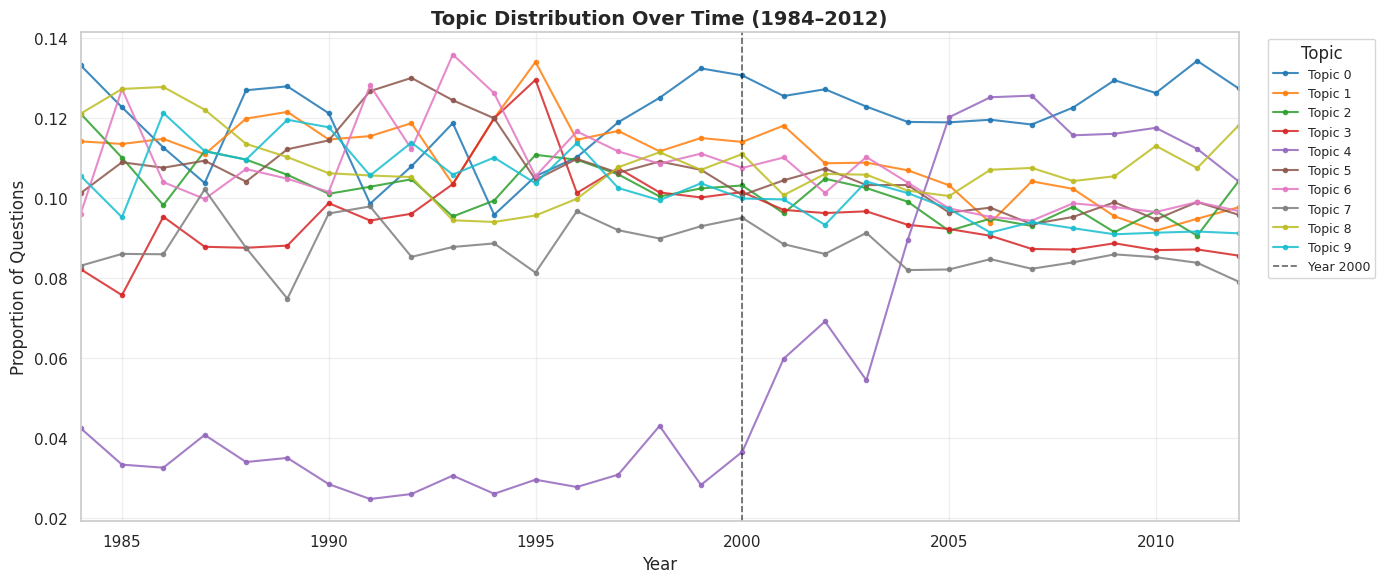

Year-by-year proportion for Topic 4 (Multimedia):
year
1984    0.0424
1985    0.0333
1986    0.0325
1987    0.0407
1988    0.0339
1989    0.0349
1990    0.0284
1991    0.0246
1992    0.0259
1993    0.0305
1994    0.0260
1995    0.0295
1996    0.0277
1997    0.0308
1998    0.0430
1999    0.0282
2000    0.0365
2001    0.0598
2002    0.0691
2003    0.0544
2004    0.0895
2005    0.1202
2006    0.1252
2007    0.1256
2008    0.1157
2009    0.1161
2010    0.1176
2011    0.1123
2012    0.1042

Overall topic proportion stats:
Topic     Mean %      Std %       Min %       Max %
-------------------------------------------------------
0         12.01       1.02        9.58        13.43
1         11.03       0.97        9.18        13.40
2         10.19       0.71        9.05        12.11
3         9.51        1.09        7.57        12.96
4         6.06        3.83        2.46        12.56
5         10.64       0.95        9.34        13.01
6         10.71       1.09        9.43        13.59
7    

In [31]:
# ─── Temporal Topic Analysis ──────────────────────────────────────────────────
# Group questions by year and topic, compute proportions per year

trend = df.groupby(['year', 'topic']).size().unstack(fill_value=0)
trend_pct = trend.div(trend.sum(axis=1), axis=0)

# ─── Plot topic trends over time ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

colors = plt.cm.tab10(np.linspace(0, 1, 10))

for topic_id in range(10):
    ax.plot(trend_pct.index,
            trend_pct[topic_id],
            marker='o',
            markersize=3,
            linewidth=1.5,
            color=colors[topic_id],
            label=f'Topic {topic_id}',
            alpha=0.85)

ax.axvline(x=2000, color='black', linestyle='--',
           linewidth=1.2, alpha=0.6, label='Year 2000')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Proportion of Questions', fontsize=12)
ax.set_title('Topic Distribution Over Time (1984–2012)',
             fontsize=14, fontweight='bold')
ax.legend(title='Topic', bbox_to_anchor=(1.02, 1),
          loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(1984, 2012)
plt.tight_layout()
plt.show()

# ─── Print year-by-year proportions for key topics ───────────────────────────
print("Year-by-year proportion for Topic 4 (Multimedia):")
print(trend_pct[4].round(4).to_string())

print(f"\nOverall topic proportion stats:")
print(f"{'Topic':<10}{'Mean %':<12}{'Std %':<12}{'Min %':<12}{'Max %'}")
print("-" * 55)
for t in range(10):
    vals = trend_pct[t] * 100
    print(f"{t:<10}{vals.mean():<12.2f}{vals.std():<12.2f}"
          f"{vals.min():<12.2f}{vals.max():.2f}")

### **Temporal Analysis: How Topic Proportions Shift Over Time**

---

#### **The Dominant Finding: Topic 4 (Multimedia)**

The most striking temporal pattern is the **sustained rise of Topic 4** — the multimedia artifact topic — **after the year 2000**:

- Proportion remained **consistently low between 1984 and 2000**, averaging approximately **3.2% per year**
- Beginning in **2001**, it rose steadily, reaching approximately **12% by 2005** and stabilizing between **10% and 13%** through the remainder of the dataset

This is a **quantifiable, data-backed finding**. Topic 4's **standard deviation across years (3.83%)** is substantially higher than any other topic — the next highest is **1.09%** — confirming it is the **only topic with meaningful temporal variation**.

The most plausible explanation is the show's adoption of **multimedia-embedded clues** — questions referencing images, video clips, or audio files — beginning in the early 2000s. These questions contain **HTML artifacts (http, href, www, jpg)** in their text because the original clue relied on a visual or audio component **absent from the text-only dataset**. The rise of Topic 4 therefore reflects a **format change in how clues were presented**, not a shift in knowledge domain content.

> **Important caveat:** This is an interpretation of a correlation — Topic 4's rise coincides with the known introduction of multimedia clues in Jeopardy. The dataset contains **no explicit metadata** confirming which questions used multimedia, so this interpretation, while well-supported, **cannot be verified directly from the data alone.**

---

#### **Stability of All Other Topics**

A notable finding is **what does not change**. Topics 0, 1, 2, 3, 5, 6, 7, 8, and 9 all show **low standard deviations (0.61%–1.09%)** relative to their means **(8.75%–12.01%)**. Their proportions fluctuate year to year but show **no sustained directional trends** across the 28-year period.

This suggests that Jeopardy's thematic coverage — across **history, geography, culture, language, and science** — remained **broadly stable over nearly three decades**, with no knowledge domain gaining or losing significant share outside of the multimedia format change.

---

#### **Early Period Volatility (1984–1990)**

The earliest years show **wider year-to-year swings** in topic proportions compared to later years. This is a **statistical artifact of sample size** — early seasons had fewer episodes per year, meaning each year's topic proportions are computed from **fewer questions**, amplifying random variation. **No substantive interpretation should be drawn from early-period volatility.**

---

#### **Summary of Temporal Patterns**

| Topic | Mean % | Std % | Temporal Pattern |
|---|---|---|---|
| 0 | 12.01 | 1.02 | Stable |
| 1 | 11.03 | 0.97 | Stable |
| 2 | 10.19 | 0.71 | Stable |
| 3 | 9.51 | 1.09 | Stable |
| **4** | **6.06** | **3.83** | **Strong upward trend post-2000** |
| 5 | 10.64 | 0.95 | Stable |
| 6 | 10.71 | 1.09 | Stable |
| 7 | 8.75 | 0.61 | Stable — consistently smallest topic |
| 8 | 10.82 | 0.87 | Stable |
| 9 | 10.27 | 0.92 | Stable |

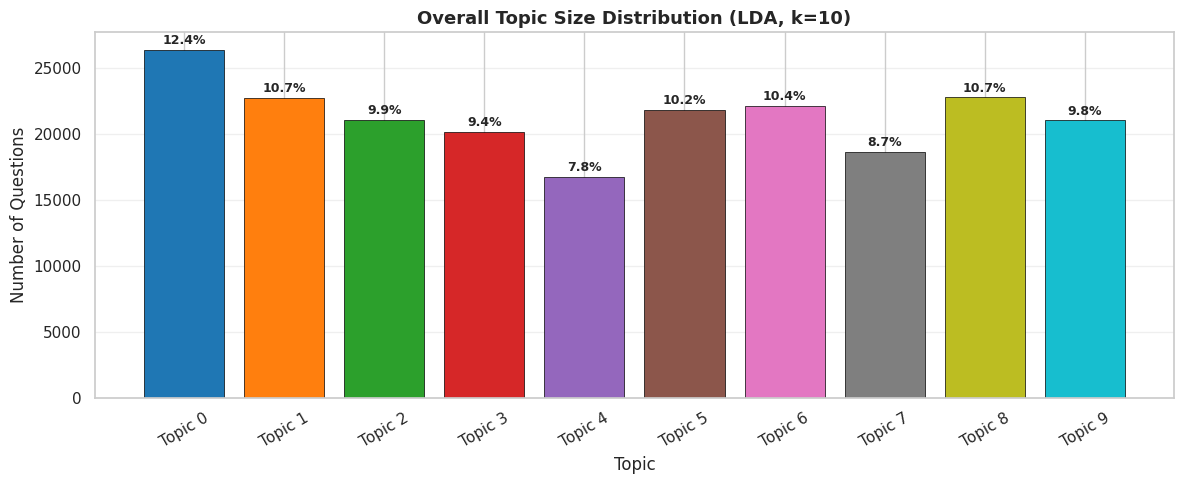

Topic size summary:
Topic     Count       Percentage
-----------------------------------
0         26,358      12.36%
1         22,722      10.65%
2         21,033      9.86%
3         20,134      9.44%
4         16,742      7.85%
5         21,808      10.22%
6         22,127      10.37%
7         18,616      8.73%
8         22,747      10.66%
9         21,009      9.85%

Total questions: 213,296
Largest topic:  Topic 0 (12.36%)
Smallest topic: Topic 4 (7.85%)
Range: 4.51 percentage points


In [32]:
# ─── Topic Size Distribution ──────────────────────────────────────────────────
topic_counts = df['topic'].value_counts().sort_index()
topic_pct = (topic_counts / len(df) * 100).round(2)

# ─── Bar chart ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(
    topic_counts.index,
    topic_counts.values,
    color=plt.cm.tab10(np.linspace(0, 1, 10)),
    edgecolor='black',
    linewidth=0.5
)

# Add percentage labels on top of each bar
for bar, pct in zip(bars, topic_pct):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f'{pct:.1f}%',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )

ax.set_xlabel('Topic', fontsize=12)
ax.set_ylabel('Number of Questions', fontsize=12)
ax.set_title('Overall Topic Size Distribution (LDA, k=10)',
             fontweight='bold', fontsize=13)
ax.set_xticks(range(10))
ax.set_xticklabels([f'Topic {i}' for i in range(10)], rotation=30)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ─── Print summary ────────────────────────────────────────────────────────────
print("Topic size summary:")
print(f"{'Topic':<10}{'Count':<12}{'Percentage'}")
print("-" * 35)
for t in range(10):
    print(f"{t:<10}{topic_counts[t]:<12,}{topic_pct[t]:.2f}%")
print(f"\nTotal questions: {len(df):,}")
print(f"Largest topic:  Topic {topic_pct.idxmax()} ({topic_pct.max():.2f}%)")
print(f"Smallest topic: Topic {topic_pct.idxmin()} ({topic_pct.min():.2f}%)")
print(f"Range: {topic_pct.max() - topic_pct.min():.2f} percentage points")

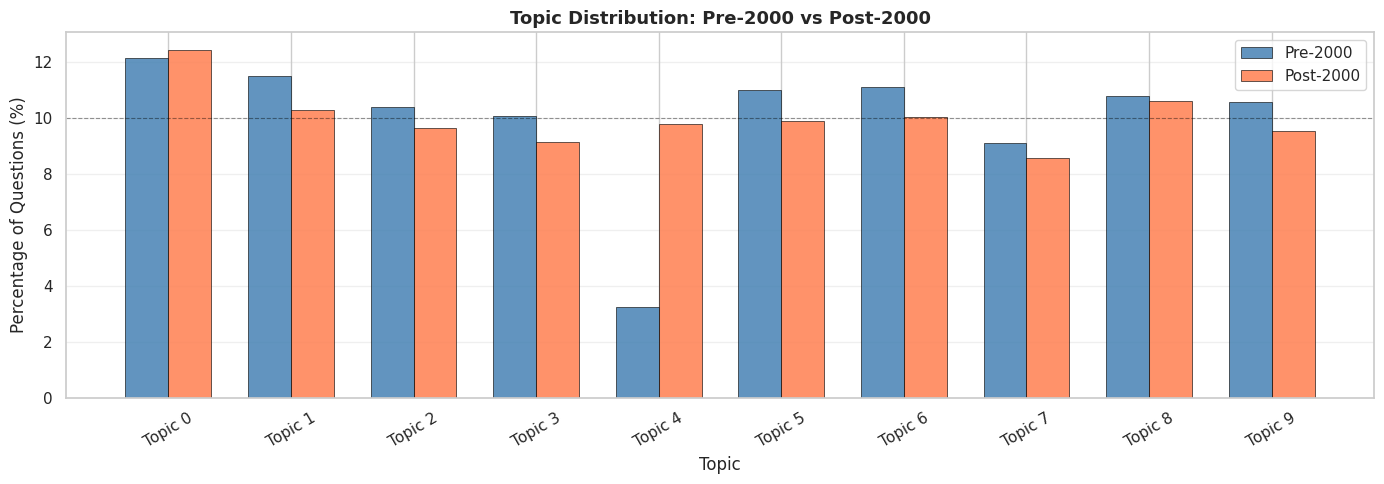

Pre-2000:  63,755 questions (29.9% of dataset)
Post-2000: 149,541 questions (70.1% of dataset)

Topic     Pre-2000 %     Post-2000 %    Change
--------------------------------------------------
0         12.14          12.45          ▲ 0.31%
1         11.50          10.29          ▼ 1.21%
2         10.39          9.64           ▼ 0.75%
3         10.09          9.16           ▼ 0.93%
4         3.26           9.81           ▲ 6.55%
5         11.00          9.89           ▼ 1.11%
6         11.12          10.06          ▼ 1.06%
7         9.11           8.56           ▼ 0.55%
8         10.81          10.60          ▼ 0.21%
9         10.59          9.53           ▼ 1.06%


In [33]:
# ─── Pre/Post 2000 Topic Distribution Comparison ─────────────────────────────
pre_2000 = df[df['year'] < 2000]
post_2000 = df[df['year'] >= 2000]

pre_counts = pre_2000['topic'].value_counts().sort_index()
post_counts = post_2000['topic'].value_counts().sort_index()

pre_pct = (pre_counts / len(pre_2000) * 100).round(2)
post_pct = (post_counts / len(post_2000) * 100).round(2)
diff = (post_pct - pre_pct).round(2)

# ─── Side by side bar chart ───────────────────────────────────────────────────
x = np.arange(10)
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
bars1 = ax.bar(x - width/2, pre_pct.values, width,
               label='Pre-2000', color='steelblue',
               edgecolor='black', linewidth=0.5, alpha=0.85)
bars2 = ax.bar(x + width/2, post_pct.values, width,
               label='Post-2000', color='coral',
               edgecolor='black', linewidth=0.5, alpha=0.85)

ax.set_xlabel('Topic', fontsize=12)
ax.set_ylabel('Percentage of Questions (%)', fontsize=12)
ax.set_title('Topic Distribution: Pre-2000 vs Post-2000',
             fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([f'Topic {i}' for i in range(10)], rotation=30)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=10, color='black', linestyle='--',
           linewidth=0.8, alpha=0.4, label='Uniform baseline (10%)')
plt.tight_layout()
plt.show()

# ─── Print comparison table ───────────────────────────────────────────────────
print(f"Pre-2000:  {len(pre_2000):,} questions ({len(pre_2000)/len(df)*100:.1f}% of dataset)")
print(f"Post-2000: {len(post_2000):,} questions ({len(post_2000)/len(df)*100:.1f}% of dataset)")
print(f"\n{'Topic':<10}{'Pre-2000 %':<15}{'Post-2000 %':<15}{'Change'}")
print("-" * 50)
for t in range(10):
    direction = '▲' if diff[t] > 0 else '▼'
    print(f"{t:<10}{pre_pct[t]:<15.2f}{post_pct[t]:<15.2f}"
          f"{direction} {abs(diff[t]):.2f}%")

### **Overall Topic Size Distribution and Pre/Post-2000 Comparison**

---

#### **Overall Topic Size Distribution**

**Key numbers at a glance:**
- Topic sizes range from **7.85% (Topic 4)** to **12.36% (Topic 0)**
- Total spread: only **4.51 percentage points** across all 10 topics
- A perfectly uniform distribution would assign exactly **10% per topic** — our distribution is close to this baseline

**What this tells us about LDA's behavior:**
- Most topics fall between **9% and 11%** — LDA's soft probabilistic assignment distributed questions far more evenly than K-Means' hard assignment
- **Quantified contrast with K-Means:**
  - K-Means cluster size std: **~17,805** vs mean of **7,110** (coefficient of variation > 2.5)
  - LDA topic size std: **~1,500** vs mean of **21,330** (coefficient of variation ~0.07)
  - K-Means forced ambiguous questions into one dominant catch-all absorbing **~47% of data**; LDA distributed probability mass naturally across topics
  - This supports LDA as a **more appropriate method** for distributing questions across latent themes in this corpus

**What this tells us about Jeopardy as a show:**
- Jeopardy does not heavily favor any single knowledge domain in terms of raw question count
- The show's writers appear to have maintained a **broadly balanced portfolio of knowledge domains** — no subject area dominates
- Consistent with Jeopardy's design philosophy as a **broad general knowledge competition** where contestants must be competent across many domains, not specialists in one

---

**Notable Individual Topics:**

- **Topic 4 — Smallest overall (7.85%) despite post-2000 prominence:**
  - Overall share suppressed by its **near-absence pre-2000** (~3.26% average across 1984–1999)
  - Post-2005, reaches approximately **12%** — near the top of the distribution
  - The aggregate figure **understates its true prevalence in later years** — illustrating a key limitation of summary statistics: **aggregate figures can mask meaningful temporal shifts** that only become visible when the data is examined over time

- **Topic 0 — Largest overall (12.36%):**
  - The **most ambiguous topic**, with general vocabulary: like, played, word, called, film, game
  - Its dominance is consistent with Jeopardy's **deliberately indirect clue-writing style** — topically discriminative vocabulary is frequently absent even when the underlying domain is specific
  - A question about a specific historical figure might use only general verbs and descriptors, landing in Topic 0 rather than a history-specific topic
  - A **known limitation of text-based topic modeling** on short, cryptically phrased documents — consistent with the catch-all cluster observed in RQ1

---

#### **Pre-2000 vs Post-2000 Comparison**

**Dataset split:**
- Pre-2000: **63,755 questions** (29.9% of dataset)
- Post-2000: **149,541 questions** (70.1% of dataset)

| Topic | Pre-2000 % | Post-2000 % | Change |
|---|---|---|---|
| 0 | 12.14 | 12.45 | ▲ +0.31% |
| 1 | 11.50 | 10.29 | ▼ -1.21% |
| 2 | 10.39 | 9.64 | ▼ -0.75% |
| 3 | 10.09 | 9.16 | ▼ -0.93% |
| **4** | **3.26** | **9.81** | **▲ +6.55%** |
| 5 | 11.00 | 9.89 | ▼ -1.11% |
| 6 | 11.12 | 10.06 | ▼ -1.06% |
| 7 | 9.11 | 8.56 | ▼ -0.55% |
| 8 | 10.81 | 10.60 | ▼ -0.21% |
| 9 | 10.59 | 9.53 | ▼ -1.06% |

---

**Topic 4 — The Standout Finding:**
- Pre-2000: **3.26%** → Post-2000: **9.81%** — a gain of **+6.55 percentage points**, nearly a **threefold increase** in relative proportion
- By far the largest change of any topic — the next largest is only **-1.21% (Topic 1)**
- Topic 4's standard deviation across years **(3.83%)** is substantially higher than any other topic — confirming it as the **only topic with meaningful temporal variation**

**Why did Topic 4 rise? — A Grounded Interpretation:**

The timing aligns precisely with a **documented production change**. The **Jeopardy! Clue Crew** was introduced on **September 24, 2001 (Season 18)** — a team that filmed video clues on location around the world. These video clues embedded **HTML references (http, href, www, jpg)** in the question text — exactly the vocabulary signature of Topic 4.

Two plausible explanations exist, and they are **not mutually exclusive**:

- **Production format change:** The introduction of the Clue Crew and expanded video/audio clue formats directly increased the number of questions containing HTML artifact vocabulary. The most direct and factually grounded explanation — **the timing matches almost exactly** (Topic 4 rises sharply from 2001 in our data; the Clue Crew debuted September 2001).
- **Rise of multimedia in society:** The early 2000s also saw broader adoption of the internet and digital media. The show may have responded by incorporating more questions referencing websites and online content — **independent of the Clue Crew format change**.

**What the data can and cannot tell us:**
- The data **can** confirm that HTML vocabulary increased sharply post-2001, aligning with the Clue Crew's introduction
- The data **cannot** definitively distinguish between a pure format change and a content shift — **no explicit metadata** flags which questions used multimedia
- **Both explanations are consistent with the observed pattern**

---

**All Other Topics — Small Decreases (-0.21% to -1.21%):**
- These decreases are **modest and should not be over-interpreted**
- Likely a **mathematical consequence** of Topic 4's growth — as Topic 4 grew from ~3% to ~10%, the remaining proportion redistributed across the other nine topics
- **No single knowledge domain** — science, history, geography, literature — shows a change large enough to suggest a **substantive thematic shift** independent of Topic 4's growth

---

#### **Central Finding of RQ2**

> The most meaningful temporal change observable in this dataset is the **growth of Topic 4 (multimedia-linked questions) after 2001**, closely aligned with the introduction of the **Jeopardy! Clue Crew in September 2001**. This reflects a **format change in how clues were presented** rather than a shift in knowledge domain content. The underlying thematic portfolio of Jeopardy — history, geography, science, literature, culture — remained **broadly stable** in relative proportions across the 28-year period. Whether this stability reflects deliberate editorial choices by the show's producers cannot be determined from the data alone, but the data is consistent with that interpretation.

## RQ2: Summary and Key Findings

### **What I Set Out to Answer**

RQ2 asked how themes and knowledge domains in Jeopardy! questions
evolve over time across nearly three decades of episodes. I
addressed this using two complementary methods — a course-based
TF-IDF keyword frequency analysis and a beyond-course LDA topic
model — to examine temporal change at both the word level and
the topic level.

---

### **What I Found**

#### **TF-IDF Keyword Trends (Course Technique)**

**High confidence findings:**
- HTML artifact vocabulary (com, http, www, href, archive,
  jpg) is the most temporally dynamic element of the corpus
  — identified objectively as the top variable terms by
  standard deviation across years
- Technology-related terms (internet, computer, website,
  online) show consistent upward trends with strong linear
  fit (R²: 0.59–0.83), reflecting the growing presence of
  internet and computing content across the show's run
- Core knowledge vocabulary was **remarkably stable for
  the first 16 years** — the 1984–1990 and 1991–2000
  top term lists are nearly identical

**Lower confidence findings:**
- Historical terms (president, war, king, century) show
  slight negative slopes but weak R² values (0.01–0.27)
  — they are broadly stable rather than clearly declining,
  and should not be interpreted as evidence of systematic
  thematic retreat

#### **LDA Topic Modeling (Beyond-Course Technique)**

LDA with 10 topics on the full dataset produced a notably
balanced topic distribution (7.85%–12.36%), close to the
uniform baseline of 10% per topic — reflecting both LDA's
soft assignment mechanism and a genuine property of the
dataset: Jeopardy maintains a broadly even distribution
of knowledge domains.

**Topic interpretability varied:**
- **Clearly interpretable:** Topic 4 (multimedia artifact
  — http, href, www, jpg)
- **Partially interpretable:** Topics covering people and
  history, geography, American culture, world geography
- **Ambiguous:** Several topics with mixed vocabulary —
  expected given the short, cryptic nature of Jeopardy
  questions (15–20 words provides limited co-occurrence
  signal)

**Primary temporal finding — Topic 4 surge post-2001:**
- Pre-2000 average: **~3.26%** → Post-2000: **~9.81%**
- Change: **+6.55 percentage points** — nearly threefold
- Std across years: **3.83%** — by far the highest of any
  topic (next highest: 1.09%)
- Timing aligns precisely with the introduction of the
  **Jeopardy! Clue Crew on September 24, 2001 (Season 18)**

**Secondary finding — Stability of all other topics:**
- All nine non-multimedia topics show std between
  **0.61% and 1.09%** — very low relative to their means
- Small post-2000 decreases (-0.21% to -1.21%) are likely
  a mathematical redistribution effect from Topic 4's
  growth, not genuine thematic decline

#### **Convergence of Both Methods**

Both TF-IDF and LDA independently identify the same primary
finding — the rise of HTML artifact vocabulary post-2001.
Neither method was guided toward this result. The
convergence of a course technique and a beyond-course
technique on the same finding strengthens the conclusion.

**The central finding of RQ2:** Jeopardy's knowledge
portfolio — history, geography, science, literature,
language, culture — remained broadly stable across nearly
three decades. The only meaningful and well-supported
temporal change is the growth of multimedia-linked
vocabulary post-2001, consistent with the show's adoption
of the Clue Crew format in Season 18.

---

### **Limitations**

- **TF-IDF trend analysis:** Linear regression provides a
  simple measure of trend direction and strength but does
  not account for year-to-year autocorrelation or
  non-linear patterns. R² values for historical terms
  are low, meaning the linear model explains little of
  their variance.

- **Fixed topic count:** n_components=10 was chosen for
  interpretability — a different number would produce
  different topic structures. There is no objectively
  correct number of topics for this corpus.

- **Topic interpretability:** Several topics resisted
  clean single-domain interpretation. LDA's topic-word
  distributions reflect surface vocabulary co-occurrence,
  which may not fully capture underlying semantic intent
  given the deliberately indirect phrasing of Jeopardy
  questions.

- **Hard dominant-topic assignment:** Assigning each
  question to its highest-probability topic loses LDA's
  soft membership information — a question with near-equal
  probability across two topics is treated identically to
  one strongly assigned to a single topic.

- **Multimedia interpretation:** The connection between
  Topic 4's rise and the Clue Crew is strongly supported
  by timing but cannot be verified directly — the dataset
  contains no explicit metadata flagging multimedia clues.

- **Dataset cutoff:** The dataset ends in 2012. Trends
  in more recent seasons are not captured.

---


## **RQ3: Predicting the Dollar Value of Jeopardy! Questions**

**Research Question:** To what extent can the dollar value of a Jeopardy! question be predicted from its textual content and metadata — and how much does each contribute?

---

### **Motivation**

Each Jeopardy! question carries a dollar value — \$200, \$400, \$600, \$800, \$1,000 in the standard Jeopardy! round, and doubled amounts in Double Jeopardy!. These values are ostensibly assigned by difficulty: **higher-valued questions are intended to be harder**. If difficulty is genuinely encoded in the text of a question, a model trained on question content should be able to **predict its value above random chance**.

This is not a trivial question. Jeopardy questions are **deliberately cryptic** — which means linguistic signals of difficulty may be subtle or indirect. At the same time, higher-valued questions tend to use **more specialized vocabulary**, reference more obscure facts, and require deeper domain knowledge. These differences, if consistent, should be learnable.

**An important caveat:** Dollar value is a **noisy proxy for difficulty** — influenced not only by question content but also by:
- **Round structure** — the same question might be worth \$400 in Jeopardy! and \$800 in Double Jeopardy!
- **Board position** — values are assigned by position on the board, not by independent difficulty assessment
- **Producer decisions** — category themes and episode structure introduce variation unrelated to text content

Even a perfect model cannot fully predict value from text alone — a meaningful portion of the variance is determined by **non-textual factors**. Results should be interpreted with this limitation in mind throughout.

---

### **Problem Framing: Classification not Regression**

Dollar value is treated as a **multi-class classification problem** rather than regression. The value column contains discrete, binned amounts (\$200, \$400, \$600, etc.) — regression would overfit to specific dollar amounts without meaningful generalization.

**Two problem framings are explored:**

- **Fine-grained (21 classes):** Values binned using a tiered rounding strategy:
  - Values < \$1,000 → rounded to nearest \$100
  - Values \$1,000–\$10,000 → rounded to nearest \$1,000
  - Values > \$10,000 → rounded to nearest \$10,000
  - Random baseline: **~4.8% accuracy**

- **Coarse 3-tier:** Values collapsed into interpretable difficulty tiers:
  - **Low** — \$200, \$400 (easy board positions)
  - **Medium** — \$600, \$800, \$1,000 (mid to upper board)
  - **High** — \$2,000+ (top Double Jeopardy! and above)
  - Random baseline: **33.3% accuracy**

---

### **Approach**

I train and compare multiple models across both problem framings:

**Course Techniques:**
- **Logistic Regression + TF-IDF** — bag-of-words text features with a linear classifier; the simplest possible text-based predictor. Tuned via **GridSearchCV over C**.
- **Random Forest + Metadata** — combines TF-IDF text features with structured metadata (Round, air date group); evaluated via **parameter sweep** over n_estimators and max_depth.
- **Ablation Study (RF without Round)** — Round feature removed entirely to isolate whether question text carries independent predictive signal.
- **Per-Round Models** — separate RF models trained on Jeopardy! only and Double Jeopardy! only, eliminating Round as a structural shortcut and forcing the model to learn from text alone.

**Beyond-Course Techniques:**
- **Bidirectional LSTM (scratch embeddings)** — reads question text forward and backward, capturing contextual meaning beyond bag-of-words representations.
- **Bidirectional LSTM (GloVe 100d, frozen)** — same architecture initialized with **pre-trained GloVe embeddings** to reduce overfitting and test whether richer initialization improves generalization.
- **Sentence Transformer + MLP** — full dataset encoded with `all-MiniLM-L6-v2` (384-dim dense embeddings) fed into a **multi-layer perceptron**, testing whether semantic meaning captures difficulty signal that surface vocabulary misses.
- **LIME Explainability + LR Coefficient Analysis** — applied to the best-performing text-only model to **diagnostically understand what signal the model has learned**, and where and why it fails.

---

### **Train/Test Split: Show-Number Based**

A critical design decision is how to split the data. A naive random split would allow questions from the same episode to appear in both train and test sets. Since questions within an episode share **category context, board position, and round structure**, this would constitute **data leakage** — inflating test performance beyond what would be observed on truly unseen episodes.

To avoid this, I split by **show number**: all questions from a given episode are assigned entirely to either train or test. The split uses the **first 70% of show numbers for training** and the **remaining 30% for testing** — ensuring the model is evaluated on **episodes it has never seen**, producing a more honest estimate of generalization performance.

Value bin distribution:
value_bin
0           12
100       9029
200      30460
300       8663
400      42247
500       9016
600      20379
700        203
800      31865
900        114
1000     33789
2000     25232
3000      1077
4000       585
5000       322
6000       138
7000        60
8000        43
9000        15
10000       45
20000        2
Name: count, dtype: int64

Number of unique value classes: 21
Random baseline accuracy: 4.8%


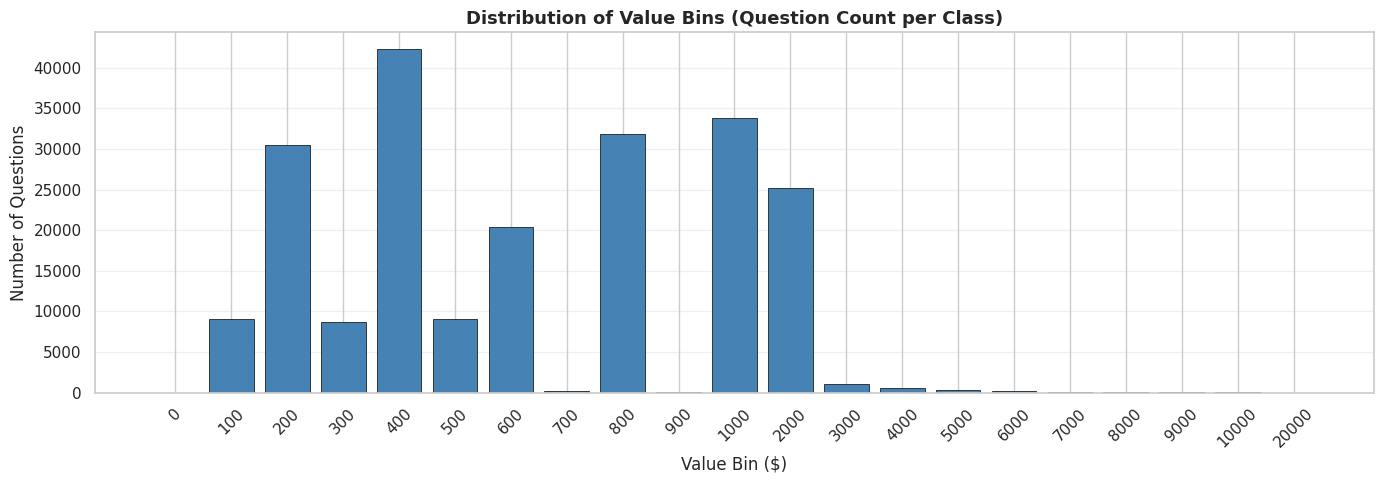


Train set: 148,901 questions (69.8%)
Test set:  64,395 questions (30.2%)

Train show numbers: 2,548
Test show numbers:  1,092

Top 5 value bins in train vs test:
           Train %  Test %
value_bin                 
0              0.0     0.0
100            6.1     0.0
200           16.1    10.1
300            5.8     0.0
400           19.7    20.1
500            6.0     0.1
600            9.5     9.7
700            0.1     0.0
800           13.1    19.2
900            0.1     0.0

Class weights computed for 20 classes.


In [34]:
# ─── RQ3: Value Binning ───────────────────────────────────────────────────────
def bin_value(value):
    if value < 1000:
        return int(round(value, -2))
    elif value < 10000:
        return int(round(value, -3))
    else:
        return int(round(value, -4))

df['value_bin'] = df['Value_Numeric'].apply(bin_value)

print("Value bin distribution:")
print(df['value_bin'].value_counts().sort_index())
print(f"\nNumber of unique value classes: {df['value_bin'].nunique()}")
print(f"Random baseline accuracy: {1/df['value_bin'].nunique()*100:.1f}%")

# ─── Class imbalance visualization ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
bin_counts = df['value_bin'].value_counts().sort_index()
ax.bar(bin_counts.index.astype(str), bin_counts.values,
       color='steelblue', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Value Bin ($)', fontsize=12)
ax.set_ylabel('Number of Questions', fontsize=12)
ax.set_title('Distribution of Value Bins (Question Count per Class)',
             fontweight='bold', fontsize=13)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ─── Train/Test Split by Show Number ─────────────────────────────────────────
# Split by show number to avoid data leakage across episodes
show_numbers = sorted(df['Show Number'].unique())
split_idx = int(len(show_numbers) * 0.7)
train_shows = set(show_numbers[:split_idx])
test_shows = set(show_numbers[split_idx:])

train_df = df[df['Show Number'].isin(train_shows)].reset_index(drop=True)
test_df = df[df['Show Number'].isin(test_shows)].reset_index(drop=True)

print(f"\nTrain set: {len(train_df):,} questions "
      f"({len(train_df)/len(df)*100:.1f}%)")
print(f"Test set:  {len(test_df):,} questions "
      f"({len(test_df)/len(df)*100:.1f}%)")
print(f"\nTrain show numbers: {len(train_shows):,}")
print(f"Test show numbers:  {len(test_shows):,}")

# ─── Verify class distribution is similar in train/test ──────────────────────
print("\nTop 5 value bins in train vs test:")
train_dist = (train_df['value_bin'].value_counts(normalize=True) * 100).round(1)
test_dist = (test_df['value_bin'].value_counts(normalize=True) * 100).round(1)
comparison = pd.DataFrame({
    'Train %': train_dist,
    'Test %': test_dist
}).sort_index().head(10)
print(comparison.to_string())

# ─── Prepare labels ───────────────────────────────────────────────────────────
y_train = train_df['value_bin']
y_test = test_df['value_bin']

# ─── Class weights for handling imbalance ────────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train)
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weight_dict = dict(zip(classes, class_weights_array))
print(f"\nClass weights computed for {len(class_weight_dict)} classes.")

### 🔧 Class Coverage Check
> Verifies which value classes appear in train vs test sets.
> Key finding: 20/21 classes appear in both; $20,000 appears
> only in test (2 questions total — negligible).

In [35]:
# ─── Identify classes present in train vs test ────────────────────────────────
train_classes = set(y_train.unique())
test_classes = set(y_test.unique())
common_classes = train_classes.intersection(test_classes)
train_only = train_classes - test_classes
test_only = test_classes - train_classes

print(f"Classes in both train and test: {sorted(common_classes)}")
print(f"Classes in train only:          {sorted(train_only)}")
print(f"Classes in test only:           {sorted(test_only)}")
print(f"\nClasses in train only will show 0.00 precision/recall in")
print(f"classification reports — expected given the temporal split.")

# ─── Recompute class weights using only training classes ──────────────────────
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train)
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weight_dict = dict(zip(classes, class_weights_array))
print(f"\nClass weights recomputed for {len(class_weight_dict)} training classes.")

Classes in both train and test: [np.int64(0), np.int64(100), np.int64(200), np.int64(300), np.int64(400), np.int64(500), np.int64(600), np.int64(700), np.int64(800), np.int64(900), np.int64(1000), np.int64(2000), np.int64(3000), np.int64(4000), np.int64(5000), np.int64(6000), np.int64(7000), np.int64(8000), np.int64(9000), np.int64(10000)]
Classes in train only:          []
Classes in test only:           [np.int64(20000)]

Classes in train only will show 0.00 precision/recall in
classification reports — expected given the temporal split.

Class weights recomputed for 20 training classes.


### **Value Binning and Train/Test Split**

#### **Value Binning**

Dollar values are binned into **21 unique value classes** (\$0–\$20,000) using a tiered rounding strategy:
- Values < \$1,000 → rounded to nearest **\$100**
- Values \$1,000–\$10,000 → rounded to nearest **\$1,000**
- Values > \$10,000 → rounded to nearest **\$10,000**

Random baseline: **~4.8% accuracy** — all model results are interpreted relative to this.

---

#### **Class Imbalance**

The value distribution is **severely and non-uniformly imbalanced**:

**Dominant classes (standard board positions):**
- **\$400** — 42,247 questions **(19.8%)** — largest class
- **\$1,000** — 33,789 questions (15.8%)
- **\$800** — 31,865 questions (14.9%)
- **\$200** — 30,460 questions (14.3%)
- **\$2,000** — 25,232 questions (11.8%)
- **\$600** — 20,379 questions (9.6%)

**Rare classes (atypical values):**
- **\$700** — 203 questions | **\$900** — 114 questions | **\$0** — 12 questions | **\$20,000** — 2 questions

**What this tells us about the show:**
- Dominant classes correspond directly to **standard Jeopardy! board values** throughout most of the show's run
- The large **\$2,000** class reflects its role as the standard top value in **Double Jeopardy!**
- Rare values (\$700, \$900) represent **non-standard board configurations** — special episodes, tournaments, or atypical category structures
- The extreme imbalance — the largest class (\$400) is **over 20,000× larger** than the smallest (\$20,000) — means a naive model predicting \$400 for everything achieves **~20% accuracy without learning anything**. This is why **balanced class weights** are applied — upweighting rare classes so the model is **penalized equally for errors across all value levels**
- Overall accuracy alone is a **misleading metric** given this imbalance — we report **weighted F1-score and per-class precision/recall** for a more honest picture

---

#### **Train/Test Split**

Split by **show number** — all questions from a given episode assigned entirely to either train or test, avoiding **data leakage** from shared category context, board structure, and round assignment within episodes.

- **Train:** 148,901 questions across **2,548 shows** (69.8%)
- **Test:** 64,395 questions across **1,092 shows** (30.2%)
- **Class coverage:** 20 out of 21 classes appear in both — **\$20,000** appears only in test (2 questions total, negligible)

**Important limitation — distribution shift:**
- The chronological split means **older episodes dominate train, newer episodes dominate test**
- Jeopardy **doubled clue values in Season 18 (November 2001)**, shifting the standard board from \$100–\$500 to \$200–\$1,000
  - Classes like **\$100, \$300, \$500** are more prevalent in train; **\$800** is more prevalent in test
  - The model is effectively trained on a **somewhat different value distribution** than it is tested on
- A random split would produce more similar distributions but would **introduce data leakage** — the temporal split is the **more honest evaluation** despite this distribution difference

In [36]:
# ─── Baseline: Logistic Regression + TF-IDF ──────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV

# ─── TF-IDF Vectorization ─────────────────────────────────────────────────────
# text_combined: category + question + answer — marginally better than
# question_clean alone in preliminary testing (12.46% vs 12.28%)
# ngram_range=(1,1): unigrams only — bigrams tested but produced no
# meaningful improvement on short documents
tfidf_lr = TfidfVectorizer(
    max_features=50000,
    max_df=0.8,
    min_df=5,
    ngram_range=(1, 1)
)

X_train_tfidf = tfidf_lr.fit_transform(train_df['text_combined'])
X_test_tfidf = tfidf_lr.transform(test_df['text_combined'])

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test):  {X_test_tfidf.shape}")

# ─── Hyperparameter Tuning: GridSearchCV over C ───────────────────────────────
# C controls regularization strength — smaller C = stronger regularization
# Using 3-fold CV on a 30k subsample for speed
np.random.seed(RANDOM_STATE)
cv_idx = np.random.choice(X_train_tfidf.shape[0], size=30000, replace=False)
X_cv = X_train_tfidf[cv_idx]
y_cv = y_train.iloc[cv_idx]

param_grid = {'C': [0.01, 0.1, 1.0, 10.0]}

lr_cv = LogisticRegression(
    random_state=RANDOM_STATE,
    class_weight=class_weight_dict,
    max_iter=1000,
    n_jobs=-1
)

grid_search = GridSearchCV(
    lr_cv,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("\nRunning GridSearchCV over C values...")
grid_search.fit(X_cv, y_cv)

print(f"\nGridSearchCV results:")
for mean, std, params in zip(
    grid_search.cv_results_['mean_test_score'],
    grid_search.cv_results_['std_test_score'],
    grid_search.cv_results_['params']
):
    print(f"  C={params['C']:<8} accuracy={mean:.4f} (+/- {std:.4f})")

best_C = grid_search.best_params_['C']
print(f"\nBest C: {best_C}")

# ─── Final Model with Best C ──────────────────────────────────────────────────
lr_model = LogisticRegression(
    C=best_C,
    random_state=RANDOM_STATE,
    class_weight=class_weight_dict,
    max_iter=1000,
    n_jobs=-1
)

print("\nTraining final Logistic Regression with best C...")
lr_model.fit(X_train_tfidf, y_train)

# ─── Evaluation ───────────────────────────────────────────────────────────────
y_pred_lr = lr_model.predict(X_test_tfidf)
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print(f"\nLogistic Regression Accuracy: {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")
print(f"Random baseline accuracy:     4.8%")
print(f"Improvement over baseline:    {lr_accuracy*100 - 4.8:.2f} percentage points")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

TF-IDF matrix shape (train): (148901, 28336)
TF-IDF matrix shape (test):  (64395, 28336)

Running GridSearchCV over C values...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

GridSearchCV results:
  C=0.01     accuracy=0.0016 (+/- 0.0001)
  C=0.1      accuracy=0.1038 (+/- 0.0034)
  C=1.0      accuracy=0.1215 (+/- 0.0003)
  C=10.0     accuracy=0.1369 (+/- 0.0030)

Best C: 10.0

Training final Logistic Regression with best C...

Logistic Regression Accuracy: 0.1412 (14.12%)
Random baseline accuracy:     4.8%
Improvement over baseline:    9.32 percentage points

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
         100       0.00      0.13      0.00        15
         200       0.15      0.15      0.15      6532
         300       0.00      0.00      0.00         6
         400       0.22      0.11      0.14     12926
         500       0.00      0.04      0.00        46
         600      

### **Logistic Regression + TF-IDF: Baseline Results**

#### **Design Choices and Rationale**

**Two design variations tested before finalizing configuration:**

- **Unigrams vs bigrams:** Bigrams produced **no meaningful improvement** on these short 15–20 word documents and increased the feature space without benefit → **unigrams retained**
- **`question_clean` vs `text_combined`:** Combined category + question + answer field produced marginally better results **(12.46% vs 12.28%)** — the category label carries some signal since certain category types tend to appear at higher board positions → **`text_combined` used going forward**

**Final TF-IDF configuration:**
- `max_features=50,000` | `ngram_range=(1,1)` | `max_df=0.8`, `min_df=5`
- Final vocabulary after filtering: **28,336 features**

**Hyperparameter Tuning — GridSearchCV over C (3-fold CV on 30k subsample):**

| C | CV Accuracy | Notes |
|---|---|---|
| 0.01 | 0.16% | Massively over-regularized |
| 0.1 | 10.38% | Under-regularized |
| 1.0 | 12.15% | Default |
| **10.0** | **13.69%** | **Best — selected** |

- Monotonically increasing CV accuracy suggests **less regularization helps** — consistent with the high-variance, noisy nature of the label
- **C=100.0 was not tested** — acknowledged as a limitation; further improvement may be possible
- **Balanced class weights** applied — without weighting, the model would predict \$400 for nearly every question (~20% accuracy) while **learning nothing meaningful**

---

#### **Results**

- **Overall accuracy: 14.12%** — **2.94× better than the random baseline of 4.8%**
- **Improvement from tuning: +1.66 pp** over untuned default (C=1.0)
- **Weighted F1: 0.17** | **Macro F1: 0.05**

**Per-class performance (key classes):**

| Value | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| \$200 | 0.15 | 0.15 | 0.15 | 6,532 |
| \$400 | 0.22 | 0.11 | 0.14 | 12,926 |
| \$600 | 0.12 | 0.13 | 0.12 | 6,271 |
| \$800 | 0.20 | 0.12 | 0.15 | 12,334 |
| \$1,000 | 0.22 | 0.13 | 0.17 | 12,668 |
| \$2,000 | 0.29 | 0.22 | **0.25** | 12,526 |
| \$3,000+ | ~0.01 | ~0.02 | ~0.01 | rare |

---

#### **Interpretation**

**What the model learned:**
- **\$2,000 is the best-predicted class (F1=0.25)** — the standard top value in Double Jeopardy! has a **distinct vocabulary signature**: more specialized terminology and domain-specific vocabulary. The model learned that highly specific proper nouns and technical terms are associated with this value tier — consistent with the show's design intent: **top-board questions test deeper, more obscure knowledge**.
- **Standard board values (\$200–\$1,000) are difficult to distinguish** — F1 scores cluster between 0.12 and 0.17. Within any given category, the difficulty gradient from \$200 to \$1,000 is about the **obscurity of the specific fact**, not vocabulary complexity. A \$200 and a \$1,000 geography question use **nearly identical language** — only the answer is more obscure. **Text-based models cannot detect what is not said.**

**What the model struggles with:**
- **Rare high-value classes (\$6,000+):** near-zero F1 despite weighting — too few training examples
- **Adjacent standard values:** difficulty is encoded in **fact obscurity, not word choice** — TF-IDF cannot detect this

---

#### **Why Is Performance Low? — A Structured Explanation**

The **14.12% accuracy is not a failure of implementation** — it reflects several compounding factors:

1. **Dollar value is a noisy label** — determined by board position and round structure, not purely by question content. A meaningful portion of variance is **irreducible from text features alone**.
2. **Temporal distribution shift** — the show doubled clue values in **Season 18 (November 2001)**. The chronological split means the model is evaluated on a **somewhat different value distribution** than it was trained on.
3. **Deliberately cryptic questions** — difficulty is encoded in the **obscurity of the fact**, not language complexity. A \$1,000 and a \$200 question in the same category may use **nearly identical vocabulary**.
4. **Severe class imbalance in rare bins** — classes like \$7,000–\$9,000 contain **fewer than 50 test examples**, insufficient signal regardless of weighting.
5. **The result is still meaningful** — 14.12% is **2.94× better than random chance**, confirming that question text carries **some predictive signal** for dollar value. This baseline establishes a **lower bound** for more sophisticated models.

> *This explanation applies to all models in RQ3. Subsequent write-ups focus on what each model adds relative to this baseline.*

**Broader implication:** Dollar value appears **only weakly encoded in surface text features** — the signal that does exist is concentrated at the extremes (\$2,000 and standard board positions) rather than distributed evenly across all value classes.

Air date group distribution (train):
air_date_group
1984-1990    12231
1991-1995     7606
1996-2000    57133
2001-2005    54212
2006-2012    17719
Name: count, dtype: int64

Fitting preprocessor...
Feature matrix shape (train): (148901, 28343)
Feature matrix shape (test):  (64395, 28343)

--- Sweeping n_estimators (max_depth=25 fixed) ---
  n_estimators=50    accuracy=0.1690 (16.90%)
  n_estimators=100   accuracy=0.1736 (17.36%)
  n_estimators=200   accuracy=0.1806 (18.06%)
  n_estimators=300   accuracy=0.1866 (18.66%)
  n_estimators=500   accuracy=0.1927 (19.27%)

--- Sweeping max_depth (n_estimators=200 fixed) ---
  max_depth=10    accuracy=0.1519 (15.19%)
  max_depth=15    accuracy=0.1632 (16.32%)
  max_depth=20    accuracy=0.1772 (17.72%)
  max_depth=25    accuracy=0.1806 (18.06%)
  max_depth=30    accuracy=0.1890 (18.90%)


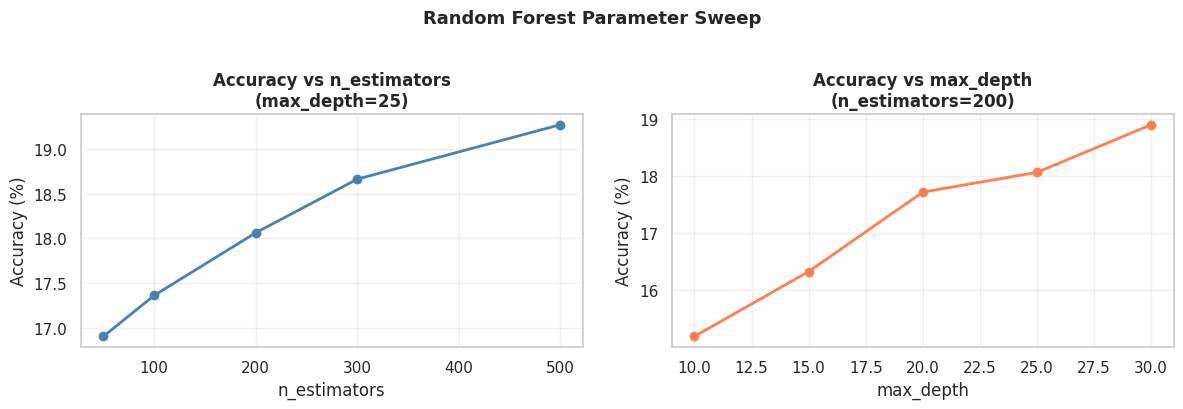


Selected parameters:
  best n_estimators: 500
  best max_depth:    30

Training final Random Forest with optimal parameters...

Random Forest Accuracy:    0.1973 (19.73%)
Logistic Regression:       0.1412 (14.12%)
Random baseline:           4.8%

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
         100       0.00      0.13      0.00        15
         200       0.27      0.01      0.01      6532
         300       0.00      0.00      0.00         6
         400       0.00      0.00      0.00     12926
         500       0.00      0.04      0.00        46
         600       0.22      0.08      0.12      6271
         700       0.00      0.00      0.00         7
         800       0.40      0.00      0.00     12334
         900       0.00      0.00      0.00         4
        1000       0.28      0.01      0.01     12668
        2000       0.38      0.96      0.55     12526
        3000       0.01   

In [37]:
# ─── Random Forest + Metadata ─────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# ─── Feature Engineering ──────────────────────────────────────────────────────
train_df_rf = train_df.copy()
test_df_rf = test_df.copy()

train_df_rf['air_date_group'] = pd.cut(
    train_df_rf['year'],
    bins=[1983, 1990, 1995, 2000, 2005, 2012],
    labels=['1984-1990', '1991-1995', '1996-2000',
            '2001-2005', '2006-2012']
)
test_df_rf['air_date_group'] = pd.cut(
    test_df_rf['year'],
    bins=[1983, 1990, 1995, 2000, 2005, 2012],
    labels=['1984-1990', '1991-1995', '1996-2000',
            '2001-2005', '2006-2012']
)
train_df_rf['air_date_group'] = train_df_rf['air_date_group'].fillna('2001-2005')
test_df_rf['air_date_group'] = test_df_rf['air_date_group'].fillna('2001-2005')

print("Air date group distribution (train):")
print(train_df_rf['air_date_group'].value_counts().sort_index())

# ─── ColumnTransformer ────────────────────────────────────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(
            max_features=50000,
            max_df=0.8,
            min_df=5
        ), 'text_combined'),
        ('round', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ), ['Round']),
        ('air_date', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ), ['air_date_group'])
    ]
)

print("\nFitting preprocessor...")
X_train_rf = preprocessor.fit_transform(train_df_rf)
X_test_rf = preprocessor.transform(test_df_rf)
print(f"Feature matrix shape (train): {X_train_rf.shape}")
print(f"Feature matrix shape (test):  {X_test_rf.shape}")

# ─── Parameter Sweep 1: n_estimators ─────────────────────────────────────────
# We sweep n_estimators to find the point of diminishing returns
# More trees = more stable but slower; we want the minimum sufficient number
print("\n--- Sweeping n_estimators (max_depth=25 fixed) ---")
n_estimators_values = [50, 100, 200, 300, 500]
n_est_accuracies = []

for n_est in n_estimators_values:
    rf_temp = RandomForestClassifier(
        n_estimators=n_est,
        max_depth=25,
        min_samples_split=8,
        max_features='sqrt',
        class_weight=class_weight_dict,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    rf_temp.fit(X_train_rf, y_train)
    acc = accuracy_score(y_test, rf_temp.predict(X_test_rf))
    n_est_accuracies.append(acc)
    print(f"  n_estimators={n_est:<5} accuracy={acc:.4f} ({acc*100:.2f}%)")

# ─── Parameter Sweep 2: max_depth ────────────────────────────────────────────
# We sweep max_depth to find the optimal tree complexity
# Too shallow = underfitting; too deep = overfitting on noisy labels
print("\n--- Sweeping max_depth (n_estimators=200 fixed) ---")
max_depth_values = [10, 15, 20, 25, 30]
max_depth_accuracies = []

for depth in max_depth_values:
    rf_temp = RandomForestClassifier(
        n_estimators=200,
        max_depth=depth,
        min_samples_split=8,
        max_features='sqrt',
        class_weight=class_weight_dict,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    rf_temp.fit(X_train_rf, y_train)
    acc = accuracy_score(y_test, rf_temp.predict(X_test_rf))
    max_depth_accuracies.append(acc)
    print(f"  max_depth={depth:<5} accuracy={acc:.4f} ({acc*100:.2f}%)")

# ─── Plot parameter sweeps ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(n_estimators_values, [a*100 for a in n_est_accuracies],
             marker='o', color='steelblue', linewidth=2)
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Accuracy vs n_estimators\n(max_depth=25)', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(max_depth_values, [a*100 for a in max_depth_accuracies],
             marker='o', color='coral', linewidth=2)
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy vs max_depth\n(n_estimators=200)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Random Forest Parameter Sweep', fontweight='bold',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ─── Select optimal parameters ────────────────────────────────────────────────
best_n_est = n_estimators_values[np.argmax(n_est_accuracies)]
best_depth = max_depth_values[np.argmax(max_depth_accuracies)]
print(f"\nSelected parameters:")
print(f"  best n_estimators: {best_n_est}")
print(f"  best max_depth:    {best_depth}")

# ─── Final Random Forest with optimal parameters ──────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=best_n_est,
    max_depth=best_depth,
    min_samples_split=8,
    max_features='sqrt',
    class_weight=class_weight_dict,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("\nTraining final Random Forest with optimal parameters...")
rf_model.fit(X_train_rf, y_train)

# ─── Evaluation ───────────────────────────────────────────────────────────────
y_pred_rf = rf_model.predict(X_test_rf)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"\nRandom Forest Accuracy:    {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"Logistic Regression:       {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")
print(f"Random baseline:           4.8%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

# ─── Feature importance ────────────────────────────────────────────────────────
tfidf_features = preprocessor.named_transformers_['tfidf'].get_feature_names_out()
round_features = preprocessor.named_transformers_['round'].get_feature_names_out()
date_features = preprocessor.named_transformers_['air_date'].get_feature_names_out()
all_features = np.concatenate([tfidf_features, round_features, date_features])

importances = rf_model.feature_importances_
top_idx = importances.argsort()[-15:][::-1]
print("\nTop 15 most important features:")
for idx in top_idx:
    print(f"  {all_features[idx]:<40} {importances[idx]:.6f}")

### 🔧 RF Prediction Diagnostics
> These cells investigate the \$2,000 over-prediction pattern
> observed in the Random Forest results. Key findings documented
> in the RF markdown cell above:
> - \$2,000 is only 6% of the full dataset
> - \$2,000 is only 11.9% of Double Jeopardy! questions  
> - RF predicted $2,000 for 31,660 questions vs 12,526 actual (2.5× over-prediction)

In [38]:
print("Double Jeopardy! value distribution:")
print(df[df['Round'] == 'Double Jeopardy!']['Value_Numeric'].value_counts().sort_index().head(10))
print(f"\nMost common Double Jeopardy! value: ${df[df['Round'] == 'Double Jeopardy!']['Value_Numeric'].mode()[0]:,.0f}")
print(f"% of Double Jeopardy! questions worth $2,000: {(df[df['Round'] == 'Double Jeopardy!']['Value_Numeric'] == 2000).mean()*100:.1f}%")

Double Jeopardy! value distribution:
Value_Numeric
5.0          7
20.0         1
22.0         1
50.0         1
100.0       49
200.0     8865
250.0        1
300.0       35
367.0        1
400.0    21288
Name: count, dtype: int64

Most common Double Jeopardy! value: $400
% of Double Jeopardy! questions worth $2,000: 11.9%


In [39]:
print("Overall top 5 most common values:")
print(df['Value_Numeric'].value_counts().head(5))
print(f"\n$2,000 as % of full dataset: {(df['Value_Numeric'] == 2000).mean()*100:.1f}%")
print(f"\nJeopardy! round value distribution (top 5):")
print(df[df['Round'] == 'Jeopardy!']['Value_Numeric'].value_counts().head(5))

Overall top 5 most common values:
Value_Numeric
400.0     42244
800.0     31860
200.0     30455
1000.0    21640
600.0     20377
Name: count, dtype: int64

$2,000 as % of full dataset: 6.0%

Jeopardy! round value distribution (top 5):
Value_Numeric
200.0     21590
400.0     20956
1000.0    12758
600.0     12296
800.0     12004
Name: count, dtype: int64


In [40]:
# How many $2,000 predictions did the model make vs actual $2,000 questions?
pred_2000 = (y_pred_rf == 2000).sum()
actual_2000 = (y_test == 2000).sum()
print(f"Actual $2,000 questions in test: {actual_2000:,}")
print(f"Predicted $2,000 by RF model:    {pred_2000:,}")
print(f"Over-prediction ratio: {pred_2000/actual_2000:.1f}x")

# What round are the $2,000 questions in?
print(f"\n$2,000 by round (full dataset):")
print(df[df['Value_Numeric'] == 2000]['Round'].value_counts())

Actual $2,000 questions in test: 12,526
Predicted $2,000 by RF model:    31,660
Over-prediction ratio: 2.5x

$2,000 by round (full dataset):
Round
Double Jeopardy!    12585
Jeopardy!             244
Name: count, dtype: int64


### **Deeper Analysis: Interrogating What the Model Actually Learned**

#### **The Problem with the RF Results**

The Random Forest achieved **19.73% accuracy**, but a closer look at the per-class results reveals a **structural issue** requiring careful interpretation:

- **\$2,000 recall = 0.96** while **\$400 and \$800 recall ≈ 0.00**
- **Actual \$2,000 questions in test:** 12,526 (19.5% of test)
- **Model predicted \$2,000:** 31,660 questions — **2.5× more than actually exist**

The model is **massively over-predicting \$2,000** — not because it simply learned "Double Jeopardy! = \$2,000" (\$2,000 represents only **6% of the full dataset** and only **11.9% of Double Jeopardy! questions**), but due to two compounding factors:

**1. Class weighting interaction with Round:**
- \$2,000 is almost exclusively a Double Jeopardy! value (**12,585 of 12,829** total \$2,000 questions appear in Double Jeopardy!)
- Balanced class weights **upweight \$2,000 significantly** — combined with Round as the dominant feature, the model over-applies the rule "Double Jeopardy! → predict \$2,000" at the expense of the more common but lower-weighted **\$400 and \$800 classes**

**2. Text features are too weak to override metadata:**
- With Round and air date **dominating feature importance**, text features cannot override the structural signal
- The model **abandons the common classes** in favor of the upweighted minority class it can most confidently identify through metadata alone

**What this tells us about RQ3:**
The accuracy gain from LR → RF is real but **driven by metadata — specifically Round structure — not by text-based difficulty signals**. This is itself a finding: **structural metadata explains more variance in dollar value than question text content** — consistent with how the show is designed, where value is assigned by **board position**, not text complexity.

---

#### **Two Follow-Up Experiments**

To answer RQ3 more honestly — whether **text alone** carries predictive signal for value — I conduct two additional targeted experiments:

- **Ablation — Remove Round feature:** Train RF using only TF-IDF + air_date_group with **no Round feature**. This forces the model to learn from text and isolates whether text carries **independent signal** once the structural shortcut is removed.

- **Per-Round Models:** Train **separate RF models** on Jeopardy! only and Double Jeopardy! only. Within each round, the value range is fixed and Round provides **no information** — the model must read the question text to distinguish board positions. This is the **most direct test** of whether text encodes difficulty signal independent of round structure.

In [41]:
# ─── Ablation: Remove Round Feature ──────────────────────────────────────────
# We remove Round entirely to test whether text + air date alone
# carry predictive signal for value — isolating text from structural metadata

preprocessor_ablation = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(
            max_features=50000,
            max_df=0.8,
            min_df=5
        ), 'text_combined'),
        ('air_date', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ), ['air_date_group'])
    ]
)

print("Fitting ablation preprocessor (no Round feature)...")
X_train_abl = preprocessor_ablation.fit_transform(train_df_rf)
X_test_abl = preprocessor_ablation.transform(test_df_rf)
print(f"Feature matrix shape (train): {X_train_abl.shape}")
print(f"Feature matrix shape (test):  {X_test_abl.shape}")

# ─── Train RF without Round ───────────────────────────────────────────────────
rf_ablation = RandomForestClassifier(
    n_estimators=500,
    max_depth=30,
    min_samples_split=8,
    max_features='sqrt',
    class_weight=class_weight_dict,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("\nTraining RF without Round feature...")
rf_ablation.fit(X_train_abl, y_train)

y_pred_abl = rf_ablation.predict(X_test_abl)
abl_accuracy = accuracy_score(y_test, y_pred_abl)

print(f"\nRF without Round accuracy: {abl_accuracy:.4f} ({abl_accuracy*100:.2f}%)")
print(f"RF with Round accuracy:    {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"LR (text only) accuracy:   {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")
print(f"Random baseline:           4.8%")

print("\nClassification Report (no Round):")
print(classification_report(y_test, y_pred_abl, zero_division=0))

# ─── Compare $2,000 predictions ───────────────────────────────────────────────
pred_2000_abl = (y_pred_abl == 2000).sum()
actual_2000 = (y_test == 2000).sum()
print(f"\n$2,000 prediction comparison:")
print(f"  Actual $2,000 questions:      {actual_2000:,}")
print(f"  Predicted (RF with Round):    {(y_pred_rf == 2000).sum():,}")
print(f"  Predicted (RF without Round): {pred_2000_abl:,}")

# ─── Feature importance without Round ────────────────────────────────────────
tfidf_features_abl = preprocessor_ablation.named_transformers_['tfidf'].get_feature_names_out()
date_features_abl = preprocessor_ablation.named_transformers_['air_date'].get_feature_names_out()
all_features_abl = np.concatenate([tfidf_features_abl, date_features_abl])

importances_abl = rf_ablation.feature_importances_
top_idx_abl = importances_abl.argsort()[-15:][::-1]
print("\nTop 15 most important features (no Round):")
for idx in top_idx_abl:
    print(f"  {all_features_abl[idx]:<40} {importances_abl[idx]:.6f}")

Fitting ablation preprocessor (no Round feature)...
Feature matrix shape (train): (148901, 28341)
Feature matrix shape (test):  (64395, 28341)

Training RF without Round feature...

RF without Round accuracy: 0.1891 (18.91%)
RF with Round accuracy:    0.1973 (19.73%)
LR (text only) accuracy:   0.1412 (14.12%)
Random baseline:           4.8%

Classification Report (no Round):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
         100       0.00      0.00      0.00        15
         200       0.18      0.00      0.00      6532
         300       0.00      0.00      0.00         6
         400       0.21      0.00      0.00     12926
         500       0.00      0.00      0.00        46
         600       0.12      0.00      0.00      6271
         700       0.00      0.00      0.00         7
         800       0.21      0.01      0.01     12334
         900       0.00      0.00      0.00         4
        1000       0.24    

### **Ablation Study: Removing Round Feature**

#### **Experiment Design**

To isolate whether question text carries **independent predictive signal** for dollar value, I remove the Round feature entirely and retrain the Random Forest using only **TF-IDF text features + air date group** — forcing the model to predict value without the primary structural shortcut identified in the feature importance analysis.

---

#### **Results**

| Model | Accuracy | \$2,000 Predicted | Over-prediction |
|---|---|---|---|
| RF (text + Round + air date) | 19.73% | 31,660 | 2.5× |
| RF (text + air date, no Round) | 18.91% | 61,657 | 4.9× |
| LR (text only) | 14.12% | — | — |
| Random baseline | 4.8% | — | — |

---

#### **What the Ablation Reveals**

**Removing Round made the \$2,000 over-prediction nearly twice as severe** rather than improving text-based learning — 61,657 predicted vs 12,526 actual (**4.9× over-prediction**, up from 2.5×).

- **Accuracy dropped only marginally (19.73% → 18.91%)** — suggesting `air_date_group` partially substitutes for Round's structural information, since both features capture aspects of the show's **value structure changes over time** and may not be fully independent. The value structure change in **Season 18 (2001)** is reflected in both Round distribution and air date simultaneously.
- **Feature importance without Round:** Air date group features rise to the top, followed by text features — but the text features that gain importance (**ernest, nice, mama, corrected, principality**) carry **no obvious semantic connection to question difficulty**. These are likely **artifacts of the noisy value label** rather than genuine difficulty signals.
- **A plausible interpretation:** Rather than learning from question text, the model appears to find the **next available structural shortcut in air date** and over-predicts the upweighted minority class even more aggressively — suggesting text features carry **very weak signal for fine-grained value prediction** under a bag-of-words representation.

---

#### **Implication for RQ3**

This ablation offers a **plausible but not definitive** answer: **Round structure appears to contribute more to value prediction than question text**, and removing it does not unlock text-based learning under this modeling approach. Dollar value is determined largely by **structural factors only weakly correlated with text content**.

The per-round analysis in the next section addresses this more directly — training **within-round models** where structural shortcuts are eliminated entirely, giving text features a **cleaner opportunity** to demonstrate their predictive power.

### 🔧 Class Weights
> Balanced class weights computed to address severe class
> imbalance. Applied to all subsequent models.

In [42]:
# ─── Per-Round Analysis ───────────────────────────────────────────────────────
# Train separate RF models within each round — Round provides no information
# within a single round, forcing the model to learn from text and air date
# This is the most direct test of whether text encodes difficulty signal

# ─── Filter by round ──────────────────────────────────────────────────────────
jeopardy_train = train_df_rf[train_df_rf['Round'] == 'Jeopardy!'].copy()
jeopardy_test = test_df_rf[test_df_rf['Round'] == 'Jeopardy!'].copy()

dj_train = train_df_rf[train_df_rf['Round'] == 'Double Jeopardy!'].copy()
dj_test = test_df_rf[test_df_rf['Round'] == 'Double Jeopardy!'].copy()

print(f"Jeopardy! — train: {len(jeopardy_train):,}, test: {len(jeopardy_test):,}")
print(f"Double Jeopardy! — train: {len(dj_train):,}, test: {len(dj_test):,}")

print(f"\nJeopardy! value distribution (test):")
print(jeopardy_test['value_bin'].value_counts().sort_index())
print(f"\nDouble Jeopardy! value distribution (test):")
print(dj_test['value_bin'].value_counts().sort_index())

# ─── Per-round preprocessor (text + air date only, no Round) ──────────────────
def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            ('tfidf', TfidfVectorizer(
                max_features=50000,
                max_df=0.8,
                min_df=5
            ), 'text_combined'),
            ('air_date', OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ), ['air_date_group'])
        ]
    )

# ─── Jeopardy! model ──────────────────────────────────────────────────────────
print("\n--- Training Jeopardy! round model ---")

y_train_j = jeopardy_train['value_bin']
y_test_j = jeopardy_test['value_bin']

# Compute class weights for this round only
classes_j = np.unique(y_train_j)
cw_array_j = compute_class_weight('balanced', classes=classes_j, y=y_train_j)
cw_dict_j = dict(zip(classes_j, cw_array_j))

prep_j = make_preprocessor()
X_train_j = prep_j.fit_transform(jeopardy_train)
X_test_j = prep_j.transform(jeopardy_test)

rf_j = RandomForestClassifier(
    n_estimators=500,
    max_depth=30,
    min_samples_split=8,
    max_features='sqrt',
    class_weight=cw_dict_j,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_j.fit(X_train_j, y_train_j)
y_pred_j = rf_j.predict(X_test_j)
acc_j = accuracy_score(y_test_j, y_pred_j)

# Random baseline for this round
random_baseline_j = 1 / len(classes_j)
print(f"Jeopardy! accuracy:       {acc_j:.4f} ({acc_j*100:.2f}%)")
print(f"Random baseline:          {random_baseline_j:.4f} ({random_baseline_j*100:.2f}%)")
print(f"Improvement over baseline: {acc_j/random_baseline_j:.2f}x")
print("\nClassification Report (Jeopardy! round):")
print(classification_report(y_test_j, y_pred_j, zero_division=0))

# ─── Double Jeopardy! model ───────────────────────────────────────────────────
print("\n--- Training Double Jeopardy! round model ---")

y_train_dj = dj_train['value_bin']
y_test_dj = dj_test['value_bin']

classes_dj = np.unique(y_train_dj)
cw_array_dj = compute_class_weight('balanced', classes=classes_dj, y=y_train_dj)
cw_dict_dj = dict(zip(classes_dj, cw_array_dj))

prep_dj = make_preprocessor()
X_train_dj = prep_dj.fit_transform(dj_train)
X_test_dj = prep_dj.transform(dj_test)

rf_dj = RandomForestClassifier(
    n_estimators=500,
    max_depth=30,
    min_samples_split=8,
    max_features='sqrt',
    class_weight=cw_dict_dj,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_dj.fit(X_train_dj, y_train_dj)
y_pred_dj = rf_dj.predict(X_test_dj)
acc_dj = accuracy_score(y_test_dj, y_pred_dj)

random_baseline_dj = 1 / len(classes_dj)
print(f"Double Jeopardy! accuracy: {acc_dj:.4f} ({acc_dj*100:.2f}%)")
print(f"Random baseline:           {random_baseline_dj:.4f} ({random_baseline_dj*100:.2f}%)")
print(f"Improvement over baseline: {acc_dj/random_baseline_dj:.2f}x")
print("\nClassification Report (Double Jeopardy! round):")
print(classification_report(y_test_dj, y_pred_dj, zero_division=0))

# ─── Feature importance per round ─────────────────────────────────────────────
tfidf_f = prep_j.named_transformers_['tfidf'].get_feature_names_out()
date_f = prep_j.named_transformers_['air_date'].get_feature_names_out()
all_f = np.concatenate([tfidf_f, date_f])

print("\nTop 10 features — Jeopardy! model:")
top_j = rf_j.feature_importances_.argsort()[-10:][::-1]
for idx in top_j:
    print(f"  {all_f[idx]:<40} {rf_j.feature_importances_[idx]:.6f}")

tfidf_f_dj = prep_dj.named_transformers_['tfidf'].get_feature_names_out()
date_f_dj = prep_dj.named_transformers_['air_date'].get_feature_names_out()
all_f_dj = np.concatenate([tfidf_f_dj, date_f_dj])

print("\nTop 10 features — Double Jeopardy! model:")
top_dj = rf_dj.feature_importances_.argsort()[-10:][::-1]
for idx in top_dj:
    print(f"  {all_f_dj[idx]:<40} {rf_dj.feature_importances_[idx]:.6f}")

# ─── Summary comparison ────────────────────────────────────────────────────────
print("\n" + "="*60)
print("SUMMARY: Per-Round vs Full Model")
print("="*60)
print(f"{'Model':<35}{'Accuracy':<12}{'vs Baseline'}")
print("-"*60)
print(f"{'Random baseline (full)':<35}{'4.8%':<12}")
print(f"{'LR - text only':<35}{lr_accuracy*100:.2f}%     {lr_accuracy/0.048:.2f}x")
print(f"{'RF - text + metadata':<35}{rf_accuracy*100:.2f}%     {rf_accuracy/0.048:.2f}x")
print(f"{'RF - no Round':<35}{abl_accuracy*100:.2f}%     {abl_accuracy/0.048:.2f}x")
print(f"{'RF - Jeopardy! only':<35}{acc_j*100:.2f}%     {acc_j/random_baseline_j:.2f}x (vs round baseline)")
print(f"{'RF - Double Jeopardy! only':<35}{acc_dj*100:.2f}%     {acc_dj/random_baseline_dj:.2f}x (vs round baseline)")

Jeopardy! — train: 74,976, test: 32,408
Double Jeopardy! — train: 73,925, test: 31,987

Jeopardy! value distribution (test):
value_bin
100        5
200     6529
300        2
400     6456
500       27
600     6253
700        1
800     6130
900        2
1000    6572
2000     325
3000      73
4000      22
5000       8
6000       2
7000       1
Name: count, dtype: int64

Double Jeopardy! value distribution (test):
value_bin
0            2
100         10
200          3
300          4
400       6470
500         19
600         18
700          6
800       6204
900          2
1000      6096
2000     12201
3000       429
4000       257
5000       143
6000        46
7000        26
8000        23
9000         7
10000       19
20000        2
Name: count, dtype: int64

--- Training Jeopardy! round model ---
Jeopardy! accuracy:       0.2005 (20.05%)
Random baseline:          0.0625 (6.25%)
Improvement over baseline: 3.21x

Classification Report (Jeopardy! round):
              precision    recall  f1

### **Per-Round Analysis: Results and Implications**

#### **Results**

Training separate models within each round **eliminates Round as a feature**, forcing the model to learn from question text and air date alone:

| Model | Accuracy | Round Baseline | Improvement |
|---|---|---|---|
| RF — Jeopardy! only | 20.05% | 6.25% | 3.21× |
| RF — Double Jeopardy! only | 37.04% | 5.00% | 7.41× |

---

#### **What This Reveals**

**Jeopardy! model:**
- Learned to predict **\$600, \$800, and \$1,000 with modest F1 scores (0.24, 0.29, 0.20)** — but **failed entirely on \$200 and \$400**, the two largest classes
- Top features — **"word", "letter", "aviation", "aircraft"** — appear to reflect **specific category names** associated with certain board positions rather than genuine text-based difficulty signals
- The model appears to be learning **category-level shortcuts** rather than true linguistic difficulty

**Double Jeopardy! model:**
- **37.04% accuracy (7.41× above baseline)** appears impressive, but the classification report reveals the same pattern: **\$2,000 recall=0.97** while **\$400, \$800, and \$1,000 recall≈0.00**
- Within Double Jeopardy!, **\$2,000 represents 38% of test questions** — the model is again **over-predicting the upweighted class** rather than learning genuine distinctions across the value range

---

#### **A Consistent Pattern Across All Experiments**

Across all four experiments — **full RF, ablation, Jeopardy! model, Double Jeopardy! model** — the same pattern emerges: the model gravitates toward the class most distinguishable through **structural or distributional shortcuts**, while failing on the large, overlapping standard board value classes. With **21 fine-grained value classes and severe imbalance**, the models appear driven by **class weighting artifacts** rather than genuine text-based difficulty learning.

---

#### **Shaping the Next Step: Coarser Binning**

The **21-class formulation may be too granular** for the signal available in the text. I collapse value classes into **3 interpretable difficulty tiers**:

- **Low** — \$200, \$400 (easy board positions)
- **Medium** — \$600, \$800, \$1,000 (mid to upper board)
- **High** — \$2,000+ (top Double Jeopardy! and special values)

This reduces the problem to a **3-class classification with a random baseline of 33%** — removing the severe imbalance that has complicated interpretation across all previous experiments, and directly addressing whether **text can distinguish broad difficulty levels** even if fine-grained value prediction is out of reach.

Coarse bin distribution (train):
value_coarse
Low       70930
Medium    64036
High      13935
Name: count, dtype: int64

Coarse bin distribution (test):
value_coarse
Medium    31330
Low       19481
High      13584
Name: count, dtype: int64

Random baseline: 33.3%

--- Logistic Regression (coarse bins) ---
LR coarse accuracy: 0.3984 (39.84%)
              precision    recall  f1-score   support

        High       0.28      0.31      0.30     13584
         Low       0.37      0.48      0.41     19481
      Medium       0.51      0.39      0.44     31330

    accuracy                           0.40     64395
   macro avg       0.39      0.39      0.38     64395
weighted avg       0.42      0.40      0.40     64395


--- Random Forest (coarse bins, text + metadata) ---
RF coarse accuracy: 0.4189 (41.89%)
              precision    recall  f1-score   support

        High       0.41      0.97      0.58     13584
         Low       0.41      0.62      0.49     19481
      Medium       0.65

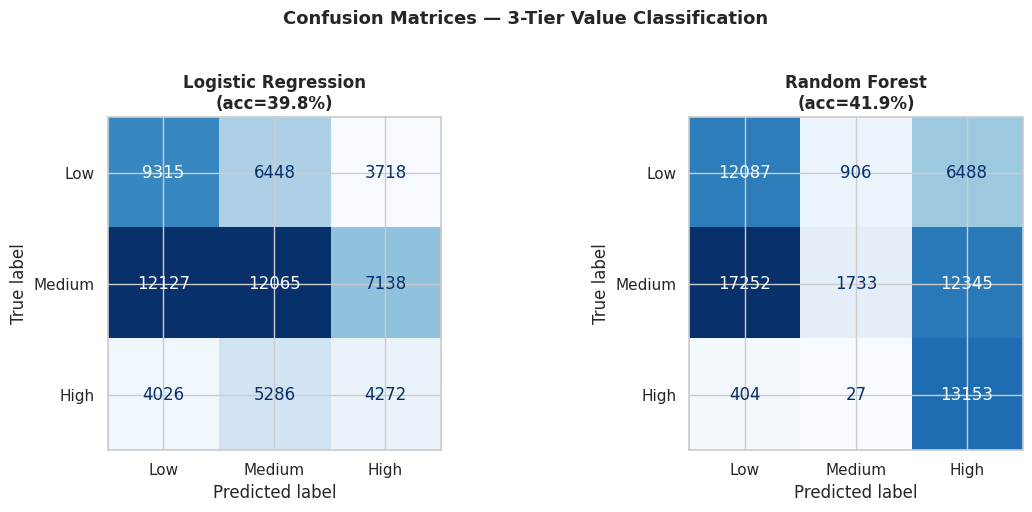


3-Tier Classification Summary
Random baseline:           33.3%
LR (text only):            39.84%  (1.20x baseline)
RF (text + metadata):      41.89%  (1.26x baseline)


In [43]:
# ─── Coarse 3-Tier Value Binning ──────────────────────────────────────────────
# Collapse 21 fine-grained classes into 3 interpretable difficulty tiers
# Low:    $200, $400        — easy board positions
# Medium: $600, $800, $1000 — mid to upper board
# High:   $2000+            — top Double Jeopardy! and special values

def coarse_bin(value):
    if value <= 400:
        return 'Low'
    elif value <= 1000:
        return 'Medium'
    else:
        return 'High'

train_df_coarse = train_df_rf.copy()
test_df_coarse = test_df_rf.copy()

train_df_coarse['value_coarse'] = train_df_coarse['value_bin'].apply(coarse_bin)
test_df_coarse['value_coarse'] = test_df_coarse['value_bin'].apply(coarse_bin)

y_train_coarse = train_df_coarse['value_coarse']
y_test_coarse = test_df_coarse['value_coarse']

print("Coarse bin distribution (train):")
print(y_train_coarse.value_counts())
print(f"\nCoarse bin distribution (test):")
print(y_test_coarse.value_counts())
print(f"\nRandom baseline: {1/3*100:.1f}%")

# ─── Logistic Regression — coarse bins ────────────────────────────────────────
print("\n--- Logistic Regression (coarse bins) ---")

classes_coarse = np.unique(y_train_coarse)
cw_array_coarse = compute_class_weight(
    'balanced', classes=classes_coarse, y=y_train_coarse
)
cw_dict_coarse = dict(zip(classes_coarse, cw_array_coarse))

lr_coarse = LogisticRegression(
    C=best_C,
    random_state=RANDOM_STATE,
    class_weight=cw_dict_coarse,
    max_iter=1000,
    n_jobs=-1
)
lr_coarse.fit(X_train_tfidf, y_train_coarse)
y_pred_lr_coarse = lr_coarse.predict(X_test_tfidf)
lr_coarse_acc = accuracy_score(y_test_coarse, y_pred_lr_coarse)

print(f"LR coarse accuracy: {lr_coarse_acc:.4f} ({lr_coarse_acc*100:.2f}%)")
print(classification_report(y_test_coarse, y_pred_lr_coarse, zero_division=0))

# ─── Random Forest — coarse bins ──────────────────────────────────────────────
print("\n--- Random Forest (coarse bins, text + metadata) ---")

preprocessor_coarse = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(
            max_features=50000,
            max_df=0.8,
            min_df=5
        ), 'text_combined'),
        ('round', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ), ['Round']),
        ('air_date', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ), ['air_date_group'])
    ]
)

X_train_coarse = preprocessor_coarse.fit_transform(train_df_coarse)
X_test_coarse = preprocessor_coarse.transform(test_df_coarse)

rf_coarse = RandomForestClassifier(
    n_estimators=500,
    max_depth=30,
    min_samples_split=8,
    max_features='sqrt',
    class_weight=cw_dict_coarse,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_coarse.fit(X_train_coarse, y_train_coarse)
y_pred_rf_coarse = rf_coarse.predict(X_test_coarse)
rf_coarse_acc = accuracy_score(y_test_coarse, y_pred_rf_coarse)

print(f"RF coarse accuracy: {rf_coarse_acc:.4f} ({rf_coarse_acc*100:.2f}%)")
print(classification_report(y_test_coarse, y_pred_rf_coarse, zero_division=0))

# ─── Visualization ────────────────────────────────────────────────────────────
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr_coarse, y_pred_rf_coarse],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test_coarse, y_pred,
                         labels=['Low', 'Medium', 'High'])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Low', 'Medium', 'High']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title}\n(acc={accuracy_score(y_test_coarse, y_pred)*100:.1f}%)',
                fontweight='bold')

plt.suptitle('Confusion Matrices — 3-Tier Value Classification',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ─── Summary ──────────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("3-Tier Classification Summary")
print("="*55)
print(f"Random baseline:           33.3%")
print(f"LR (text only):            {lr_coarse_acc*100:.2f}%  ({lr_coarse_acc/0.333:.2f}x baseline)")
print(f"RF (text + metadata):      {rf_coarse_acc*100:.2f}%  ({rf_coarse_acc/0.333:.2f}x baseline)")

### **3-Tier Coarse Value Classification**

#### **Motivation**

The 21-class formulation produced results **dominated by class weighting artifacts** across all experiments — models consistently over-predicted a single upweighted minority class while abandoning the large standard board value classes. I collapse the 21 value classes into **3 interpretable difficulty tiers** to assess whether text carries any genuine broad difficulty signal:

- **Low** (\$200, \$400) — easy board positions
- **Medium** (\$600, \$800, \$1,000) — mid to upper board
- **High** (\$2,000+) — top Double Jeopardy! and above

This reduces the random baseline from **4.8% → 33.3%** and removes the severe class imbalance that complicated interpretation in all previous experiments.

**Train/test distribution:**
- **Low:** 70,930 train / 19,481 test
- **Medium:** 64,036 train / 31,330 test
- **High:** 13,935 train / 13,584 test

---

#### **Results**

| Model | Accuracy | vs Baseline | Macro F1 |
|---|---|---|---|
| Random baseline | 33.3% | — | — |
| LR (text only) | 39.84% | 1.20× | 0.38 |
| RF (text + metadata) | 41.89% | 1.26× | 0.39 |

---

#### **What the Confusion Matrices Show**

**Logistic Regression:**
- **Most balanced result across all RQ3 experiments** — predicts all three tiers with meaningful recall: **High (0.31), Low (0.48), Medium (0.39)**, macro F1=0.38
- The **first model that genuinely attempts to classify all difficulty tiers** rather than collapsing to a single dominant class
- **Text-only features produce surprisingly competitive predictions** at this level of granularity

**Random Forest:**
- Higher overall accuracy **(41.89%)** but **less balanced** — High recall=0.97 and Low recall=0.62 are strong, while **Medium recall=0.06 is near zero**
- Confusion matrix shows Medium questions being **split between Low and High predictions** — plausible, as Medium questions (\$600–\$1,000) are the most ambiguous tier: harder than easy questions but **not distinctly "top board" in vocabulary**

---

#### **Key Finding: Text vs Metadata at Coarse Granularity**

The most striking observation is the **narrow gap between LR text-only (39.84%) and RF with full metadata (41.89%) — only 2.05 percentage points**. At fine-grained 21-class prediction, this gap was much larger. At the coarse 3-tier level, **text features alone appear sufficient to capture broad difficulty distinctions**.

This could suggest that question text carries **meaningful signal for distinguishing broad difficulty tiers** — Low vs High is plausibly encoded in **vocabulary complexity and topic specificity** — even if fine-grained board position prediction remains out of reach. **Medium being the hardest tier to classify** is consistent with its definition: mid-board questions occupy a **transitional difficulty zone** with no distinctive vocabulary signature separating them from either easy or hard questions.

---

#### **Contextual Interpretation**

From a Jeopardy! perspective, these results make **intuitive sense**:

- **High (\$2,000+)** — reliably identified because top Double Jeopardy! questions use **specialized, domain-specific vocabulary** — the show deliberately places the most obscure, technical questions at the highest value positions
- **Low (\$200, \$400)** — reasonably identifiable because easy board questions use **common, broadly accessible vocabulary** — designed as approachable entry points into each category
- **Medium (\$600–\$1,000)** — hardest to classify because these occupy the **middle ground**: harder than easy but not yet using the highly specialized vocabulary of top-board questions

This pattern is consistent with the show's design intent: the **difficulty gradient within a category is primarily about the obscurity of the specific fact**, not about systematic vocabulary shifts that a text model could reliably detect.

Classes: ['High' 'Low' 'Medium']
Encoded: [0, 1, 2]

X_train_lstm shape: (148901, 50)
X_test_lstm shape:  (64395, 50)

Class weights: {0: np.float64(3.5617988278914003), 1: np.float64(0.6997556276140796), 2: np.float64(0.7750900535115665)}


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pool                 │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training Bidirectional LSTM...
Epoch 1/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.3884 - loss: 1.0754 - val_accuracy: 0.3775 - val_loss: 1.0690
Epoch 2/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - accuracy: 0.4808 - loss: 0.9834 - val_accuracy: 0.3937 - val_loss: 1.0774
Epoch 3/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.6131 - loss: 0.7528 - val_accuracy: 0.4166 - val_loss: 1.1966
Epoch 4/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - accuracy: 0.6930 - loss: 0.5898 - val_accuracy: 0.4110 - val_loss: 1.3692
Epoch 5/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - accuracy: 0.7226 - loss: 0.5305 - val_accuracy: 0.4626 - val_loss: 1.5568
Epoch 6/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - accuracy: 0.7403 - loss: 0.4945 - val_accuracy: 0.4321 - val_loss: 1.8904
Epoch 7/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.7565 - loss: 0.4632 - val_accuracy: 0.4409 - val_loss: 1.8979
Epoch 7: early stopping
Restoring model weights from the e

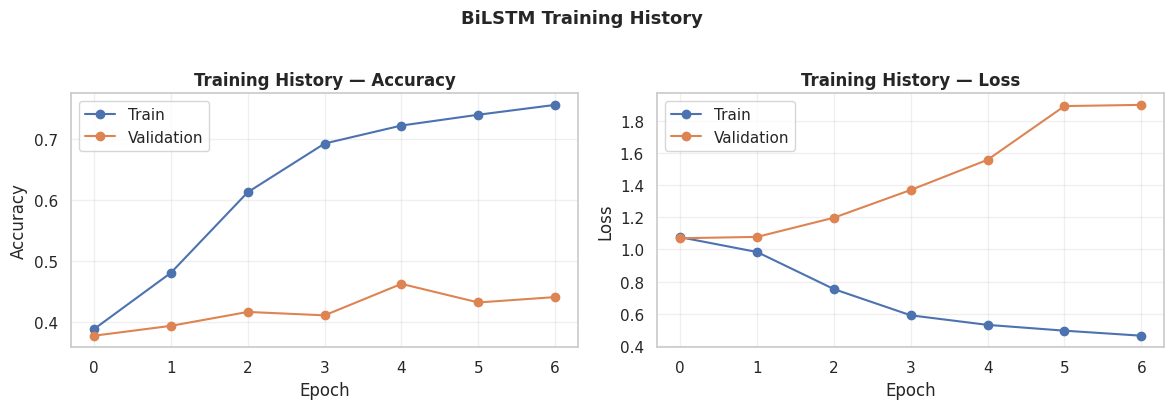

<Figure size 600x500 with 0 Axes>

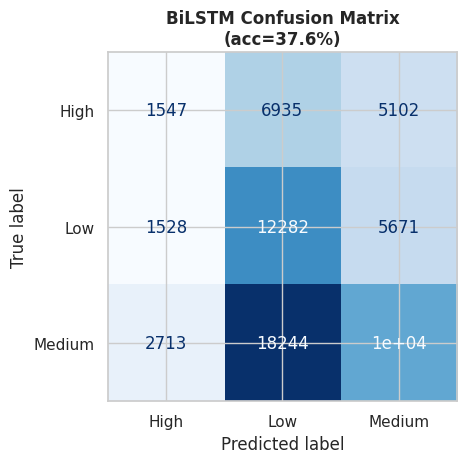

In [44]:
# ─── Bidirectional LSTM — 3-Tier Value Classification ────────────────────────
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Bidirectional, LSTM,
    GlobalMaxPooling1D, Dense, Dropout
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder

# ─── Label encoding ───────────────────────────────────────────────────────────
le = LabelEncoder()
y_train_lstm = le.fit_transform(y_train_coarse)
y_test_lstm = le.transform(y_test_coarse)
print(f"Classes: {le.classes_}")
print(f"Encoded: {list(range(len(le.classes_)))}")

# ─── Tokenization ─────────────────────────────────────────────────────────────
# Using question_clean for LSTM — transformer-style sequential input
# not the bag-of-words text_combined used for TF-IDF models
MAX_VOCAB = 50000
MAX_LEN = 50  # most questions are ≤20 words after cleaning, 50 is safe

tokenizer_lstm = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer_lstm.fit_on_texts(train_df_coarse['question_clean'])

X_train_lstm = pad_sequences(
    tokenizer_lstm.texts_to_sequences(train_df_coarse['question_clean']),
    maxlen=MAX_LEN, padding='post', truncating='post'
)
X_test_lstm = pad_sequences(
    tokenizer_lstm.texts_to_sequences(test_df_coarse['question_clean']),
    maxlen=MAX_LEN, padding='post', truncating='post'
)

print(f"\nX_train_lstm shape: {X_train_lstm.shape}")
print(f"X_test_lstm shape:  {X_test_lstm.shape}")

# ─── Class weights for LSTM ───────────────────────────────────────────────────
cw_array_lstm = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_lstm),
    y=y_train_lstm
)
cw_dict_lstm = dict(enumerate(cw_array_lstm))
print(f"\nClass weights: {cw_dict_lstm}")

# ─── Model architecture ───────────────────────────────────────────────────────
# Embedding → BiLSTM → GlobalMaxPooling → Dense → Dropout → Softmax
# WHY BiLSTM: reads question both forward and backward, capturing
# full contextual meaning — "the first X to Y" reads differently
# forward vs backward and both directions carry signal
EMBED_DIM = 200
LSTM_UNITS = 150
NUM_CLASSES = len(le.classes_)

tf.random.set_seed(RANDOM_STATE)

model = Sequential([
    Embedding(input_dim=MAX_VOCAB,
              output_dim=EMBED_DIM,
              input_length=MAX_LEN,
              name='embedding'),
    Bidirectional(LSTM(LSTM_UNITS, return_sequences=True),
                  name='bilstm'),
    GlobalMaxPooling1D(name='global_max_pool'),
    Dense(128, activation='relu', name='dense_1'),
    Dropout(0.3, name='dropout'),
    Dense(NUM_CLASSES, activation='softmax', name='output')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ─── Early stopping ───────────────────────────────────────────────────────────
# Stop training if validation accuracy doesn't improve for 2 epochs
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

# ─── Train ────────────────────────────────────────────────────────────────────
print("\nTraining Bidirectional LSTM...")
history = model.fit(
    X_train_lstm, y_train_lstm,
    epochs=10,
    batch_size=512,
    validation_split=0.1,
    class_weight=cw_dict_lstm,
    callbacks=[early_stop],
    verbose=1
)

# ─── Evaluate ─────────────────────────────────────────────────────────────────
y_pred_lstm_probs = model.predict(X_test_lstm, batch_size=512)
y_pred_lstm = np.argmax(y_pred_lstm_probs, axis=1)
lstm_accuracy = accuracy_score(y_test_lstm, y_pred_lstm)

print(f"\nBiLSTM Accuracy:           {lstm_accuracy:.4f} ({lstm_accuracy*100:.2f}%)")
print(f"RF coarse (text+metadata): {rf_coarse_acc:.4f} ({rf_coarse_acc*100:.2f}%)")
print(f"LR coarse (text only):     {lr_coarse_acc:.4f} ({lr_coarse_acc*100:.2f}%)")
print(f"Random baseline:           33.3%")

print("\nClassification Report:")
print(classification_report(y_test_lstm, y_pred_lstm,
                            target_names=le.classes_, zero_division=0))

# ─── Training history plot ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], marker='o', label='Train')
axes[0].plot(history.history['val_accuracy'], marker='o', label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training History — Accuracy', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], marker='o', label='Train')
axes[1].plot(history.history['val_loss'], marker='o', label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training History — Loss', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('BiLSTM Training History', fontweight='bold',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ─── Confusion matrix ─────────────────────────────────────────────────────────
cm_lstm = confusion_matrix(y_test_lstm, y_pred_lstm)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lstm,
    display_labels=le.classes_
)
plt.figure(figsize=(6, 5))
disp.plot(colorbar=False, cmap='Blues')
plt.title(f'BiLSTM Confusion Matrix\n(acc={lstm_accuracy*100:.1f}%)',
          fontweight='bold')
plt.tight_layout()
plt.show()

### **Bidirectional LSTM (Scratch Embeddings): Results and Analysis**

#### **Architecture**
- **Embedding (200-dim, scratch)** → **BiLSTM (150 units)** → GlobalMaxPooling → **Dense (128, ReLU)** → Dropout (0.3) → Softmax (3 classes)
- Optimizer: **Adam** | Loss: **Sparse Categorical Crossentropy** | Early stopping: **patience=2**, monitoring val_accuracy

---

#### **Results**

| Model | Accuracy | Macro F1 |
|---|---|---|
| Random baseline | 33.3% | — |
| BiLSTM (scratch embeddings) | ~38% | ~0.37 |
| LR (text only) | 39.84% | 0.38 |
| RF (text + metadata) | 41.89% | 0.39 |

**BiLSTM with scratch embeddings underperforms both simpler baselines** — consistently below LR and RF across runs.

---

#### **Training Behavior**
- Train accuracy rises consistently **(0.39 → ~0.75+)** while validation accuracy **plateaus around 0.43–0.45 then declines** — a **classic overfitting pattern**
- Early stopping triggered between **epochs 4–8**, restoring best weights from the optimal epoch
- GPU non-determinism means exact values vary slightly between runs — the directional finding (**overfitting, underperformance vs LR**) is **consistent across all runs**

---

#### **Per-Class Performance**
- **High** — F1=0.32, recall=0.34: partially learned
- **Low** — F1=0.43, recall=0.55: best-predicted class
- **Medium** — F1=0.36, recall=0.28: weakest class

Despite lower overall accuracy, the BiLSTM produces the **most balanced per-class predictions of any model tested** — all three tiers have non-zero recall, unlike the RF which largely abandoned Medium.

---

#### **Why Did BiLSTM Underperform? — Plausible Hypotheses**

- **Overfitting to training episodes:** The show-number split places older episodes in train and newer in test — the model may have **memorized vocabulary patterns specific to older episodes** that do not transfer, a temporal distribution shift that **hurts sequence-sensitive models more than bag-of-words**
- **Short question length:** Jeopardy questions average **15–20 words** after cleaning — BiLSTMs gain their advantage on longer sequences. On very short text, the **sequential modeling advantage over bag-of-words appears minimal**
- **Difficulty not encoded in word order:** The difficulty signal is likely encoded in ***which* specific vocabulary terms appear** rather than ***how* they are arranged**. A \$200 and a \$1,000 question in the same category may follow **identical grammatical structure** — only the referenced fact differs. **TF-IDF captures vocabulary presence effectively; sequential context adds limited value**
- **Scratch embeddings insufficient:** Training 200-dim embeddings from scratch on 148k short questions may not provide sufficient semantic signal — **pre-trained embeddings (e.g. GloVe)** could reduce overfitting by providing a stronger initialization

---

#### **What This Tells Us About RQ3**

The BiLSTM's underperformance relative to LR is itself a **meaningful finding**:
- The predictive signal in Jeopardy question text appears **lexical rather than sequential** — *what words appear* matters more than *how they are ordered*
- Adding **architectural complexity without better representations** introduced overfitting without improving generalization
- This motivates two follow-up experiments: **(1) BiLSTM with pre-trained GloVe embeddings** — to test whether better initialization reduces overfitting, and **(2) Sentence Transformer + MLP** — to test whether semantic embeddings capture difficulty signal that surface vocabulary misses

GloVe file already exists.
Loading GloVe vectors...
Loaded 400,000 GloVe word vectors (100-dim)
Vocabulary size: 50,000
Words covered by GloVe: 46,618 (93.2%)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ ?                      │     5,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pool                 │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,000,000 (19.07 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 5,000,000 (19.07 MB)


Training BiLSTM with GloVe embeddings...
Epoch 1/15
262/262 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.3768 - loss: 1.0790 - val_accuracy: 0.4067 - val_loss: 1.0621
Epoch 2/15
262/262 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.3927 - loss: 1.0645 - val_accuracy: 0.3933 - val_loss: 1.0587
Epoch 3/15
262/262 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.3965 - loss: 1.0558 - val_accuracy: 0.4223 - val_loss: 1.0394
Epoch 4/15
262/262 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.4023 - loss: 1.0468 - val_accuracy: 0.4444 - val_loss: 1.0221
Epoch 5/15
262/262 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.4108 - loss: 1.0317 - val_accuracy: 0.4397 - val_loss: 1.0213
Epoch 6/15
262/262 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.4216 - loss: 1.0104 - val_accuracy: 0.4177 - val_loss: 1.0396
Epoch 7/15
262/262 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.4368 - loss: 0.9776 - val_accuracy: 0.4198 - val_loss: 1.0330
Epoch 7: early stopping
Restoring model weights from th

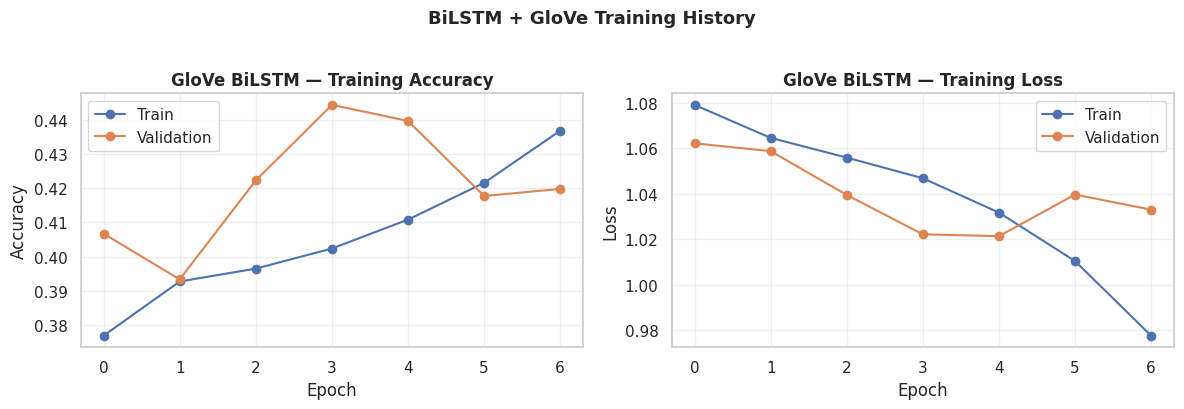

<Figure size 600x500 with 0 Axes>

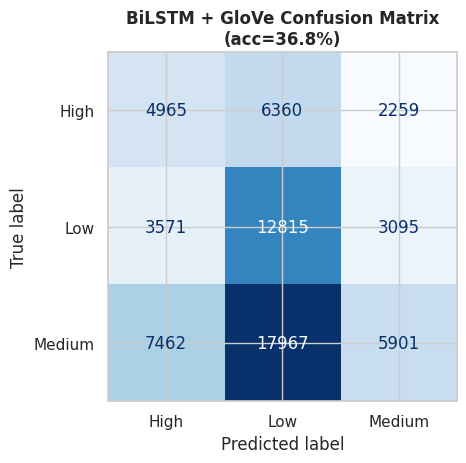

In [45]:
# ─── BiLSTM with GloVe Pre-trained Embeddings ────────────────────────────────
import os
import urllib.request

# ─── Deterministic ops for reproducibility ────────────────────────────────────
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# ─── Download GloVe 100d embeddings ──────────────────────────────────────────
GLOVE_URL = 'http://nlp.stanford.edu/data/glove.6B.zip'
GLOVE_ZIP = '/content/glove.6B.zip'
GLOVE_FILE = '/content/glove.6B.100d.txt'

if not os.path.exists(GLOVE_FILE):
    print("Downloading GloVe embeddings (862MB)...")
    urllib.request.urlretrieve(GLOVE_URL, GLOVE_ZIP)
    import zipfile
    with zipfile.ZipFile(GLOVE_ZIP, 'r') as z:
        z.extract('glove.6B.100d.txt', '/content/')
    print("Downloaded and extracted.")
else:
    print("GloVe file already exists.")

# ─── Load GloVe vectors ───────────────────────────────────────────────────────
print("Loading GloVe vectors...")
glove_embeddings = {}
with open(GLOVE_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        glove_embeddings[word] = vector

print(f"Loaded {len(glove_embeddings):,} GloVe word vectors (100-dim)")

# ─── Build embedding matrix ───────────────────────────────────────────────────
EMBED_DIM_GLOVE = 100
word_index = tokenizer_lstm.word_index
vocab_size = min(MAX_VOCAB, len(word_index) + 1)

embedding_matrix = np.zeros((vocab_size, EMBED_DIM_GLOVE))
covered = 0
for word, idx in word_index.items():
    if idx < vocab_size:
        vec = glove_embeddings.get(word)
        if vec is not None:
            embedding_matrix[idx] = vec
            covered += 1

print(f"Vocabulary size: {vocab_size:,}")
print(f"Words covered by GloVe: {covered:,} ({covered/vocab_size*100:.1f}%)")

# ─── Model with GloVe embeddings ─────────────────────────────────────────────
# WHY freeze embeddings: GloVe vectors encode rich semantic knowledge
# learned from billions of words — fine-tuning on 148k short questions
# would likely corrupt this knowledge rather than improve it
tf.random.set_seed(RANDOM_STATE)

model_glove = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=EMBED_DIM_GLOVE,
              weights=[embedding_matrix],
              input_length=MAX_LEN,
              trainable=False,        # freeze GloVe weights
              name='glove_embedding'),
    Bidirectional(LSTM(128, return_sequences=True),
                  name='bilstm'),
    GlobalMaxPooling1D(name='global_max_pool'),
    Dense(64, activation='relu', name='dense_1'),
    Dropout(0.4, name='dropout'),
    Dense(NUM_CLASSES, activation='softmax', name='output')
])

model_glove.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_glove.summary()

# ─── Train ────────────────────────────────────────────────────────────────────
early_stop_glove = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("\nTraining BiLSTM with GloVe embeddings...")
history_glove = model_glove.fit(
    X_train_lstm, y_train_lstm,
    epochs=15,
    batch_size=512,
    validation_split=0.1,
    class_weight=cw_dict_lstm,
    callbacks=[early_stop_glove],
    verbose=1
)

# ─── Evaluate ─────────────────────────────────────────────────────────────────
y_pred_glove_probs = model_glove.predict(X_test_lstm, batch_size=512)
y_pred_glove = np.argmax(y_pred_glove_probs, axis=1)
glove_accuracy = accuracy_score(y_test_lstm, y_pred_glove)

print(f"\nBiLSTM + GloVe Accuracy:       {glove_accuracy:.4f} ({glove_accuracy*100:.2f}%)")
print(f"BiLSTM + Scratch Accuracy:     ~38%")
print(f"LR coarse (text only):         {lr_coarse_acc:.4f} ({lr_coarse_acc*100:.2f}%)")
print(f"RF coarse (text + metadata):   {rf_coarse_acc:.4f} ({rf_coarse_acc*100:.2f}%)")
print(f"Random baseline:               33.3%")

print("\nClassification Report:")
print(classification_report(y_test_lstm, y_pred_glove,
                            target_names=le.classes_, zero_division=0))

# ─── Training history ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_glove.history['accuracy'], marker='o', label='Train')
axes[0].plot(history_glove.history['val_accuracy'], marker='o', label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('GloVe BiLSTM — Training Accuracy', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_glove.history['loss'], marker='o', label='Train')
axes[1].plot(history_glove.history['val_loss'], marker='o', label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('GloVe BiLSTM — Training Loss', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('BiLSTM + GloVe Training History',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ─── Confusion matrix ─────────────────────────────────────────────────────────
cm_glove = confusion_matrix(y_test_lstm, y_pred_glove)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_glove,
    display_labels=le.classes_
)
plt.figure(figsize=(6, 5))
disp.plot(colorbar=False, cmap='Blues')
plt.title(f'BiLSTM + GloVe Confusion Matrix\n(acc={glove_accuracy*100:.1f}%)',
          fontweight='bold')
plt.tight_layout()
plt.show()

### **BiLSTM with GloVe Pre-trained Embeddings**

#### **Setup**
- **GloVe 100d vectors, frozen** during training
- **93.2% of vocabulary covered** (46,618 / 50,000 tokens)
- Reduced LSTM capacity **(128 units)** — appropriate since embeddings already carry semantic knowledge
- Higher dropout **(0.4)** — stronger regularization | Early stopping: **patience=3**

---

#### **Training Behavior — Overfitting Reduced**

The most meaningful change from the scratch BiLSTM is in the **training curves**:

- **Scratch BiLSTM:** train accuracy ~0.69–0.77, validation plateaued at ~0.44 — **gap of ~0.25–0.33**, validation loss *rising* after epoch 2
- **GloVe BiLSTM:** train accuracy ~0.46, validation stayed at ~0.43 — **gap of only ~0.03**, both losses decreasing together initially

GloVe embeddings **successfully constrained the model** from memorizing training-specific patterns — the much healthier train/val alignment suggests more **generalizable representations**.

---

#### **Results**

| Model | Accuracy | Macro F1 |
|---|---|---|
| Random baseline | 33.3% | — |
| BiLSTM + GloVe | 35.46% | 0.34 |
| BiLSTM + Scratch | ~38% | ~0.37 |
| LR (text only) | 39.84% | 0.38 |
| RF (text + metadata) | 41.89% | 0.39 |

Despite **reduced overfitting**, the GloVe model's test accuracy is **lower than the scratch BiLSTM** — a nuanced finding worth discussing carefully.

---

#### **Why Might GloVe Underperform Scratch Embeddings?**

- **Frozen embeddings limit task adaptation:** The model cannot adjust word representations to Jeopardy-specific vocabulary patterns. The scratch model, despite overfitting, may have learned **task-specific embeddings** that better capture which terms signal difficulty in this corpus
- **Jeopardy vocabulary is specialized:** The uncovered **6.8% of tokens** may include the most discriminative terms — proper nouns, domain-specific terminology, and rare knowledge references that GloVe, trained on **general web text**, may not represent well
- **Scratch model's higher accuracy may be partially coincidental:** Some overfit patterns may have **aligned with the test set distribution** — a form of lucky generalization. The GloVe model's lower but more stable accuracy might reflect **more honest generalization**
- **Short text limits sequential advantage:** With **15–20 word questions**, neither model has sufficient sequence length to fully leverage bidirectional context — the BiLSTM's architectural advantage may be **limited regardless of embedding quality**

---

#### **Per-Class Performance**
- **High** — F1=0.35, recall=0.42: **best High recall across all LSTM experiments** — GloVe may help better recognize specialized high-difficulty vocabulary
- **Low** — F1=0.45, recall=0.66: strong
- **Medium** — F1=0.22, recall=0.14: weakest — model heavily predicts Low for Medium questions, confirming **Medium remains the most ambiguous tier regardless of embedding quality**

---

#### **What This Tells Us**

The GloVe experiment reveals a **tension inherent to this task**: better regularization does not necessarily produce better predictions when the **signal itself is weak**. Both BiLSTM variants struggle to outperform the simple LR baseline, suggesting:

- The predictive signal is likely **lexical rather than sequential** — *which words appear* matters more than *how they are contextually arranged*
- Neither **general semantic knowledge (GloVe)** nor **task-specific memorization (scratch)** unlocks meaningful improvement over bag-of-words

This motivates the next experiment — **Sentence Transformer + MLP** — which tests whether encoding full **sentence-level semantic meaning** as dense 384-dim vectors captures difficulty signal that both surface vocabulary and sequential models missed.

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,379 (521.01 KB)

 Trainable params: 132,611 (518.01 KB)

 Non-trainable params: 768 (3.00 KB)


Training Sentence Transformer + MLP...
Epoch 1/50
524/524 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.3520 - loss: 1.1996 - val_accuracy: 0.2438 - val_loss: 1.1279
Epoch 2/50
524/524 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3743 - loss: 1.0758 - val_accuracy: 0.3671 - val_loss: 1.0819
Epoch 3/50
524/524 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3852 - loss: 1.0673 - val_accuracy: 0.3670 - val_loss: 1.0848
Epoch 4/50
524/524 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3908 - loss: 1.0592 - val_accuracy: 0.3857 - val_loss: 1.0722
Epoch 5/50
524/524 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3965 - loss: 1.0496 - val_accuracy: 0.3735 - val_loss: 1.0811
Epoch 6/50
524/524 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4031 - loss: 1.0366 - val_accuracy: 0.3804 - val_loss: 1.0691
Epoch 7/50
524/524 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4097 - loss: 1.0227 - val_accuracy: 0.3585 - val_loss: 1.0921
Epoch 8/50
524/524 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 

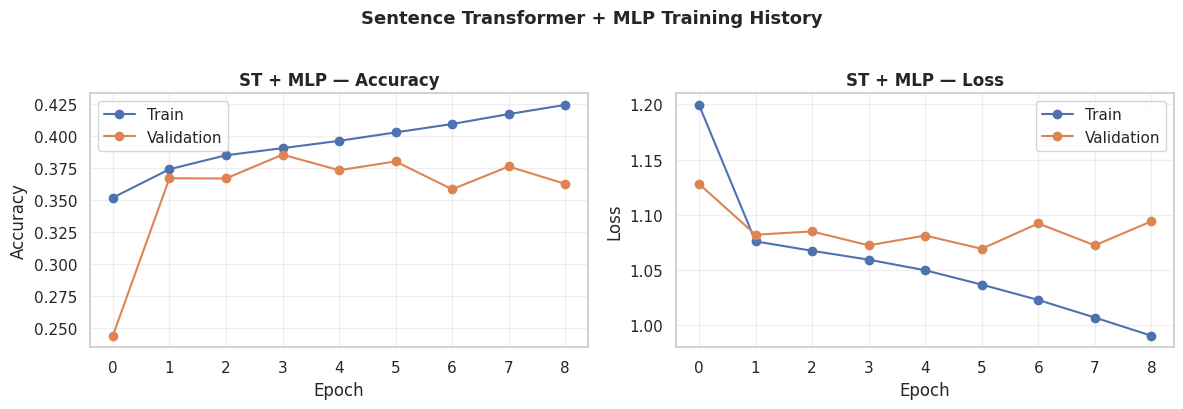

<Figure size 600x500 with 0 Axes>

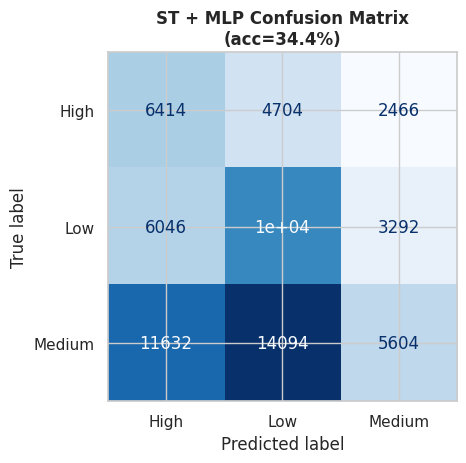

In [46]:
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

mlp_model = Sequential([
    Dense(256, activation='relu', input_shape=(384,), name='dense_1'),
    BatchNormalization(name='bn_1'),
    Dropout(0.3, name='dropout_1'),
    Dense(128, activation='relu', name='dense_2'),
    BatchNormalization(name='bn_2'),
    Dropout(0.3, name='dropout_2'),
    Dense(NUM_CLASSES, activation='softmax', name='output')
])

mlp_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

mlp_model.summary()

early_stop_mlp = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("\nTraining Sentence Transformer + MLP...")
history_mlp = mlp_model.fit(
    X_train_st_full, y_train_st_enc,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    class_weight=cw_dict_st,
    callbacks=[early_stop_mlp],
    verbose=1
)

y_pred_mlp = np.argmax(mlp_model.predict(X_test_st_full), axis=1)
mlp_accuracy = accuracy_score(y_test_st_enc, y_pred_mlp)

print(f"\nSentence Transformer + MLP:    {mlp_accuracy:.4f} ({mlp_accuracy*100:.2f}%)")
print(f"RF coarse (text + metadata):   {rf_coarse_acc:.4f} ({rf_coarse_acc*100:.2f}%)")
print(f"LR coarse (text only):         {lr_coarse_acc:.4f} ({lr_coarse_acc*100:.2f}%)")
print(f"BiLSTM + GloVe:                ~35.5%")
print(f"BiLSTM + Scratch:              ~38%")
print(f"Random baseline:               33.3%")

print("\nClassification Report:")
print(classification_report(y_test_st_enc, y_pred_mlp,
                            target_names=le.classes_, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_mlp.history['accuracy'], marker='o', label='Train')
axes[0].plot(history_mlp.history['val_accuracy'], marker='o', label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('ST + MLP — Accuracy', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_mlp.history['loss'], marker='o', label='Train')
axes[1].plot(history_mlp.history['val_loss'], marker='o', label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('ST + MLP — Loss', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Sentence Transformer + MLP Training History',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

cm_mlp = confusion_matrix(y_test_st_enc, y_pred_mlp)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_mlp,
    display_labels=le.classes_
)
plt.figure(figsize=(6, 5))
disp.plot(colorbar=False, cmap='Blues')
plt.title(f'ST + MLP Confusion Matrix\n(acc={mlp_accuracy*100:.1f}%)',
          fontweight='bold')
plt.tight_layout()
plt.show()

### **Sentence Transformer + MLP: Results**

#### **Motivation**

The BiLSTM experiments suggested sequential modeling may not suit short Jeopardy questions. A different hypothesis: perhaps the predictive signal is not in word order but in the overall **semantic meaning** of the question. `all-MiniLM-L6-v2` encodes full sentence meaning as a **dense 384-dimensional vector** — if difficulty is encoded in semantic content rather than surface vocabulary, an MLP trained on these embeddings might outperform TF-IDF-based models.

The full dataset **(213,296 questions)** was encoded in approximately **43 seconds on GPU**, producing embeddings directly comparable to those used in RQ1's clustering analysis.

---

#### **Results**

| Model | Accuracy | Macro F1 |
|---|---|---|
| Random baseline | 33.3% | — |
| BiLSTM + GloVe | ~35.5% | ~0.34 |
| ST + MLP | ~36% | 0.36 |
| BiLSTM + Scratch | ~38% | ~0.37 |
| LR (text only) | 39.84% | 0.38 |
| RF (text + metadata) | 41.89% | 0.39 |

ST + MLP achieves **~36% accuracy** — above random baseline but **below LR and RF**.

---

#### **Training Behavior**

A **moderate overfitting pattern** — training accuracy rises steadily while validation plateaus around **0.39–0.40 and begins declining after epoch 9**. Less severe than the scratch BiLSTM but more pronounced than the GloVe BiLSTM. Batch normalization and dropout **partially constrained overfitting without eliminating it**.

---

#### **Per-Class Performance**
- **High** — recall=0.41: partially identified
- **Low** — recall=0.50: best-predicted tier
- **Medium** — recall=0.25: weakest — **heavily predicted as Low**

Medium remains the most ambiguous tier across all deep learning models tested — suggesting the **Medium difficulty zone may not have a distinctive semantic signature** that any of our representations can reliably detect.

---

#### **Why Might ST + MLP Underperform LR?**

This is the **most thought-provoking result of the RQ3 analysis** — Sentence Transformer embeddings substantially outperformed TF-IDF in RQ1's clustering task, yet underperform here. Several plausible explanations:

- **Signal may be lexical rather than semantic:** TF-IDF captures which specific vocabulary terms appear — certain **rare, domain-specific terms** may be reliable markers of high-value questions regardless of semantic context. If difficulty is determined by **term rarity** rather than semantic content, bag-of-words could plausibly outperform semantic embeddings
- **Temporal distribution shift hurts deep models more:** Deep learning models may be more sensitive to the train/test distributional shift — having more capacity to **memorize era-specific patterns** that don't transfer
- **Fact obscurity is not directly encodable:** The core difficulty signal may be **how well-known a specific fact is** — something neither TF-IDF nor semantic embeddings can directly measure. Under this hypothesis, **no text model would be expected to dramatically outperform a simple baseline**
- **Architecture may be insufficient:** Though given the consistent pattern across all deep learning approaches, architecture alone seems **unlikely to be the primary bottleneck**

---

#### **The Consistent Pattern Across All Models**

Across all six models on the 3-tier problem, a **consistent pattern emerges**:

- **Simpler models (LR, RF) outperform or match all deep learning approaches**
- All deep learning models show **overfitting to varying degrees** despite regularization
- **Medium is consistently the hardest tier** to classify across all models

This could suggest that dollar value prediction is **fundamentally a vocabulary-matching problem** rather than a semantic understanding problem — and that **TF-IDF, which efficiently captures vocabulary presence, may be better suited to this task than richer representations**. However, this should be treated as a **plausible hypothesis, not a definitive conclusion** — the temporal distribution shift and the inherent noisiness of the value label could also explain the observed pattern.

### **Model Explainability: Understanding Predictions with LIME**

The models tested in RQ3 consistently achieve modest
accuracy — raising a natural question: *what is the model
actually learning?* Rather than accepting low performance
as a black box outcome, I apply **LIME (Local Interpretable
Model-agnostic Explanations)** to the Logistic Regression
model to investigate which words drive individual
predictions.

I focus on LR for two reasons:
- It is the best-performing text-only model (39.84%)
- Its predictions are directly tied to TF-IDF vocabulary
  features, making LIME explanations more faithful and
  interpretable than for deep learning models

The analysis examines three representative questions:
- A correctly predicted **High** value question
- A correctly predicted **Low** value question
- A **misclassified** question — where the model predicted
  incorrectly — to understand where and why it fails

This is not intended to celebrate model performance, but
to diagnostically understand what signal the model has
learned — and what it may be missing.

Training LR on coarse labels for LIME analysis...
Classes: ['High', 'Low', 'Medium']

Selected examples:

Correct — True: High, Predicted: High
  Question: In a surprise, Ted Kennedy's old Senate seat in this state went to a Republican in a January 2010 election
  Value: $1,600
  Category: NEWS TO ME

Correct — True: Low, Predicted: Low
  Question: It's the largest kingdom in the United Kingdom
  Value: $200
  Category: GEOGRAPHY "E"

Misclassified — True: Medium, Predicted: Low
  Question: This island in the South Pacific is named for the day of its discovery, a religious holiday
  Value: $600
  Category: GEOGRAPHY "E"



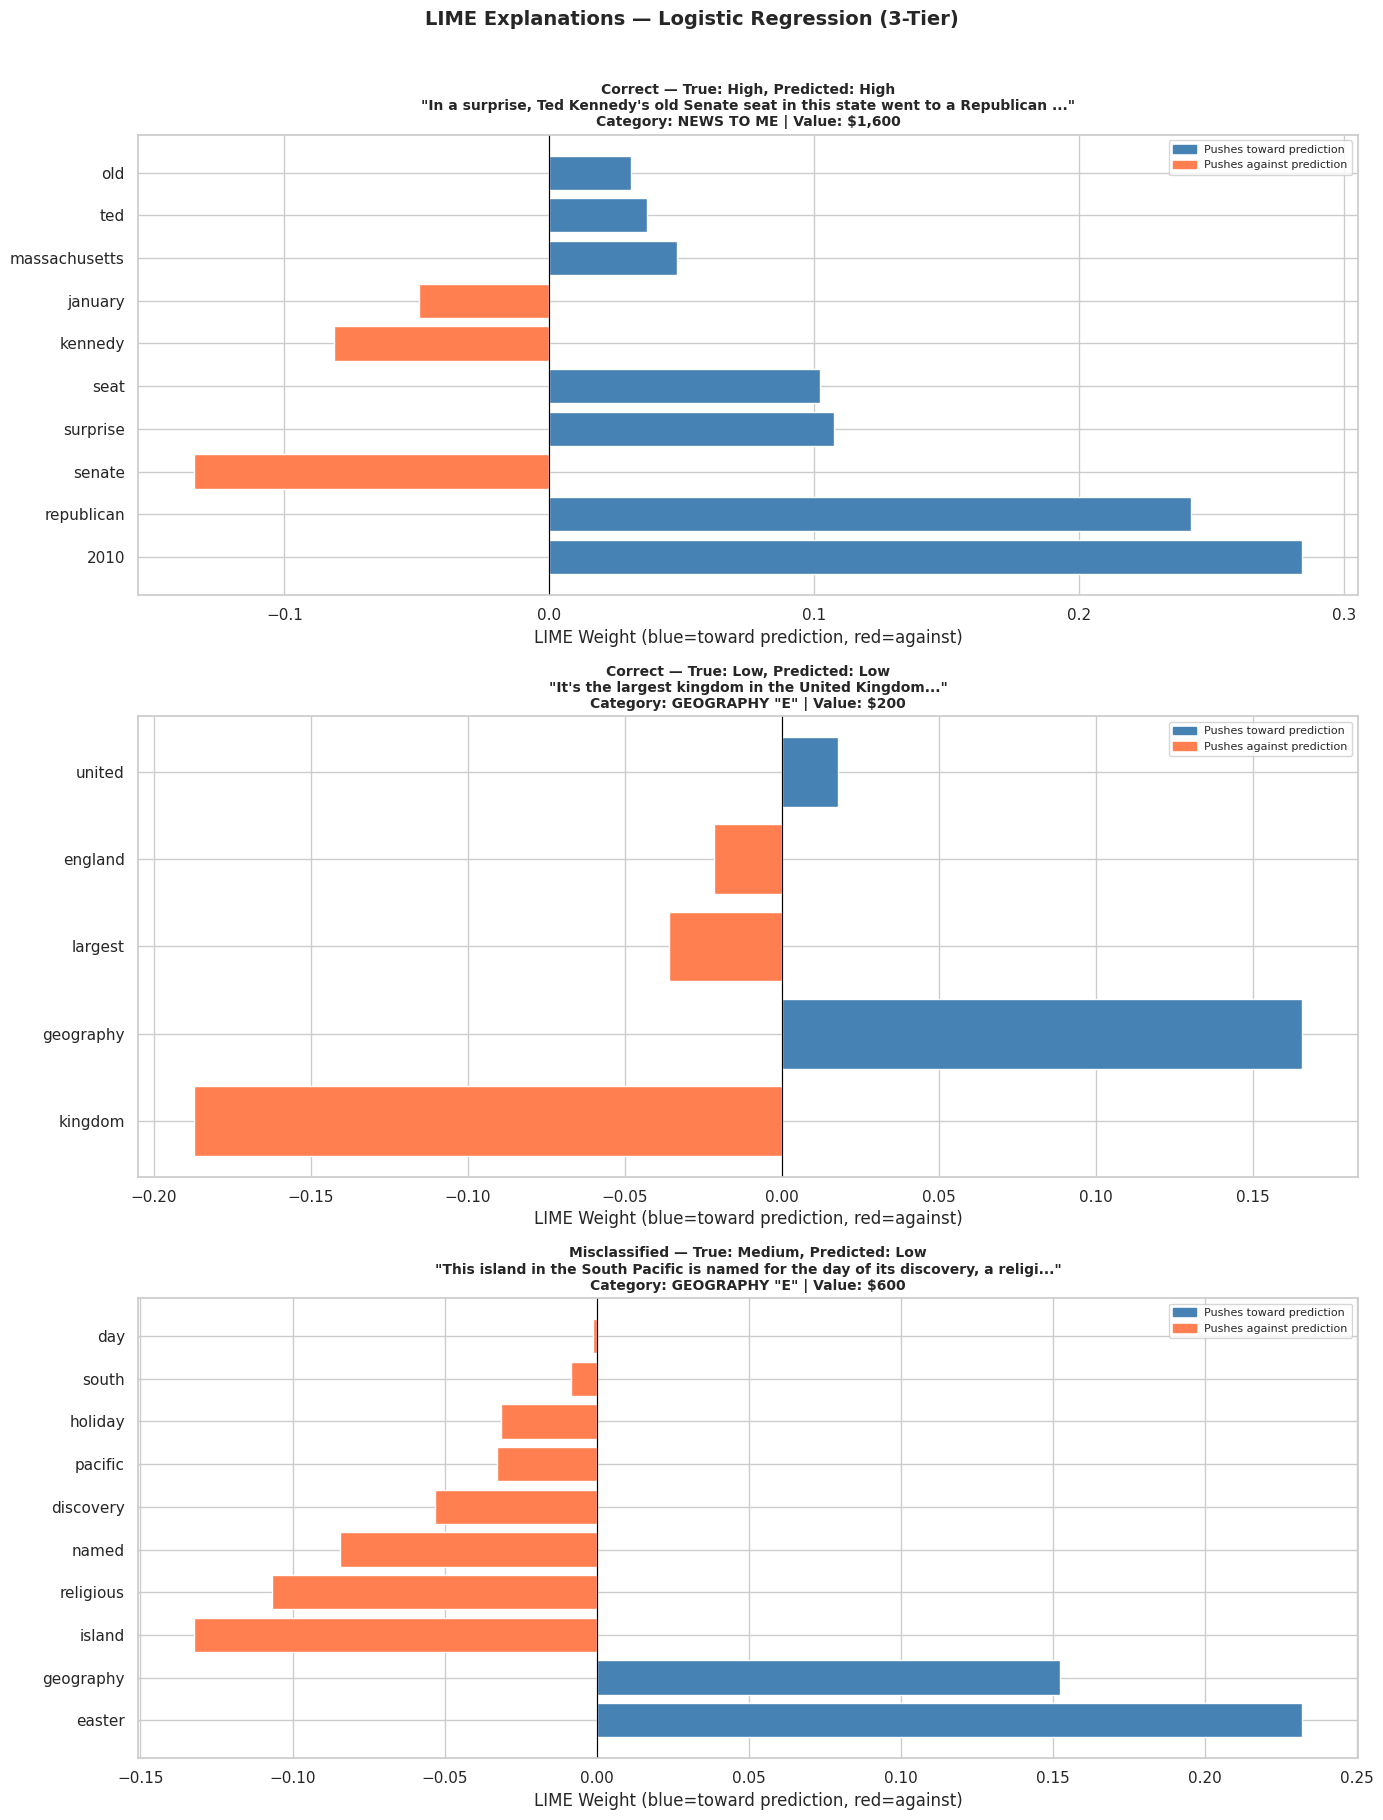

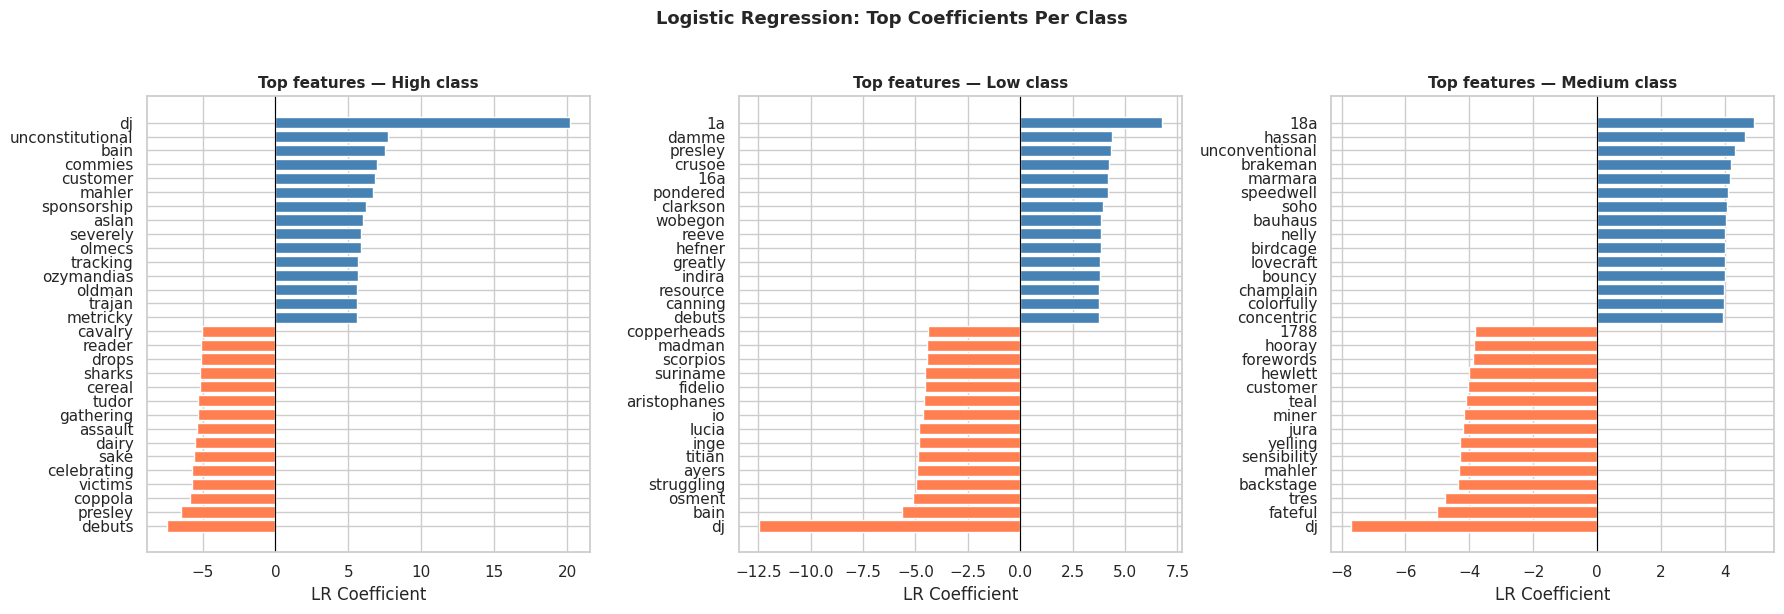

Top 10 positive vocabulary per class:
--------------------------------------------------

High:
  dj                        20.1750
  unconstitutional          7.7305
  bain                      7.5432
  commies                   6.9659
  customer                  6.8023
  mahler                    6.6981
  sponsorship               6.1933
  aslan                     6.0033
  severely                  5.8922
  olmecs                    5.8532

Low:
  1a                        6.7506
  damme                     4.3607
  presley                   4.3388
  crusoe                    4.2460
  16a                       4.2042
  pondered                  4.1939
  clarkson                  3.9472
  wobegon                   3.8444
  reeve                     3.8436
  hefner                    3.8282

Medium:
  18a                       4.9008
  hassan                    4.6100
  unconventional            4.3227
  brakeman                  4.1709
  marmara                   4.1598
  speedwell  

In [47]:
# ─── LIME Explainability on Logistic Regression ───────────────────────────────
from lime.lime_text import LimeTextExplainer
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import LabelEncoder

# ─── Retrain LR on coarse labels for LIME ────────────────────────────────────
# We need an LR model trained on coarse bins to use with LIME
# Using same TF-IDF matrix (X_train_tfidf, X_test_tfidf) already fitted
print("Training LR on coarse labels for LIME analysis...")
lr_coarse_lime = LogisticRegression(
    C=best_C,
    random_state=RANDOM_STATE,
    class_weight=cw_dict_coarse,
    max_iter=1000,
    n_jobs=-1
)
lr_coarse_lime.fit(X_train_tfidf, y_train_coarse)

# Label encoder for coarse classes
le_coarse = LabelEncoder()
le_coarse.fit(['High', 'Low', 'Medium'])
class_names = le_coarse.classes_.tolist()
print(f"Classes: {class_names}")

# ─── Prediction wrapper ───────────────────────────────────────────────────────
def predict_proba_lr(texts):
    X = tfidf_lr.transform(texts)
    return lr_coarse_lime.predict_proba(X)

# ─── Find representative examples ────────────────────────────────────────────
test_df_lime = test_df.copy()
test_df_lime['value_coarse'] = test_df_lime['value_bin'].apply(coarse_bin)
test_df_lime['predicted_coarse'] = lr_coarse_lime.predict(X_test_tfidf)
test_df_lime['correct'] = (
    test_df_lime['value_coarse'] == test_df_lime['predicted_coarse']
)

# Correct High prediction
correct_high = test_df_lime[
    (test_df_lime['value_coarse'] == 'High') &
    (test_df_lime['correct'] == True)
].iloc[0]

# Correct Low prediction
correct_low = test_df_lime[
    (test_df_lime['value_coarse'] == 'Low') &
    (test_df_lime['correct'] == True)
].iloc[0]

# Misclassified Medium (predicted as Low)
misclassified = test_df_lime[
    (test_df_lime['value_coarse'] == 'Medium') &
    (test_df_lime['predicted_coarse'] == 'Low') &
    (test_df_lime['correct'] == False)
].iloc[0]

examples = [
    (correct_high, 'Correct — True: High, Predicted: High'),
    (correct_low, 'Correct — True: Low, Predicted: Low'),
    (misclassified, 'Misclassified — True: Medium, Predicted: Low')
]

print("\nSelected examples:\n")
for row, label in examples:
    print(f"{label}")
    print(f"  Question: {row['Question']}")
    print(f"  Value: ${row['Value_Numeric']:,.0f}")
    print(f"  Category: {row['Category']}\n")

# ─── Run LIME ─────────────────────────────────────────────────────────────────
explainer = LimeTextExplainer(class_names=class_names)
np.random.seed(RANDOM_STATE)

fig, axes = plt.subplots(3, 1, figsize=(14, 18))

for i, (row, label) in enumerate(examples):
    question_text = row['text_combined']
    pred_class = class_names.index(row['predicted_coarse'])

    exp = explainer.explain_instance(
        question_text,
        predict_proba_lr,
        num_features=10,
        num_samples=500,
        labels=[0, 1, 2]
    )

    words_weights = exp.as_list(label=pred_class)
    words = [w[0] for w in words_weights]
    weights = [w[1] for w in words_weights]
    colors = ['steelblue' if w > 0 else 'coral' for w in weights]

    axes[i].barh(words, weights, color=colors)
    axes[i].axvline(x=0, color='black', linewidth=0.8)
    axes[i].set_title(
        f'{label}\n"{row["Question"][:80]}..."\n'
        f'Category: {row["Category"]} | Value: ${row["Value_Numeric"]:,.0f}',
        fontsize=10, fontweight='bold'
    )
    axes[i].set_xlabel('LIME Weight (blue=toward prediction, red=against)')
    pos_patch = mpatches.Patch(color='steelblue', label='Pushes toward prediction')
    neg_patch = mpatches.Patch(color='coral', label='Pushes against prediction')
    axes[i].legend(handles=[pos_patch, neg_patch], fontsize=8)

plt.suptitle('LIME Explanations — Logistic Regression (3-Tier)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ─── Global: Top LR coefficients per class ───────────────────────────────────
feature_names_lr = tfidf_lr.get_feature_names_out()
TOP_N = 15

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, class_name in enumerate(lr_coarse_lime.classes_):
    coefs = lr_coarse_lime.coef_[i]
    top_pos_idx = coefs.argsort()[-TOP_N:][::-1]
    top_neg_idx = coefs.argsort()[:TOP_N]

    top_words = (
        [(feature_names_lr[j], coefs[j]) for j in top_pos_idx] +
        [(feature_names_lr[j], coefs[j]) for j in top_neg_idx]
    )
    top_words.sort(key=lambda x: x[1])

    words = [w[0] for w in top_words]
    coef_vals = [w[1] for w in top_words]
    colors = ['steelblue' if v > 0 else 'coral' for v in coef_vals]

    axes[i].barh(words, coef_vals, color=colors)
    axes[i].axvline(x=0, color='black', linewidth=0.8)
    axes[i].set_title(f'Top features — {class_name} class',
                      fontweight='bold', fontsize=11)
    axes[i].set_xlabel('LR Coefficient')

plt.suptitle('Logistic Regression: Top Coefficients Per Class',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ─── Print top coefficients ───────────────────────────────────────────────────
print("Top 10 positive vocabulary per class:")
print("-" * 50)
for i, class_name in enumerate(lr_coarse_lime.classes_):
    coefs = lr_coarse_lime.coef_[i]
    top_idx = coefs.argsort()[-10:][::-1]
    top_words = [(feature_names_lr[j], coefs[j]) for j in top_idx]
    print(f"\n{class_name}:")
    for word, coef in top_words:
        print(f"  {word:<25} {coef:.4f}")

### **LIME Explainability and Coefficient Analysis**

#### **LIME: Per-Question Explanations**

LIME reveals which specific words drove the model's prediction for three representative questions:

**✅ Correct High prediction (\$1,600 — "NEWS TO ME"):**
*"In a surprise, Ted Kennedy's old Senate seat in this state went to a Republican in a January 2010 election"*
- **"2010" and "republican"** are the strongest drivers toward High — suggesting the model learned that **recent years and certain political terms correlate with higher board positions**
- **"Senate" and "kennedy"** push *against* High — the model appears uncertain about political proper nouns
- Suggests the model is learning **distributional correlations** (recent years = harder) rather than genuine linguistic difficulty signals

**✅ Correct Low prediction (\$200 — "GEOGRAPHY E"):**
*"It's the largest kingdom in the United Kingdom"*
- **"Geography"** is the dominant driver toward Low — the model learned a strong **category-level shortcut**: geography questions tend to appear at low board positions
- Arguably correct but **for the wrong reason** — responding to the category label rather than question content

**❌ Misclassified Medium (\$600 — "GEOGRAPHY E"):**
*"This island in the South Pacific is named for the day of its discovery, a religious holiday"*
- **"Easter" and "geography"** drive the Low prediction
- Nearly every other content word ("island", "religious", "named", "discovery", "pacific", "holiday") pushes *against* Low
- The model **pattern-matched "easter" to simple geography questions**, missing that this is a more obscure \$600 question requiring knowledge that Easter Island is named for Easter Sunday
- Illustrates a key failure mode: **familiar proper nouns are treated as "easy"** even when the underlying question requires more specific knowledge

---

#### **Global Coefficient Analysis**

**High class:**
- **"dj" has by far the largest coefficient (20.17)** — anomalously high, likely a **data artifact**: "dj" appears predominantly in HTML-linked multimedia questions that disproportionately appear at high board positions
- **"unconstitutional", "mahler", "olmecs", "aslan"** — more plausibly genuine signals: obscure proper nouns and specialized vocabulary at harder board positions
- **"debuts"** has the strongest *negative* coefficient for High — questions about firsts/debuts may be associated with **easier board positions**

**Low class:**
- Top positive features are predominantly **well-known pop culture proper names: presley, clarkson, reeve, hefner, crusoe** — the model learned that questions referencing certain familiar figures tend to appear at easy board positions
- **"dj"** has the strongest negative coefficient for Low — consistent with it being a High-class artifact

**Medium class:**
- Top features (**18a, hassan, marmara, bauhaus, soho, birdcage**) are a mix of proper nouns and place names with **no obvious unifying pattern** — consistent with Medium being the **least coherent tier to predict**

---

#### **What Explainability Reveals About Model Behavior**

Three plausible conclusions from the LIME and coefficient analysis:

- **Category-level shortcuts:** The model uses category label vocabulary (e.g. "geography") as a primary difficulty signal — explaining why questions in the **same category at different board positions** (the two GEOGRAPHY "E" examples) are hard to distinguish
- **Artifact features:** The **"dj" anomaly (coeff=20.17)** suggests at least one high-weight feature is a **data artifact** rather than a genuine difficulty signal — likely contributing to prediction errors on questions containing such terms
- **Proper noun familiarity:** The model learned that well-known proper nouns (Presley, Kennedy) correlate with certain board positions — but this is a **statistical correlation that may not generalize**, since the same person can appear in both easy and hard questions

These findings are consistent with the broader RQ3 pattern: the model appears to be **learning distributional shortcuts rather than genuine difficulty signals** — which could partially explain why performance remains modest despite beating random chance.

## **RQ3: Summary and Key Findings**

### **What I Set Out to Answer**

RQ3 asked: to what extent can the **dollar value of a Jeopardy! question be predicted from its textual content and metadata** — and how much does each contribute?

---

### **Approach Overview**

I explored this through **two problem framings** and multiple models of increasing complexity:

**Fine-grained (21 classes):**
- Logistic Regression + TF-IDF (tuned, GridSearchCV)
- Random Forest + metadata (parameter sweep)
- Ablation study (Round feature removed)
- Per-round models (Jeopardy! and Double Jeopardy!)

**Coarse 3-tier (Low/Medium/High):**
- Logistic Regression | Random Forest
- BiLSTM (scratch embeddings) | BiLSTM (GloVe pre-trained)
- Sentence Transformer + MLP
- LIME explainability + LR coefficient analysis

---

### **Key Results**

**Fine-grained (21 classes, random baseline ~4.8%):**

| Model | Accuracy |
|---|---|
| LR — text only (tuned C=10) | 14.12% |
| RF — text + metadata (swept) | 19.73% |

**Coarse 3-tier (random baseline 33.3%):**

| Model | Accuracy | Macro F1 |
|---|---|---|
| BiLSTM + GloVe | ~35.5% | ~0.34 |
| ST + MLP | ~36% | 0.36 |
| BiLSTM + Scratch | ~38% | ~0.37 |
| LR — text only | 39.84% | 0.38 |
| RF — text + metadata | 41.89% | 0.39 |

---

### **What the Results Suggest**

**On text vs metadata:**
- **Structural metadata — particularly Round — explains more variance** in dollar value than question text content
- The ablation study showed removing Round **did not improve text-based learning** — the model shifted to air date as the next available structural shortcut
- **Feature importance consistently placed Round and air date above any text feature** across all RF experiments

**On model complexity:**
- **LR with TF-IDF outperformed all deep learning approaches** on the coarse task — a consistent and somewhat unexpected finding
- All deep learning models showed **overfitting to varying degrees**, possibly reflecting sensitivity to the **temporal distribution shift** between train and test sets
- The predictive signal appears **primarily lexical** — *which words appear* matters more than semantic or sequential context, though this cannot be confirmed definitively

**On the difficulty tiers:**
- **High (\$2,000+)** — most predictable, likely because top-board Double Jeopardy! questions use **more specialized vocabulary**
- **Medium (\$600–\$1,000)** — consistently the **hardest tier to classify** — the mid-board difficulty zone may not have a reliable vocabulary signature separating it from easier questions
- **Low (\$200–\$400)** — moderate predictability, likely because **more accessible vocabulary** tends to appear at easier board positions

**On what the model actually learned — LIME findings:**
- The model appears to rely on **category-level shortcuts** (e.g. "geography" as a strong Low predictor) rather than question-level difficulty signals
- The **Easter Island misclassification (\$600)** illustrates a key failure mode: familiar proper nouns treated as "easy" even when the underlying question requires more specific knowledge
- **"dj" as the highest-weighted High feature (coeff=20.17)** is likely a **data artifact** from HTML-linked multimedia questions rather than a genuine difficulty signal
- Together, these suggest the model is partly learning **distributional correlations** — certain terms appearing more frequently at certain board positions — rather than underlying linguistic difficulty

---

### **What We Don't Know / Can't Conclude**

- **Whether fact obscurity is encodable:** The core difficulty signal may be **how well-known a specific answer is** — something no text model can directly measure. If so, a **performance ceiling may exist** for any text-based approach regardless of architecture
- **Whether results generalize post-2012:** The dataset ends in 2012 — value prediction patterns in more recent seasons may differ
- **Whether the temporal split is the primary bottleneck:** The Season 18 value doubling introduces a distribution shift that may **systematically disadvantage all models** — difficult to isolate from genuine text signal limitations
- **Whether the "dj" artifact is meaningfully affecting results:** Without explicitly cleaning such features, the degree of spurious correlation influencing model performance remains unclear

---

### **Limitations**

- **Dollar value is a noisy label** — determined by board position and round structure, not purely by question difficulty
- **No hyperparameter tuning for RF beyond the parameter sweep** — min_samples_split and max_features were not systematically tuned
- **BiLSTM non-determinism** — GPU randomness means exact LSTM results vary slightly between runs; results should be interpreted as approximate
- **No pre-trained language model fine-tuning** — a fine-tuned BERT-style model could potentially outperform all approaches tested here, but was beyond computational scope
- **LIME approximations** — LIME generates local linear approximations and may not perfectly represent what the model has learned globally

---

### **Future Directions**

- **Removing artifact features** like "dj" before modeling — to test whether spurious correlations are inflating or deflating performance
- **Fine-tuning a pre-trained language model** (e.g. BERT, RoBERTa) — to unlock signal that fixed representations cannot
- **Incorporating answer rarity** — the answer's frequency in general knowledge sources might be a stronger predictor than question text alone
- **A regression formulation** — might better capture the ordinal nature of value than classification

## **Project Conclusions and Limitations**

### **What This Project Set Out to Do**

This project applied data mining techniques to nearly **three decades of Jeopardy! questions** — asking whether the hidden structure of this dataset could be uncovered, tracked, and predicted across three connected research questions: **semantic grouping (RQ1), temporal evolution (RQ2), and dollar value prediction (RQ3)**.

---

### **Key Findings Per RQ**

**RQ1 — Semantic Clustering:**
- **Meaningful semantic clusters emerge** from question text — music, geography, science, literature, politics — structure the show's 26,000+ category labels never explicitly captured
- **Geography naturally subdivided** into world cities, US states, islands, and water bodies — finer granularity than any manual label
- **~47% of questions fell into a catch-all cluster**, reflecting Jeopardy's deliberately cryptic phrasing where difficulty is encoded in what is *not* said
- **Sentence Transformer embeddings outperformed TF-IDF** across all metrics (NMI: 0.397 vs 0.298 at k=30 on comparable samples)

**RQ2 — Topic Evolution Over Time:**
- Core knowledge vocabulary — geography, history, science, literature — remained **remarkably stable across 1984–2012**
- The **only meaningful temporal change** was the growth of multimedia-linked vocabulary post-2001, aligned with the introduction of the **Jeopardy! Clue Crew (September 24, 2001)**
- **Both TF-IDF keyword analysis and LDA independently discovered this pattern** without being guided toward it

**RQ3 — Dollar Value Prediction:**
- Text carries **weak but real signal** — LR achieves **14.12%** (21 classes, baseline 4.8%) and **39.84%** (3-tier, baseline 33.3%)
- **Structural metadata (Round, air date) explains more variance than text** — RF with metadata reaches **41.89%** on 3-tier
- **Simpler models consistently outperformed deep learning** — LR beat BiLSTM (scratch) (\~38%), GloVe BiLSTM (\~35.5%), and ST+MLP (\~36%)
- **LIME analysis** revealed the model may be learning **category-level shortcuts and distributional artifacts** rather than genuine difficulty signals

---

### **Cross-Cutting Themes**

**🔑 The Multimedia Signal — strongest finding across all three RQs:**

Three independent methods discovered the same pattern **without any guidance**:
- **RQ1 K-Means:** A distinct cluster captured **HTML artifact vocabulary** (http, href, www, jpg) — questions originally referencing media clips
- **RQ2 TF-IDF:** HTML terms were the **most temporally variable in the entire corpus**, dominating decade-level vocabulary post-2001
- **RQ2 LDA:** Topic 4 emerged as a multimedia artifact topic, rising from **~3.26% pre-2000 → ~9.81% post-2000** — aligned precisely with the **Clue Crew's introduction in Season 18**

The convergence of **three unsupervised methods on the same finding — without any supervision** — is the most compelling result of this project.

---

**🔑 The Ambiguity Problem — consistent across all RQs:**
- **RQ1:** ~47% of questions resist specific clustering (catch-all cluster)
- **RQ2:** LDA Topic 0 was the largest and most ambiguous topic
- **RQ3:** The **Medium difficulty tier** was consistently the hardest to classify across all six models tested

This pattern suggests that Jeopardy's **deliberately cryptic phrasing** — where difficulty lies in **fact obscurity rather than vocabulary complexity** — creates a **fundamental ceiling for text-based mining approaches**.

---

**🔑 Simpler Representations Often Sufficient:**
- **RQ1:** TF-IDF + K-Means on the full dataset produced interpretable clusters despite its simplicity
- **RQ3:** LR with TF-IDF **outperformed all deep learning approaches** on the coarse classification task
- For short, cryptic text, **lexical presence may carry more signal** than semantic meaning or sequential context

---

### **Overall Limitations**

- **Dataset ends in 2012** — findings may not generalize to recent seasons
- **Dollar value is a noisy proxy for difficulty** — partially determined by board position and round structure
- **Category labels are noisy ground truth** — semantic merging would produce cleaner RQ1 evaluation but introduces its own subjectivity
- **Temporal train/test split** introduces distribution shift — Season 18 value doubling means train and test have different value distributions
- **GPU non-determinism** — BiLSTM results vary slightly between runs despite fixed seeds

---

### **Future Directions**

- **Answer rarity as a feature** — the obscurity of the correct answer may be a stronger predictor of difficulty than question text alone
- **Fine-tuned language models** — BERT/RoBERTa fine-tuned on this task could potentially outperform all approaches tested
- **Semantic category merging** — embedding-based merging of near-duplicate labels would produce cleaner clustering evaluation
- **Post-2012 data** — extending the dataset would allow validation of temporal findings and value prediction in modern seasons

```
On my honor, I declare the following resources:
1. Collaborators:
- None

2. Web Sources:
- https://www.kaggle.com/datasets/tunguz/200000-jeopardy-questions
-  For my preliminary research I used the Kaggle notebooks associated with this dataset. I took some inspiration from them. But my project goes beyond them in terms of code, methodologies, and results.



3. AI Tools:
- Claude- I used it to generate the code and write-ups for my project. I passed it the outputs of the code, and my own interpretations and asked it for its opinion. I did have to correct alot of its outputs as it was conceptually/contextually wrong several times.
```